## Initialization

#### Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from feature_tools import FeatureSelector
from datetime import datetime
import os

from scipy import stats


import warnings
warnings.filterwarnings('ignore')
from pandasql import sqldf

#### Define Functions

In [2]:
def calculate_sleep_duration(start_time_input, end_time_input):
    # Define missing value codes
    missing_codes = ['', '77777', '99999']
    
    # Convert inputs to strings for easier handling
    if isinstance(start_time_input, bytes):
        start_time = start_time_input.decode('utf-8')
    else:
        # Handle string representation of bytes
        start_time = start_time_input
        if start_time.startswith("b'") and start_time.endswith("'"):
            start_time = start_time[2:-1]
    
    if isinstance(end_time_input, bytes):
        end_time = end_time_input.decode('utf-8')
    else:
        end_time = end_time_input
        if end_time.startswith("b'") and end_time.endswith("'"):
            end_time = end_time[2:-1]
    
    # Check for missing values
    if start_time in missing_codes or end_time in missing_codes:
        return None
    
    try:
        # Parse the times
        start_dt = datetime.strptime(start_time, "%H:%M")
        end_dt = datetime.strptime(end_time, "%H:%M")
        
        # Calculate duration, handling overnight sleep
        if end_dt < start_dt:  # Sleep crosses midnight
            # Use a full day reference to calculate correctly
            next_day = datetime.strptime("23:59", "%H:%M").replace(hour=end_dt.hour, minute=end_dt.minute)
            duration = (next_day - start_dt).seconds/3600 + 1/60  # Add 1 minute to account for 23:59 to 00:00
        else:
            duration = (end_dt - start_dt).seconds/3600
            
        return duration
    except ValueError:
        # Return None for any parsing errors
        return None

In [3]:
def stacked_bar_chart_plot(df):
    """
    Create stacked bar plots showing the relationship between categorical variables and sleep deprivation.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing categorical variables and 'is_sleep_deprived' column
    """
    # Identify categorical columns (exclude 'is_sleep_deprived')
    categorical_cols = [col for col in df.columns if col != 'is_sleep_deprived']
    
    # Create subplots for each categorical variable
    fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, 5*len(categorical_cols)))
    
    # Handle case with only one categorical column
    if len(categorical_cols) == 1:
        axes = [axes]
    
    # Plot each categorical variable
    for i, cat_col in enumerate(categorical_cols):
        cross_tab = pd.crosstab(
            df[cat_col], 
            df['is_sleep_deprived'],
            normalize='index'
        ) * 100
        
        # Get counts
        count_tab = pd.crosstab(
            df[cat_col], 
            df['is_sleep_deprived']
        )
        count_tab['total'] = count_tab.sum(axis=1)
        
        cross_tab.plot(
            kind='bar', 
            stacked=True,
            ax=axes[i],
            color=['#f08080', '#5bc0de']
        )
        
        # Increase y-limit to make more room
        axes[i].set_ylim(0, 120)
        
        # Better positioned labels with background box
        for j, category in enumerate(count_tab.index):
            total = count_tab.loc[category, 'total']
            axes[i].text(j, 110, f'n={total}', 
                        ha='center', 
                        va='bottom',
                        fontsize=9, 
                        fontweight='bold',
                        bbox=dict(facecolor='white', alpha=0.7, pad=2))
        
        axes[i].set_title(f'{cat_col} vs. Sleep Deprivation')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel('Percentage (%)')
        axes[i].legend(title='Sleep Deprived', labels=['Not Sleep Deprived (0)', 'Sleep Deprived (1)'])
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [4]:
def filter_by_missing(dataframe, threshold=0.3):
    """
    Filter a dataframe to keep only columns with missing values percentage below the threshold.
    
    Parameters:
    -----------
    dataframe : pandas.DataFrame
        The input dataframe to filter
    threshold : float, default=0.3
        The maximum acceptable percentage of missing values (0.0 to 1.0)
        
    Returns:
    --------
    pandas.DataFrame
        Filtered dataframe with only columns that have missing values below the threshold
    """
    # Calculate percentage of missing values for each column
    missing_percentage = dataframe.isna().mean()
    keep_columns = missing_percentage[missing_percentage < threshold].index
    return dataframe[keep_columns]

In [5]:
def find_significant_variables(df, target='is_sleep_deprived', alpha=0.05):
    # Define column widths
    var_width = 40
    pval_width = 15
    sig_width = 15
    
    # Print header with fixed widths
    print(f"{'Variable':{var_width}} {'p-value':{pval_width}} {'Significant':{sig_width}}")
    print("-" * (var_width + pval_width + sig_width))
    
    for column in df.columns:
        if column == target or not pd.api.types.is_numeric_dtype(df[column]):
            continue
        
        try:
            # Use Mann-Whitney U test instead (non-parametric)
            group1 = df[df[target] == 1][column].dropna()
            group0 = df[df[target] == 0][column].dropna()
            
            if len(group1) > 0 and len(group0) > 0:
                # Use Mann-Whitney which is more robust for non-normal data
                stat, p_value = stats.mannwhitneyu(group1, group0)
                
                # Format output
                p_val_str = f"{p_value:.5f}" if p_value >= 0.0001 else f"{p_value:.2e}"
                significant = "Yes" if p_value < alpha else "No"
                
                print(f"{column:{var_width}} {p_val_str:{pval_width}} {significant:{sig_width}}")
        except Exception as e:
            print(f"{column:{var_width}} {'Error':{pval_width}} {str(e)[:30]:{sig_width}}")
            continue


def find_significant_categorical_variables(df, target='is_sleep_deprived', alpha=0.05):
    # Define column widths
    var_width = 40
    pval_width = 15
    sig_width = 15
    
    # Print header with fixed widths
    print(f"{'Variable':{var_width}} {'p-value':{pval_width}} {'Significant':{sig_width}}")
    print("-" * (var_width + pval_width + sig_width))
    
    for column in df.columns:
        if column == target or pd.api.types.is_numeric_dtype(df[column]):
            continue
        
        try:
            # Create contingency table
            contingency_table = pd.crosstab(df[target], df[column])
            
            # Use Chi-square test
            chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table, correction=True)
            
            # Format output
            p_val_str = f"{p_value:.5f}" if p_value >= 0.0001 else f"{p_value:.2e}"
            significant = "Yes" if p_value < alpha else "No"
            
            print(f"{column:{var_width}} {p_val_str:{pval_width}} {significant:{sig_width}}")
            
        except Exception as e:
            print(f"{column:{var_width}} {'Error':{pval_width}} {str(e)[:30]:{sig_width}}")
            continue


In [6]:
def plot_sleep_deprivation_by_category(df, category_col):
    # Create a crosstab for percentages
    cross_tab = pd.crosstab(
        df[category_col], 
        df['is_sleep_deprived'],
        normalize='index'
    ) * 100
    
    # Create a crosstab for counts
    count_tab = pd.crosstab(
        df[category_col], 
        df['is_sleep_deprived']
    )
    
    # Add total counts as a column
    count_tab['total'] = count_tab.sum(axis=1)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    cross_tab.plot(
        kind='bar', 
        stacked=True,
        figsize=(10, 6),
        color=['#f08080', '#5bc0de'],
        ax=ax
    )
    
    plt.title(f'{category_col} vs. Sleep Deprivation')
    plt.xlabel(category_col)
    plt.ylabel('Percentage (%)')
    plt.legend(title='Sleep Deprived', labels=['Not Sleep Deprived (0)', 'Sleep Deprived (1)'])
    plt.ylim(0, 110)  # Increase y-limit to make room for annotations
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add count annotations above each bar
    for i, category in enumerate(count_tab.index):
        total = count_tab.loc[category, 'total']
        ax.text(i, 105, f'n={total}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    
    return fig

In [7]:
def create_boxplot(df, numeric_column, dataset_cat="Boxplot Analysis"):
    """
    Create a boxplot to visualize the relationship between a numerical variable
    and sleep deprivation status, with statistical summary, Mann-Whitney U test results,
    and biserial correlation in title.
    """
    # Filter out rows with NaN in numeric column
    plot_data = df.dropna(subset=[numeric_column])
    
    # Calculate Q1, Q3 and IQR
    Q1 = plot_data[numeric_column].quantile(0.25)
    Q3 = plot_data[numeric_column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds for visualization
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    
    # Filter out extreme outliers for visualization
    filtered_data = plot_data[(plot_data[numeric_column] >= lower_bound) & 
                             (plot_data[numeric_column] <= upper_bound)]
    
    # Perform Mann-Whitney U test for title
    groups = plot_data.groupby('is_sleep_deprived')[numeric_column]
    stat, p_val = stats.mannwhitneyu(
        groups.get_group(0).dropna(), 
        groups.get_group(1).dropna()
    )
    
    # Calculate point-biserial correlation
    corr_coef, corr_p_val = stats.pointbiserialr(
        plot_data['is_sleep_deprived'],
        plot_data[numeric_column]
    )
    
    # Create figure
    plt.figure(figsize=(10, 6))
    
    # Create boxplot with filtered data
    sns.boxplot(
        x='is_sleep_deprived',
        y=numeric_column,
        data=filtered_data,
        palette="pastel"
    )
    
    # Set labels
    plt.xlabel('Sleep Deprived')
    plt.ylabel(numeric_column)
    
    # Create title with Mann-Whitney U test results and biserial correlation
    significance = "Significant" if p_val < 0.05 else "Not Significant"
    plt.title(f"{dataset_cat}\nMann-Whitney: p={p_val:.4f} ({significance})\nBiserial: r={corr_coef:.4f}, p={corr_p_val:.4f}")
    
    plt.xticks([0, 1], ['No', 'Yes'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Print statistical summary
    print("\nStatistical Summary:")
    print(f"Variable: {numeric_column}")
    print("-" * 60)
    
    # Calculate statistics for each group
    stats_df = pd.DataFrame({
        'Sleep Deprived': ['No', 'Yes'],
        'Count': [groups.get_group(0).count(), groups.get_group(1).count()],
        'Mean': [groups.get_group(0).mean(), groups.get_group(1).mean()],
        'Median': [groups.get_group(0).median(), groups.get_group(1).median()],
        'Std Dev': [groups.get_group(0).std(), groups.get_group(1).std()],
        'Min': [groups.get_group(0).min(), groups.get_group(1).min()],
        '25%': [groups.get_group(0).quantile(0.25), groups.get_group(1).quantile(0.25)],
        '75%': [groups.get_group(0).quantile(0.75), groups.get_group(1).quantile(0.75)],
        'Max': [groups.get_group(0).max(), groups.get_group(1).max()]
    })
    
    # Print the statistics table
    print(stats_df.to_string(index=False, float_format=lambda x: f"{x:.2f}"))
    
    print("-" * 60)
    print(f"Mann-Whitney U test results: U={stat:.1f}, p-value={p_val:.4f}")
    if p_val < 0.05:
        print("The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).")
    else:
        print("The difference between sleep-deprived and non-sleep-deprived groups is not statistically significant (p≥0.05).")
    print("-" * 60)

In [8]:
def create_correlation_matrix(df, dataset_cat="Correlation Matrix", 
                             min_variance=0.0001, max_missing_ratio=0.5):
    """
    Create a correlation matrix visualization focusing on sleep deprivation correlations.
    Automatically skips irrelevant columns.
    """

    # Drop non-numeric columns
    numeric_df = df.select_dtypes(include=['number'])
    
    # Columns to always exclude
    cols_to_exclude = ['SEQN', 'respondent_id', 'daily_sleep_duration']
    
    # Automatically detect columns to exclude
    for col in numeric_df.columns:
        # Skip specific columns
        if col in cols_to_exclude:
            continue
            
        # Skip ID-like columns
        if col.lower().endswith('id'):
            cols_to_exclude.append(col)
            
        # Skip comment fields
        elif 'comment' in col.lower():
            cols_to_exclude.append(col)
            
        # Skip columns with too many missing values
        elif numeric_df[col].isna().mean() > max_missing_ratio:
            cols_to_exclude.append(col)
            
        # Skip columns with near-zero variance
        elif numeric_df[col].var() < min_variance:
            cols_to_exclude.append(col)
    
    # Drop all identified columns to exclude
    for col in cols_to_exclude:
        if col in numeric_df.columns:
            numeric_df = numeric_df.drop(col, axis=1)
    
    # Create empty correlation matrix
    all_columns = numeric_df.columns
    corr_matrix = pd.DataFrame(np.eye(len(all_columns)), index=all_columns, columns=all_columns)
    
    # Binary variable
    binary_var = 'is_sleep_deprived'
    
    # Fill correlation matrix
    for i, col1 in enumerate(all_columns):
        for j, col2 in enumerate(all_columns):
            if i == j:
                continue
                
            x = numeric_df[col1]
            y = numeric_df[col2]
            
            # Drop rows with NaN
            mask = ~(x.isna() | y.isna())
            x_clean = x[mask]
            y_clean = y[mask]
            
            # Skip if not enough data
            if len(x_clean) < 2 or x_clean.std() == 0 or y_clean.std() == 0:
                corr_matrix.loc[col1, col2] = np.nan
                continue
            
            # Use point-biserial for binary correlations
            if (col1 == binary_var or col2 == binary_var) and col1 != col2:
                try:
                    if col1 == binary_var:
                        r, _ = stats.pointbiserialr(x_clean, y_clean)
                    else:
                        r, _ = stats.pointbiserialr(y_clean, x_clean)
                    corr_matrix.loc[col1, col2] = round(r, 2)  # Rounded to 2 decimals
                except:
                    corr_matrix.loc[col1, col2] = np.nan
            
            # Use Pearson for other correlations
            else:
                try:
                    r, _ = stats.pearsonr(x_clean, y_clean)
                    corr_matrix.loc[col1, col2] = round(r, 2)  # Rounded to 2 decimals
                except:
                    corr_matrix.loc[col1, col2] = np.nan
    
    # Filter matrix to only show correlations with is_sleep_deprived
    filtered_corr_matrix = corr_matrix.loc[:, ['is_sleep_deprived']]
    
    # Plot the correlation matrix
    plt.figure(figsize=None)
    sns.heatmap(filtered_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
                linewidths=0.5, vmin=-1, vmax=1)
    
    plt.title(dataset_cat)
    plt.tight_layout()
    plt.show()
    
    return filtered_corr_matrix

### Dictionary

In [9]:
column_mapping = {
    # Common columns across dataframes
    'SEQN': 'respondent_id',
    'respondent_id': 'respondent_id',
    'is_sleep_deprived': 'is_sleep_deprived',
    'daily_sleep_duration': 'daily_sleep_duration',
    
    # Demographics variables
    'SDDSRVYR': 'data_release_cycle',
    'RIDSTATR': 'interview_exam_status',
    'RIAGENDR': 'gender',
    'RIDAGEYR': 'age_years',
    'RIDRETH1': 'race_hispanic_origin',
    'RIDRETH3': 'race_hispanic_origin_with_asian',
    'RIDEXMON': 'exam_period',
    'DMDBORN4': 'country_of_birth',
    'DMDEDUC2': 'education_level',
    'DMDMARTZ': 'marital_status',
    'SDMVPSU': 'masked_variance_unit_pseudo_psu',
    'SDMVSTRA': 'masked_variance_unit_pseudo_stratum',
    'INDFMPIR': 'family_income_to_poverty_ratio',
    
    # Body measurements
    'BMDSTATS': 'body_measures_status_code',
    'BMXWT': 'weight_kg',
    'BMXHT': 'standing_height_cm',
    'BMXBMI': 'body_mass_index',
    'BMXLEG': 'upper_leg_length_cm',
    'BMXARML': 'upper_arm_length_cm',
    'BMXARMC': 'arm_circumference_cm',
    'BMXWAIST': 'waist_circumference_cm',
    'BMXHIP': 'hip_circumference_cm',
    'waist_per_height': 'waist_to_height_ratio',
    
    # Blood pressure
    'BPAOARM': 'arm_selected_oscillometric',
    'BPAOCSZ': 'mid_arm_circumference_cm',
    'BPXOSY1': 'systolic_bp_reading1_mmHg',
    'BPXODI1': 'diastolic_bp_reading1_mmHg',
    'BPXOSY2': 'systolic_bp_reading2_mmHg',
    'BPXODI2': 'diastolic_bp_reading2_mmHg',
    'BPXOSY3': 'systolic_bp_reading3_mmHg',
    'BPXODI3': 'diastolic_bp_reading3_mmHg',
    'BPXOPLS1': 'pulse_reading1_bpm',
    'BPXOPLS2': 'pulse_reading2_bpm',
    'BPXOPLS3': 'pulse_reading3_bpm',
    
    # Laboratory variables
    'LBX17H': '17alpha_hydroxyprogesterone_ng_dL',
    'LBD17HSI': '17alpha_hydroxyprogesterone_nmol_L',
    'LBD17HLC': '17alpha_hydroxyprogesterone_code',
    
    'LBXAND': 'androstenedione_ng_dL',
    'LBDANDSI': 'androstenedione_nmol_L',
    'LBDANDLC': 'androstenedione_code',
    
    'LBXEST': 'estradiol_pg_mL',
    'LBDESTSI': 'estradiol_pmol_L',
    'LBDESTLC': 'estradiol_code',
    
    'LBXESO': 'estrone_ng_dL',
    'LBDESOSI': 'estrone_pmol_L',
    'LBDESOLC': 'estrone_code',
    
    'LBXES1': 'estrone_sulfate_pg_mL',
    'LBDES1SI': 'estrone_sulfate_pmol_L',
    'LBDES1LC': 'estrone_sulfate_code',
    
    'LBXFSH': 'follicle_stimulating_hormone_mIU_mL',
    'LBDFSHLC': 'follicle_stimulating_hormone_code',
    
    'LBXLUH': 'luteinizing_hormone_mIU_mL',
    'LBDLUHLC': 'luteinizing_hormone_code',
    
    'LBXPG4': 'progesterone_ng_dL',
    'LBDPG4SI': 'progesterone_nmol_L',
    'LBDPG4LC': 'progesterone_code',
    
    'LBXSHBG': 'sex_hormone_binding_globulin_nmol_L',
    'LBDSHGLC': 'sex_hormone_binding_globulin_code',
    
    'LBDHDD': 'direct_HDL_cholesterol_mg_dL',
    'LBDHDDSI': 'direct_HDL_cholesterol_mmol_L',
    'LBXTC': 'total_cholesterol_mg_dL',
    'LBDTCSI': 'total_cholesterol_mmol_L',
    
    'LBXHSCRP': 'high_sensitivity_CRP_mg_L',
    'LBDHRPLC': 'high_sensitivity_CRP_code',
    
    'LBXGH': 'glycohemoglobin_percent',
    
    'LBXWBCSI': 'white_blood_cell_count_1000_per_uL',
    
    'LBXLYPCT': 'lymphocyte_percent',
    'LBXMOPCT': 'monocyte_percent',
    'LBXNEPCT': 'segmented_neutrophils_percent',
    'LBXEOPCT': 'eosinophils_percent',
    'LBXBAPCT': 'basophils_percent',
    
    'LBDLYMNO': 'lymphocyte_number_1000_per_uL',
    'LBDMONO': 'monocyte_number_1000_per_uL',
    'LBDNENO': 'segmented_neutrophils_number_1000_per_uL',
    'LBDEONO': 'eosinophils_number_1000_per_uL',
    'LBDBANO': 'basophils_number_1000_per_uL',
    
    'LBXRBCSI': 'red_blood_cell_count_million_per_uL',
    'LBXHGB': 'hemoglobin_g_dL',
    'LBXHCT': 'hematocrit_percent',
    'LBXMCVSI': 'mean_cell_volume_fL',
    'LBXMC': 'mean_cell_hemoglobin_concentration_g_dL',
    'LBXMCHSI': 'mean_cell_hemoglobin_pg',
    'LBXRDW': 'red_cell_distribution_width_percent',
    
    'LBXPLTSI': 'platelet_count_1000_per_uL',
    'LBXMPSI': 'mean_platelet_volume_fL',
    'LBXNRBC': 'nucleated_red_blood_cells'
}

In [10]:
gender_map = {
    1: 'Male',
    2: 'Female'
}

race_hispanic_origin_map = {
    1: 'Mexican American',
    2: 'Other Hispanic',
    3: 'Non-Hispanic White',
    4: 'Non-Hispanic Black',
    5: 'Other/Multi-Racial'
}

race_hispanic_origin_with_asian_map = {
    1: 'Mexican American',
    2: 'Other Hispanic',
    3: 'Non-Hispanic White',
    4: 'Non-Hispanic Black',
    6: 'Non-Hispanic Asian',
    7: 'Other/Multi-Racial'
}

exam_period_map = {
    1: 'Nov-Apr',
    2: 'May-Oct'
}

country_of_birth_map = {
    1: 'US Born',
    2: 'Foreign Born',
    77: 'Refused',
    99: 'Unknown'
}

education_level_map = {
    1: 'Less than 9th',
    2: '9-11th Grade',
    3: 'High School/GED',
    4: 'Some College/AA',
    5: 'College Graduate+',
    7: 'Refused',
    9: 'Unknown'
}

marital_status_map = {
    1: 'Married/Partner',
    2: 'Widowed/Divorced/Separated',
    3: 'Never Married',
    77: 'Refused',
    99: 'Unknown'
}

## Target Variable

In [11]:
df_slq1720 = pd.read_sas("Dataset\\2017-2020\\P_SLQ.xpt")
df_slq2123 = pd.read_sas("Dataset\\2021-2023\\SLQ_L.xpt")
df_slq = pd.concat([df_slq1720, df_slq2123], ignore_index=True).drop_duplicates()

df_slq = df_slq.rename(columns={
    'SEQN': 'respondent_id',
    'SLQ300': 'weekday_start',
    'SLQ310': 'weekday_end',
    'SLD012': 'raw_weekday_duration',
    'SLQ320': 'weekend_start',
    'SLQ330': 'weekend_end',
    'SLD013': 'raw_weekend_duration'
})
df_slq = df_slq.drop(['SLQ030', 'SLQ040', 'SLQ050', 'SLQ120'], axis=1)

The variables are renamed to improve clarity.

Dropped variables are:  
* SLQ030: How often do you snore?
* SLQ040: How often do you snort or stop breathing
* SLQ050: Ever told doctor had trouble sleeping?
* SLQ120: How often feel overly sleepy during day?

#### Validate

In [12]:
df_slq['calc_weekday_duration'] = df_slq.apply(lambda row: calculate_sleep_duration(row['weekday_start'], row['weekday_end']), axis=1)
df_slq['calc_weekend_duration'] = df_slq.apply(lambda row: calculate_sleep_duration(row['weekend_start'], row['weekend_end']), axis=1)


In [13]:
df_slq['final_weekend_duration'] = df_slq['calc_weekend_duration'].fillna(df_slq['raw_weekend_duration'])
df_slq['final_weekday_duration'] = df_slq['calc_weekday_duration'].fillna(df_slq['raw_weekday_duration'])

In [14]:
print("weekday_duration_diff")
df_slq['weekday_duration_diff'] = df_slq['calc_weekday_duration'] - df_slq['raw_weekday_duration']
diff_stats = df_slq['weekday_duration_diff'].describe()
print(diff_stats)

print("\n weekend_duration_diff")
df_slq['weekend_duration_diff'] = df_slq['calc_weekend_duration'] - df_slq['raw_weekend_duration']
diff_stats = df_slq['weekend_duration_diff'].describe()
print(diff_stats)

df_slq_raw = df_slq.copy()

weekday_duration_diff
count    18379.000000
mean        -0.000482
std          0.057529
min         -0.250000
25%          0.000000
50%          0.016667
75%          0.016667
max          0.183333
Name: weekday_duration_diff, dtype: float64

 weekend_duration_diff
count    18369.000000
mean         0.006221
std          0.030773
min         -0.250000
25%          0.000000
50%          0.016667
75%          0.016667
max          0.183333
Name: weekend_duration_diff, dtype: float64


#### Cleaning

In [15]:
# If both missing then drop
df_slq_missing = pd.DataFrame(index=df_slq.index)
df_slq_missing['is_weekday_missing'] = df_slq['final_weekday_duration'].isna()
df_slq_missing['is_weekend_missing'] = df_slq['final_weekend_duration'].isna()
df_slq_missing['is_both_missing'] = df_slq_missing['is_weekday_missing'] & df_slq_missing['is_weekend_missing']
df_slq_missing['is_any_missing'] = df_slq_missing['is_weekday_missing'] | df_slq_missing['is_weekend_missing']


df_slq = df_slq[~df_slq_missing['is_any_missing']].copy()


#### Create Sleep Table

In [16]:
df_slq['daily_sleep_duration'] = (5/7 * df_slq['final_weekday_duration']) + (2/7 * df_slq['final_weekend_duration'])
df_slq['sleep_deprivation'] = (df_slq['daily_sleep_duration'] < 7).astype(int)

In [17]:
# sleep_tab = df_slq[['respondent_id', 'sleep_deprivation', 'final_weekday_duration', 'final_weekend_duration', 'daily_sleep_duration']]

# sleep_tab = sleep_tab.rename(columns={
#     'final_weekday_duration': 'weekday_sleep_duration',
#     'final_weekend_duration': 'weekend_sleep_duration',
#     'sleep_deprivation': 'is_sleep_deprived'
# })

# sleep_tab['weekday_sleep_duration'] = sleep_tab['weekday_sleep_duration'].round(2)
# sleep_tab['weekend_sleep_duration'] = sleep_tab['weekend_sleep_duration'].round(2)
# sleep_tab['daily_sleep_duration'] = sleep_tab['daily_sleep_duration'].round(2)

In [18]:
# Convert time in bytes format b'hh:mm' to just hours
def time_to_hours(time_bytes):
    try:
        if isinstance(time_bytes, bytes):
            # Decode bytes to string
            time_str = time_bytes.decode('utf-8')
        else:
            # If it's already a string, use it directly
            time_str = str(time_bytes)
        
        # Check if the string is empty
        if not time_str or ':' not in time_str:
            return None
        
        # Split by colon and take only the hours part
        hours = int(time_str.split(':')[0])
        return hours
    except (ValueError, TypeError, AttributeError):
        # Return None for any parsing errors
        return None

# First get the hours
df_slq['weekday_start_hours'] = df_slq['weekday_start'].apply(time_to_hours)

# Now create the binary category based on the hours
def categorize_sleep_time(hour):
    if hour is None:
        return None
    # High Risk (02:00-12:00)
    elif 2 <= hour < 12:
        return "High Risk"
    # Low Risk (12:00-02:00) - note this wraps around midnight
    else:
        return "Low Risk"

# Apply the categorization
df_slq['sleep_risk_category'] = df_slq['weekday_start_hours'].apply(categorize_sleep_time)

In [19]:
# sleep_tab = df_slq[['respondent_id', 'sleep_deprivation', 'daily_sleep_duration', 'weekday_start_hours', 'weekend_start_hours']]
sleep_tab = df_slq[['respondent_id', 'sleep_deprivation', 'daily_sleep_duration', 'sleep_risk_category']]

sleep_tab = sleep_tab.rename(columns={
    'sleep_deprivation': 'is_sleep_deprived'
})

sleep_tab['daily_sleep_duration'] = sleep_tab['daily_sleep_duration'].round(2)

In [20]:
if not os.path.exists('table'): os.makedirs('table')
sleep_tab.to_csv('table\\sleep_depriv_tab.csv')
df_slq.to_csv('table\\df_slq.csv')

## Laboratory Data

In [21]:
# df_agp2123 = pd.read_sas("Dataset\\2021-2023\\AGP_L.xpt")
df_cbc2123 = pd.read_sas("Dataset\\2021-2023\\CBC_L.xpt")
# df_fastqx2123 = pd.read_sas("Dataset\\2021-2023\\FASTQX_L.xpt")
# df_fertin2123 = pd.read_sas("Dataset\\2021-2023\\FERTIN_L.xpt")
# df_folate2123 = pd.read_sas("Dataset\\2021-2023\\FOLATE_L.xpt")
# df_folfms2123 = pd.read_sas("Dataset\\2021-2023\\FOLFMS_L.xpt")
df_ghb2123 = pd.read_sas("Dataset\\2021-2023\\GHB_L.xpt")
df_glu2123 = pd.read_sas("Dataset\\2021-2023\\GLU_L.xpt")
# df_hdl2123 = pd.read_sas("Dataset\\2021-2023\\HDL_L.xpt")
# df_hepa2123 = pd.read_sas("Dataset\\2021-2023\\HEPA_L.xpt")
# df_hepb2123 = pd.read_sas("Dataset\\2021-2023\\HEPB_S_L.xpt")
df_hscrp2123 = pd.read_sas("Dataset\\2021-2023\\HSCRP_L.xpt")
# df_ihgem2123 = pd.read_sas("Dataset\\2021-2023\\IHGEM_L.xpt")
df_ins2123 = pd.read_sas("Dataset\\2021-2023\\INS_L.xpt")
# df_pbcd2123 = pd.read_sas("Dataset\\2021-2023\\PBCD_L.xpt")
# df_slq2123 = pd.read_sas("Dataset\\2021-2023\\SLQ_L.xpt")
df_tchol2123 = pd.read_sas("Dataset\\2021-2023\\TCHOL_L.xpt")
# df_tfr2123 = pd.read_sas("Dataset\\2021-2023\\TFR_L.xpt")
df_tst2123 = pd.read_sas("Dataset\\2021-2023\\TST_L.xpt")
# df_ucpreg2123 = pd.read_sas("Dataset\\2021-2023\\UCPREG_L.xpt")
# df_vid2123 = pd.read_sas("Dataset\\2021-2023\\VID_L.xpt")

df_demo2123 = pd.read_sas("Dataset\\2021-2023\\DEMO_L.xpt")

### Complete Blood Count

In [22]:
df_cbc2123 = pd.read_sas("Dataset\\2021-2023\\CBC_L.xpt")
df_cbc1720 = pd.read_sas("Dataset\\2017-2020\\P_CBC.xpt")
df_cbc = pd.concat([df_cbc1720, df_cbc2123], ignore_index=True).drop_duplicates()
df_cbc = sleep_tab.merge(df_cbc, left_on='respondent_id', right_on='SEQN', how='left')
df_cbc = df_cbc.drop('SEQN', axis=1)

### Glycohemoglobin

In [23]:
df_ghb2123 = pd.read_sas("Dataset\\2021-2023\\GHB_L.xpt")
df_ghb1720 = pd.read_sas("Dataset\\2017-2020\\P_GHB.xpt")
df_ghb = pd.concat([df_ghb1720, df_ghb2123], ignore_index=True).drop_duplicates()
df_ghb = sleep_tab.merge(df_ghb, left_on='respondent_id', right_on='SEQN', how='left')

### Plasma Fasting Glucose

In [24]:
df_glu2123 = pd.read_sas("Dataset\\2021-2023\\GLU_L.xpt")
df_glu1720 = pd.read_sas("Dataset\\2017-2020\\P_GLU.xpt")
df_glu = pd.concat([df_glu1720, df_glu2123], ignore_index=True).drop_duplicates()
df_glu = sleep_tab.merge(df_glu, left_on='respondent_id', right_on='SEQN', how='left')

### High-Sensitivity C-Reactive Protein

In [25]:
df_hscrp2123 = pd.read_sas("Dataset\\2021-2023\\HSCRP_L.xpt")
df_hscrp1720 = pd.read_sas("Dataset\\2017-2020\\P_HSCRP.xpt")
df_hscrp = pd.concat([df_hscrp1720, df_hscrp2123], ignore_index=True).drop_duplicates()
df_hscrp = sleep_tab.merge(df_hscrp, left_on='respondent_id', right_on='SEQN', how='left')

### Insulin

In [26]:
df_ins2123 = pd.read_sas("Dataset\\2021-2023\\INS_L.xpt")
df_ins1720 = pd.read_sas("Dataset\\2017-2020\\P_INS.xpt")
df_ins = pd.concat([df_ins1720, df_ins2123], ignore_index=True).drop_duplicates()
df_ins = sleep_tab.merge(df_ins, left_on='respondent_id', right_on='SEQN', how='left')

### Total Cholesterol

In [27]:
df_tchol2123 = pd.read_sas("Dataset\\2021-2023\\TCHOL_L.xpt")
df_tchol1720 = pd.read_sas("Dataset\\2017-2020\\P_TCHOL.xpt")
df_tchol = pd.concat([df_tchol1720, df_tchol2123], ignore_index=True).drop_duplicates()
df_tchol = sleep_tab.merge(df_tchol, left_on='respondent_id', right_on='SEQN', how='left')

### High - Density Lipoprotein

In [28]:
df_hdl2123 = pd.read_sas("Dataset\\2021-2023\\HDL_L.xpt")
df_hdl1720 = pd.read_sas("Dataset\\2017-2020\\P_HDL.xpt")
df_hdl = pd.concat([df_hdl1720, df_hdl2123], ignore_index=True).drop_duplicates()
df_hdl = sleep_tab.merge(df_hdl, left_on='respondent_id', right_on='SEQN', how='left')

### Sex Steroid Hormone Panel - Serum

In [29]:
df_tst2123 = pd.read_sas("Dataset\\2021-2023\\TST_L.xpt")
df_tst1720 = pd.read_sas("Dataset\\2017-2020\\P_TST.xpt")
df_tst = pd.concat([df_tst1720, df_tst2123], ignore_index=True).drop_duplicates()
df_tst = sleep_tab.merge(df_tst, left_on='respondent_id', right_on='SEQN', how='left')

### Merged Lab Data

In [30]:
# List all dataframes to merge
dfs_to_merge = [df_tst, df_hdl, df_tchol, df_ins, df_hscrp, df_glu, df_ghb, df_cbc]

# Start with your base dataframe
df_lab = sleep_tab.copy()

# Loop through and merge each dataframe
for df in dfs_to_merge:
    df_lab = pd.merge(
        df_lab, 
        df, 
        on='respondent_id', 
        how='left',
        suffixes=('', '_drop')
    )
    # Remove columns ending with '_drop'
    df_lab = df_lab.loc[:, ~df_lab.columns.str.endswith('_drop')]

df_lab = df_lab.drop('SEQN', axis=1)
df_lab = df_lab.loc[:, ~df_lab.columns.str.startswith('WT')]

In [31]:
df_lab = filter_by_missing(df_lab)
df_lab = df_lab.rename(columns=column_mapping)
df_lab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18438 entries, 0 to 18437
Data columns (total 56 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   respondent_id                             18438 non-null  float64
 1   is_sleep_deprived                         18438 non-null  int32  
 2   daily_sleep_duration                      18438 non-null  float64
 3   sleep_risk_category                       18438 non-null  object 
 4   17alpha_hydroxyprogesterone_ng_dL         13516 non-null  float64
 5   17alpha_hydroxyprogesterone_nmol_L        13516 non-null  float64
 6   17alpha_hydroxyprogesterone_code          13516 non-null  float64
 7   androstenedione_ng_dL                     13590 non-null  float64
 8   androstenedione_nmol_L                    13590 non-null  float64
 9   androstenedione_code                      13590 non-null  float64
 10  estradiol_pg_mL                   

In [32]:
# Lab categorical variables
categorical_cols = [
    '17alpha_hydroxyprogesterone_code',
    'androstenedione_code',
    'estradiol_code',
    'estrone_code',
    'estrone_sulfate_code',
    'follicle_stimulating_hormone_code',
    'luteinizing_hormone_code',
    'progesterone_code',
    'sex_hormone_binding_globulin_code',
    'high_sensitivity_CRP_code'
]

# Lab numerical variables
numeric_cols = [
    '17alpha_hydroxyprogesterone_ng_dL',
    '17alpha_hydroxyprogesterone_nmol_L',
    'androstenedione_ng_dL',
    'androstenedione_nmol_L',
    'estradiol_pg_mL',
    'estradiol_pmol_L',
    'estrone_ng_dL',
    'estrone_pmol_L',
    'estrone_sulfate_pg_mL',
    'estrone_sulfate_pmol_L',
    'follicle_stimulating_hormone_mIU_mL',
    'luteinizing_hormone_mIU_mL',
    'progesterone_ng_dL',
    'progesterone_nmol_L',
    'sex_hormone_binding_globulin_nmol_L',
    'direct_HDL_cholesterol_mg_dL',
    'direct_HDL_cholesterol_mmol_L',
    'total_cholesterol_mg_dL',
    'total_cholesterol_mmol_L',
    'high_sensitivity_CRP_mg_L',
    'glycohemoglobin_percent',
    'white_blood_cell_count_1000_per_uL',
    'lymphocyte_percent',
    'monocyte_percent',
    'segmented_neutrophils_percent',
    'eosinophils_percent',
    'basophils_percent',
    'lymphocyte_number_1000_per_uL',
    'monocyte_number_1000_per_uL',
    'segmented_neutrophils_number_1000_per_uL',
    'eosinophils_number_1000_per_uL',
    'basophils_number_1000_per_uL',
    'red_blood_cell_count_million_per_uL',
    'hemoglobin_g_dL',
    'hematocrit_percent',
    'mean_cell_volume_fL',
    'mean_cell_hemoglobin_concentration_g_dL',
    'mean_cell_hemoglobin_pg',
    'red_cell_distribution_width_percent',
    'platelet_count_1000_per_uL',
    'mean_platelet_volume_fL',
    'nucleated_red_blood_cells'
]

# Create the two dataframes
df_lab_cat = df_lab[['respondent_id', 'is_sleep_deprived'] + categorical_cols]
df_lab_numeric = df_lab[['respondent_id', 'is_sleep_deprived'] + numeric_cols]

## Demographics

In [33]:
df_demo2123 = pd.read_sas("Dataset\\2021-2023\\DEMO_L.xpt")
df_demo1720 = pd.read_sas("Dataset\\2017-2020\\P_DEMO.xpt")
df_demo = pd.concat([df_demo1720, df_demo2123], ignore_index=True).drop_duplicates()
df_demo = sleep_tab.merge(df_demo, left_on='respondent_id', right_on='SEQN', how='left')
df_demo = df_demo.drop(['SEQN', 'RIDSTATR', 'SDDSRVYR', 'WTMEC2YR', 'SDMVSTRA', 'SDMVPSU'], axis=1)
df_demo = filter_by_missing(df_demo)
df_demo = df_demo.rename(columns=column_mapping)
df_demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18438 entries, 0 to 18437
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   respondent_id                    18438 non-null  float64
 1   is_sleep_deprived                18438 non-null  int32  
 2   daily_sleep_duration             18438 non-null  float64
 3   sleep_risk_category              18438 non-null  object 
 4   gender                           18438 non-null  float64
 5   age_years                        18438 non-null  float64
 6   race_hispanic_origin             18438 non-null  float64
 7   race_hispanic_origin_with_asian  18438 non-null  float64
 8   exam_period                      15871 non-null  float64
 9   country_of_birth                 18436 non-null  float64
 10  education_level                  16787 non-null  float64
 11  marital_status                   16785 non-null  float64
 12  family_income_to_p

In [34]:
df_demo['gender'] = df_demo['gender'].map(gender_map)
df_demo['race_hispanic_origin'] = df_demo['race_hispanic_origin'].map(race_hispanic_origin_map)
df_demo['race_hispanic_origin_with_asian'] = df_demo['race_hispanic_origin_with_asian'].map(race_hispanic_origin_with_asian_map)
df_demo['exam_period'] = df_demo['exam_period'].map(exam_period_map)
df_demo['country_of_birth'] = df_demo['country_of_birth'].map(country_of_birth_map)
df_demo['education_level'] = df_demo['education_level'].map(education_level_map)
df_demo['marital_status'] = df_demo['marital_status'].map(marital_status_map)

In [35]:
# Categorical variables
categorical_cols = [
    'gender',
    'race_hispanic_origin',
    'race_hispanic_origin_with_asian',
    'exam_period',
    'country_of_birth',
    'education_level',
    'marital_status',
    'sleep_risk_category'
]

# Numeric/continuous variables
numeric_cols = [
    'age_years',
    'family_income_to_poverty_ratio'
]

# Create the two dataframes
df_demo_cat = df_demo[['respondent_id', 'is_sleep_deprived'] + categorical_cols]
df_demo_numeric = df_demo[['respondent_id', 'is_sleep_deprived'] + numeric_cols]

## Examination Data

### Body Measurement

In [36]:
df_bmx1720 = pd.read_sas("Dataset\\2017-2020\\P_BMX.xpt")
df_bmx2123 = pd.read_sas("Dataset\\2021-2023\\BMX_L.xpt")
df_bmx = pd.concat([df_bmx1720, df_bmx2123], ignore_index=True).drop_duplicates()
df_bmx = sleep_tab.merge(df_bmx, left_on='respondent_id', right_on='SEQN', how='left')

df_bmx['waist_per_height'] = df_bmx['BMXWAIST'] / df_bmx['BMXHT']

df_bmx = df_bmx.drop('SEQN', axis=1)
df_bmx = filter_by_missing(df_bmx)
df_bmx = df_bmx.rename(columns=column_mapping)
df_bmx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18438 entries, 0 to 18437
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   respondent_id              18438 non-null  float64
 1   is_sleep_deprived          18438 non-null  int32  
 2   daily_sleep_duration       18438 non-null  float64
 3   sleep_risk_category        18438 non-null  object 
 4   body_measures_status_code  15871 non-null  float64
 5   weight_kg                  15629 non-null  float64
 6   standing_height_cm         15637 non-null  float64
 7   body_mass_index            15597 non-null  float64
 8   upper_leg_length_cm        14911 non-null  float64
 9   upper_arm_length_cm        15268 non-null  float64
 10  arm_circumference_cm       15264 non-null  float64
 11  waist_circumference_cm     15039 non-null  float64
 12  hip_circumference_cm       14993 non-null  float64
 13  waist_to_height_ratio      15018 non-null  flo

### Blood Pressure

In [37]:
df_bpxo1720 = pd.read_sas("Dataset\\2017-2020\\P_BPXO.xpt")
df_bpxo2123 = pd.read_sas("Dataset\\2021-2023\\BPXO_L.xpt")
df_bpxo = pd.concat([df_bpxo1720, df_bpxo2123], ignore_index=True).drop_duplicates()
df_bpxo = sleep_tab.merge(df_bpxo, left_on='respondent_id', right_on='SEQN', how='left')
df_bpxo = filter_by_missing(df_bpxo)
df_bpxo = df_bpxo.rename(columns=column_mapping)
df_bpxo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18438 entries, 0 to 18437
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   respondent_id               18438 non-null  float64
 1   is_sleep_deprived           18438 non-null  int32  
 2   daily_sleep_duration        18438 non-null  float64
 3   sleep_risk_category         18438 non-null  object 
 4   respondent_id               15871 non-null  float64
 5   arm_selected_oscillometric  15871 non-null  object 
 6   mid_arm_circumference_cm    14763 non-null  float64
 7   systolic_bp_reading1_mmHg   14685 non-null  float64
 8   diastolic_bp_reading1_mmHg  14685 non-null  float64
 9   systolic_bp_reading2_mmHg   14668 non-null  float64
 10  diastolic_bp_reading2_mmHg  14668 non-null  float64
 11  systolic_bp_reading3_mmHg   14631 non-null  float64
 12  diastolic_bp_reading3_mmHg  14631 non-null  float64
 13  pulse_reading1_bpm          139

### Export Data

In [38]:
df_lab.to_csv("OUTPUT\\df_lab.csv")
df_demo.to_csv("OUTPUT\\df_demo.csv")
df_bmx.to_csv("OUTPUT\\df_bmx.csv")
df_bpxo.to_csv("OUTPUT\\df_bpxo.csv")

## Predictor Variable Candidate

### Significance Test

#### Laboratory Data Significance

In [39]:
print(find_significant_variables(df_lab_numeric))
print("\n")
print(find_significant_categorical_variables(df_lab_cat))

Variable                                 p-value         Significant    
----------------------------------------------------------------------
respondent_id                            3.63e-07        Yes            
17alpha_hydroxyprogesterone_ng_dL        0.84330         No             
17alpha_hydroxyprogesterone_nmol_L       0.84367         No             
androstenedione_ng_dL                    0.44968         No             
androstenedione_nmol_L                   0.45207         No             
estradiol_pg_mL                          0.39756         No             
estradiol_pmol_L                         0.39938         No             
estrone_ng_dL                            0.00077         Yes            
estrone_pmol_L                           0.00078         Yes            
estrone_sulfate_pg_mL                    0.17475         No             
estrone_sulfate_pmol_L                   0.17461         No             
follicle_stimulating_hormone_mIU_mL      0.76444     

#### Demographics Significance

In [40]:
print(find_significant_variables(df_demo_numeric))
print("\n")
print(find_significant_categorical_variables(df_demo_cat))

Variable                                 p-value         Significant    
----------------------------------------------------------------------
respondent_id                            3.63e-07        Yes            
age_years                                0.00083         Yes            
family_income_to_poverty_ratio           3.48e-05        Yes            
None


Variable                                 p-value         Significant    
----------------------------------------------------------------------
gender                                   8.84e-12        Yes            
race_hispanic_origin                     7.08e-53        Yes            
race_hispanic_origin_with_asian          3.13e-56        Yes            
exam_period                              0.00676         Yes            
country_of_birth                         0.53632         No             
education_level                          2.29e-13        Yes            
marital_status                           2.58e-0

#### Examination Significance

In [41]:
print(find_significant_variables(df_bmx))
print(find_significant_variables(df_bpxo))

Variable                                 p-value         Significant    
----------------------------------------------------------------------
respondent_id                            3.63e-07        Yes            
daily_sleep_duration                     0.00e+00        Yes            
body_measures_status_code                0.74612         No             
weight_kg                                1.04e-25        Yes            
standing_height_cm                       2.98e-06        Yes            
body_mass_index                          9.13e-21        Yes            
upper_leg_length_cm                      6.34e-07        Yes            
upper_arm_length_cm                      1.07e-12        Yes            
arm_circumference_cm                     6.41e-28        Yes            
waist_circumference_cm                   8.36e-19        Yes            
hip_circumference_cm                     5.01e-09        Yes            
waist_to_height_ratio                    2.52e-13    

### Correlation Matrix

#### Laboratory Correlation

Note: Biserial correlation is used since the target variable is binary

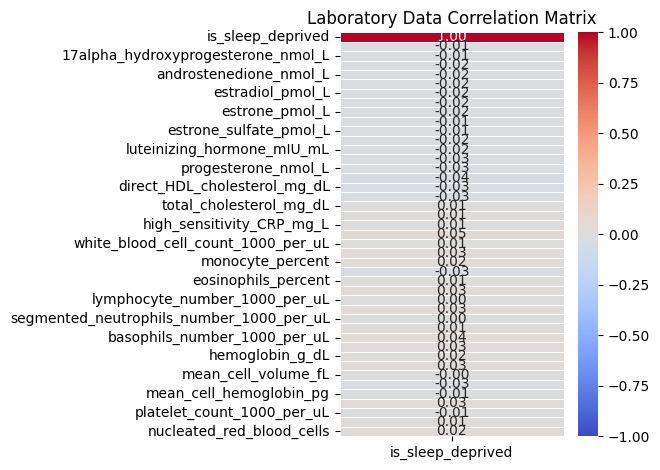

,is_sleep_deprived
is_sleep_deprived,1.00
17alpha_hydroxyprogesterone_ng_dL,-0.01
17alpha_hydroxyprogesterone_nmol_L,-0.01
androstenedione_ng_dL,-0.02
androstenedione_nmol_L,-0.02
estradiol_pg_mL,-0.02
estradiol_pmol_L,-0.02
estrone_ng_dL,-0.02
estrone_pmol_L,-0.02
estrone_sulfate_pg_mL,-0.01


In [42]:
create_correlation_matrix(df_lab_numeric, dataset_cat="Laboratory Data Correlation Matrix")

In [43]:
# df_cbc = df_cbc.rename(columns=column_mapping)
# df_ghb = df_ghb.rename(columns=column_mapping)
# df_glu = df_glu.rename(columns=column_mapping)
# df_hscrp = df_hscrp.rename(columns=column_mapping)
# df_ins = df_ins.rename(columns=column_mapping)
# df_tchol = df_tchol.rename(columns=column_mapping)
# df_tst = df_tst.rename(columns=column_mapping)

In [44]:
# create_correlation_matrix(df_cbc, dataset_cat="Complete Blood Count")
# create_correlation_matrix(df_ghb, dataset_cat="Glycohemoglobin")
# create_correlation_matrix(df_hscrp, dataset_cat="High-Sensitivity C-Reactive Protein")
# create_correlation_matrix(df_tchol, dataset_cat="Cholesterol - Total")
# create_correlation_matrix(df_tst, dataset_cat="Sex Steroid Hormone")
# create_correlation_matrix(df_bmx, dataset_cat="Body Measures")
# create_correlation_matrix(df_bpxo, dataset_cat="Blood Pressure")

#### Demographics Correlation

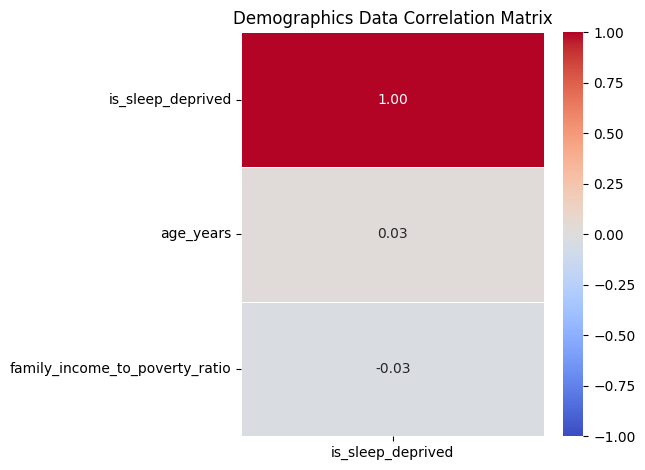

,is_sleep_deprived
is_sleep_deprived,1.00
age_years,0.03
family_income_to_poverty_ratio,-0.03


In [45]:
create_correlation_matrix(df_demo_numeric, dataset_cat="Demographics Data Correlation Matrix")

#### Examination Correlation

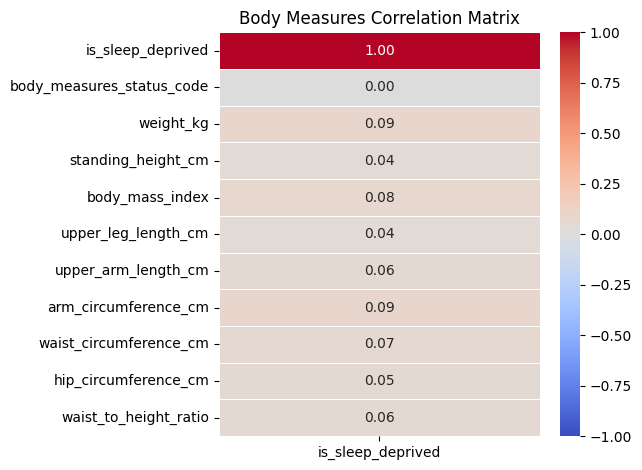

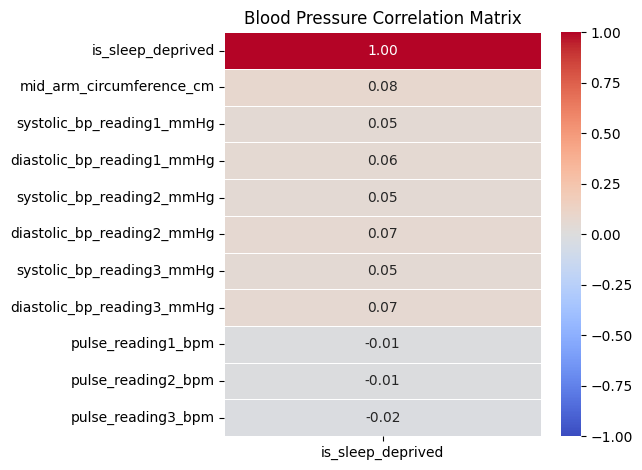

,is_sleep_deprived
is_sleep_deprived,1.00
mid_arm_circumference_cm,0.08
systolic_bp_reading1_mmHg,0.05
diastolic_bp_reading1_mmHg,0.06
systolic_bp_reading2_mmHg,0.05
diastolic_bp_reading2_mmHg,0.07
systolic_bp_reading3_mmHg,0.05
diastolic_bp_reading3_mmHg,0.07
pulse_reading1_bpm,-0.01
pulse_reading2_bpm,-0.01


In [46]:
create_correlation_matrix(df_bmx, dataset_cat="Body Measures Correlation Matrix")
create_correlation_matrix(df_bpxo, dataset_cat="Blood Pressure Correlation Matrix")

### Boxplot

#### Laboratory Boxplot

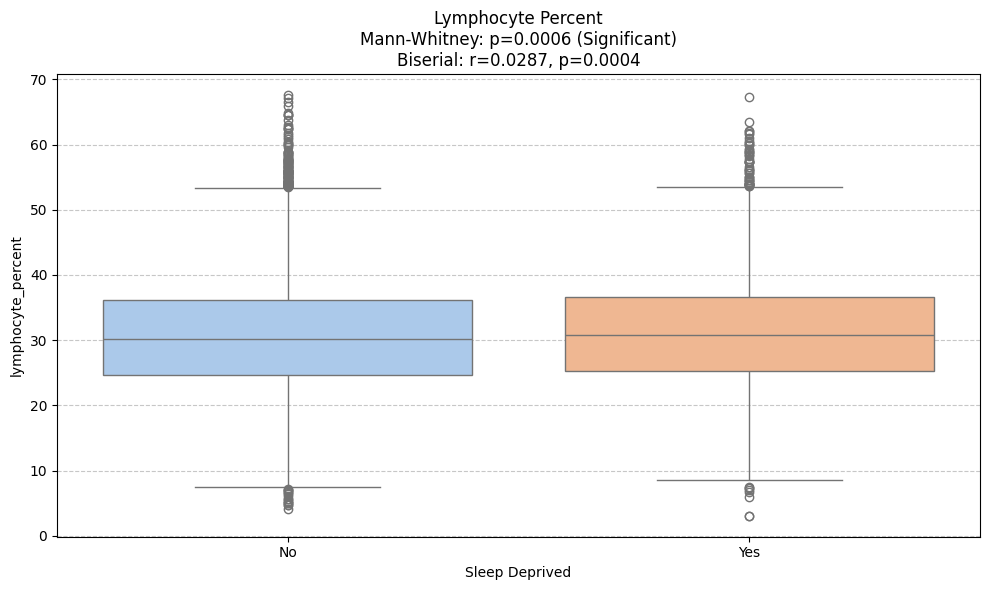


Statistical Summary:
Variable: lymphocyte_percent
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min   25%   75%   Max
            No  11664 30.72   30.20     8.76 4.20 24.70 36.20 89.70
           Yes   3340 31.33   30.90     8.97 3.10 25.30 36.60 88.80
------------------------------------------------------------
Mann-Whitney U test results: U=18724524.5, p-value=0.0006
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


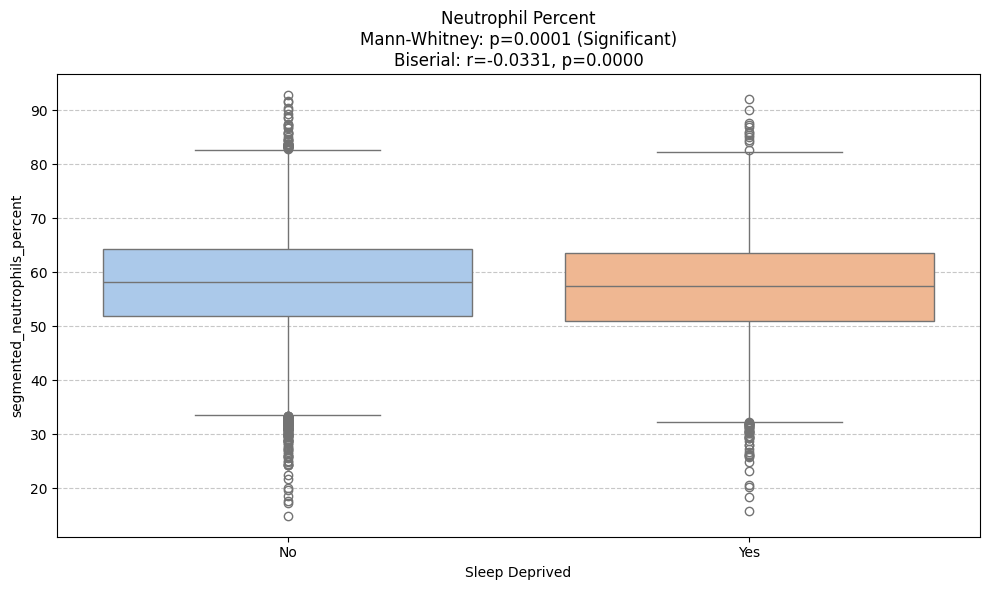


Statistical Summary:
Variable: segmented_neutrophils_percent
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min   25%   75%   Max
            No  11664 57.77   58.20     9.45 8.40 51.90 64.20 92.80
           Yes   3340 57.01   57.45     9.84 8.40 51.00 63.50 92.10
------------------------------------------------------------
Mann-Whitney U test results: U=20330672.0, p-value=0.0001
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


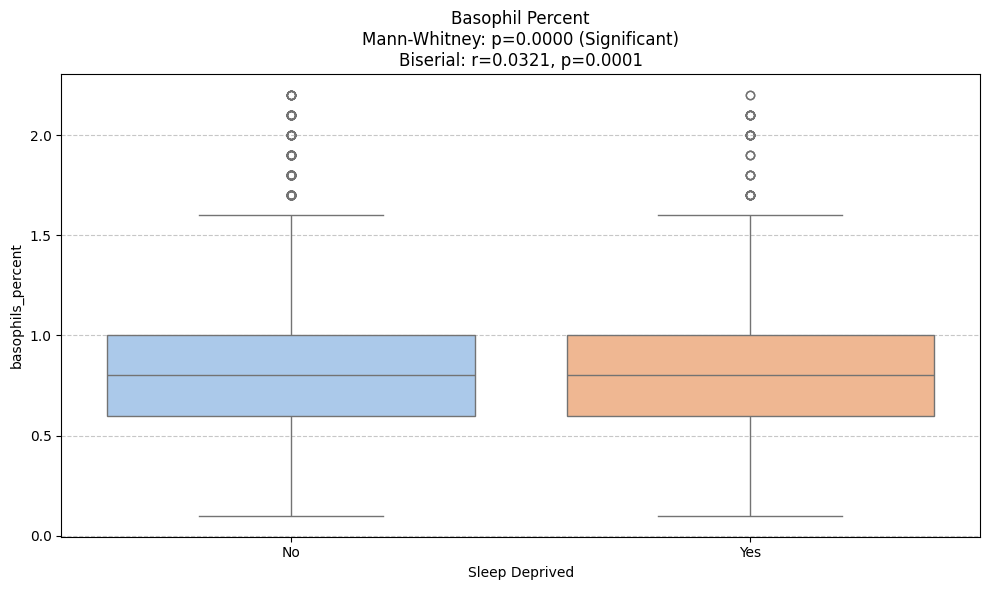


Statistical Summary:
Variable: basophils_percent
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min  25%  75%  Max
            No  11664  0.80    0.80     0.33 0.10 0.60 1.00 4.80
           Yes   3340  0.82    0.80     0.32 0.10 0.60 1.00 3.90
------------------------------------------------------------
Mann-Whitney U test results: U=18289442.0, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


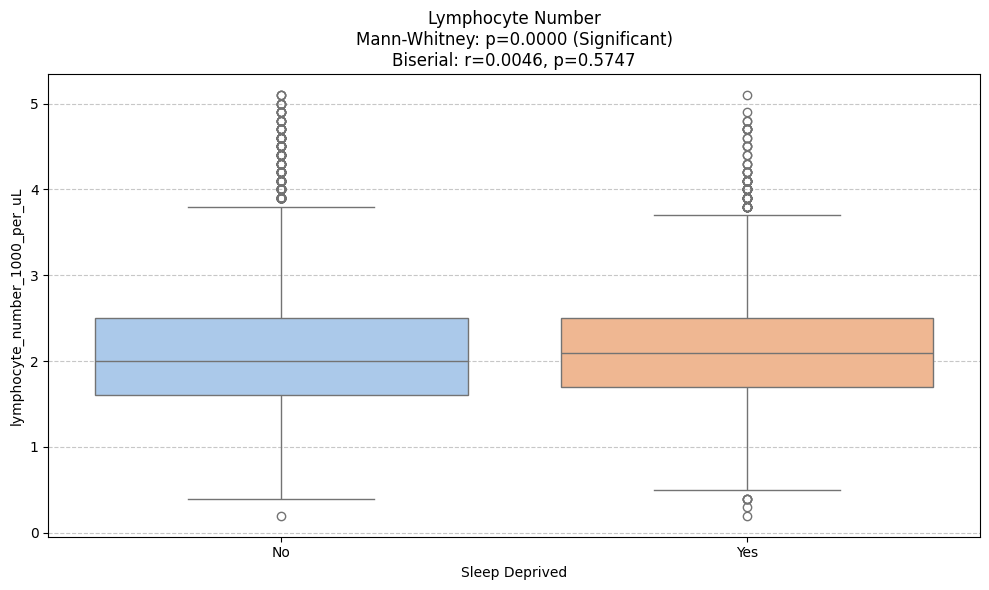


Statistical Summary:
Variable: lymphocyte_number_1000_per_uL
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min  25%  75%    Max
            No  11664  2.14    2.00     3.42 0.20 1.60 2.50 358.80
           Yes   3340  2.18    2.10     1.32 0.20 1.70 2.52  65.90
------------------------------------------------------------
Mann-Whitney U test results: U=18578086.5, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


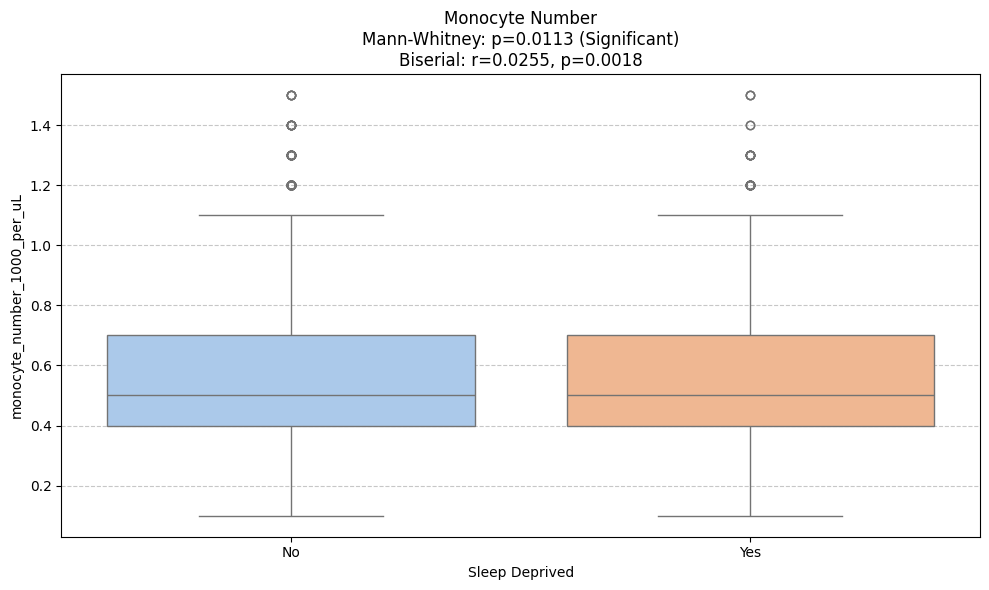


Statistical Summary:
Variable: monocyte_number_1000_per_uL
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min  25%  75%  Max
            No  11664  0.56    0.50     0.19 0.10 0.40 0.70 2.80
           Yes   3340  0.57    0.50     0.22 0.10 0.40 0.70 6.70
------------------------------------------------------------
Mann-Whitney U test results: U=18929258.5, p-value=0.0113
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


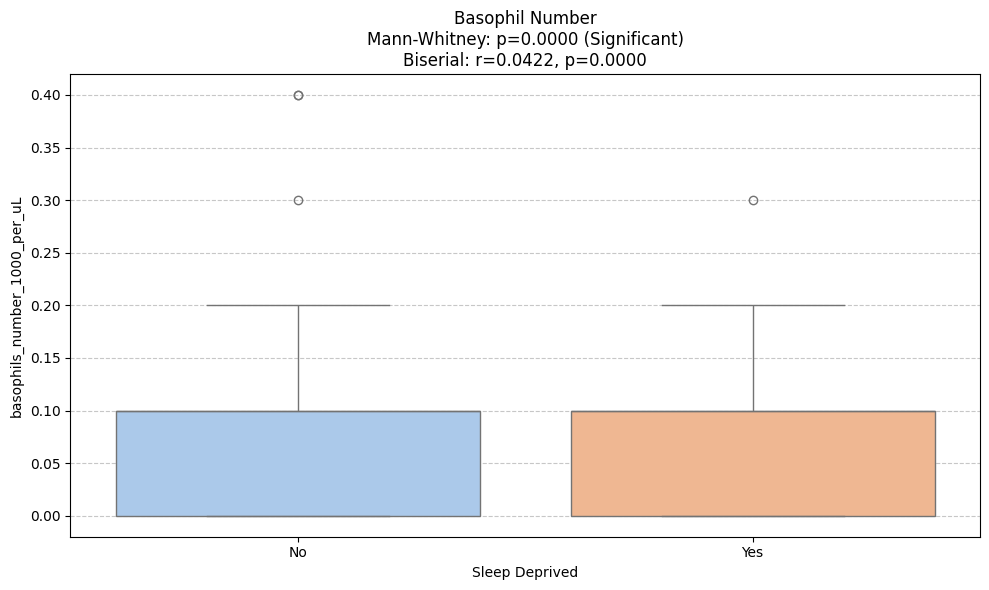


Statistical Summary:
Variable: basophils_number_1000_per_uL
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min  25%  75%  Max
            No  11664  0.05    0.10     0.05 0.00 0.00 0.10 0.50
           Yes   3340  0.06    0.10     0.05 0.00 0.00 0.10 0.30
------------------------------------------------------------
Mann-Whitney U test results: U=18460837.0, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


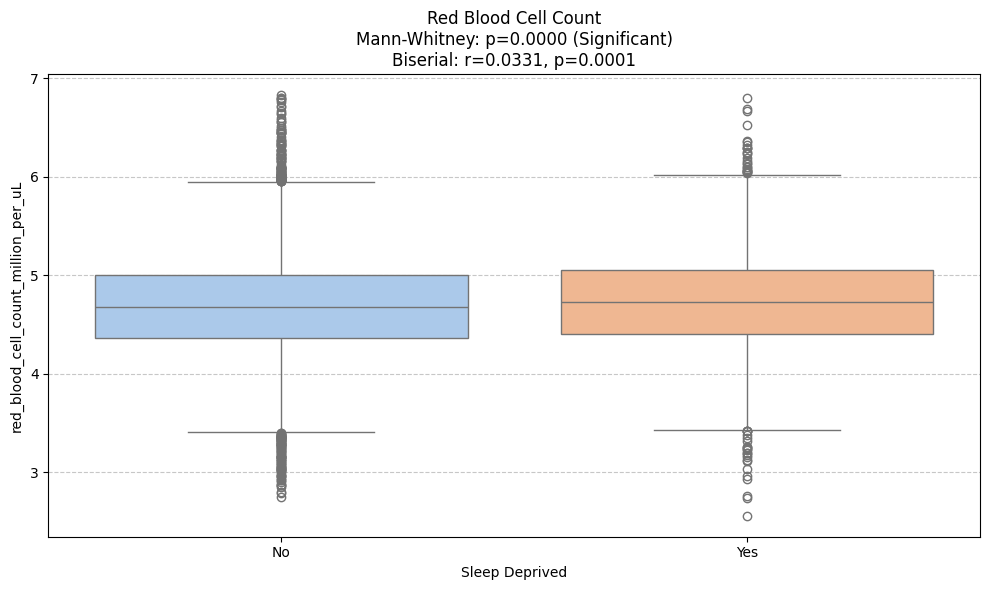


Statistical Summary:
Variable: red_blood_cell_count_million_per_uL
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min  25%  75%  Max
            No  11674  4.69    4.68     0.50 2.32 4.36 5.00 7.97
           Yes   3343  4.73    4.73     0.50 2.44 4.40 5.05 6.80
------------------------------------------------------------
Mann-Whitney U test results: U=18508320.5, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


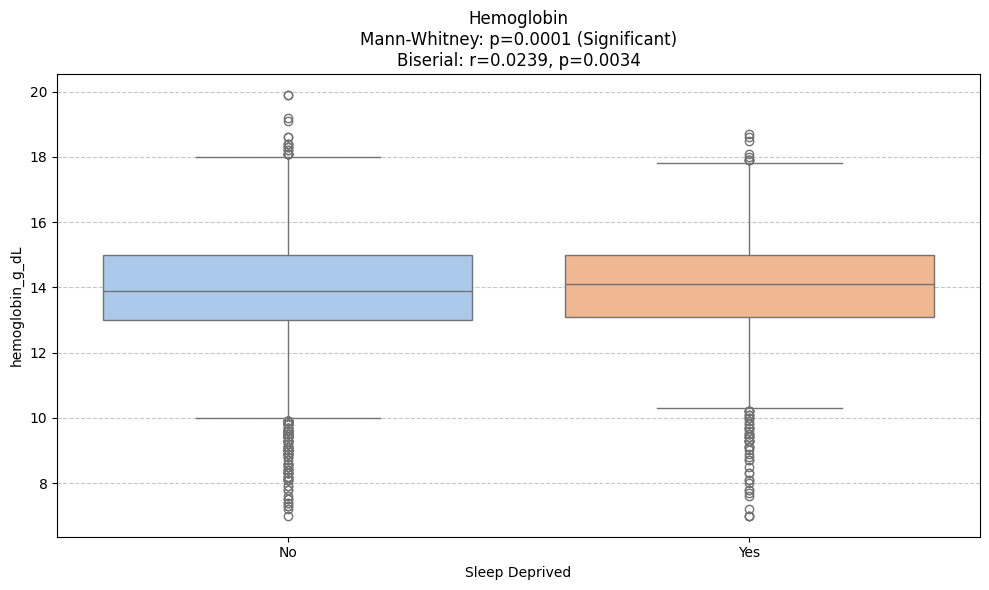


Statistical Summary:
Variable: hemoglobin_g_dL
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min   25%   75%   Max
            No  11674 13.91   13.90     1.53 5.40 13.00 15.00 19.90
           Yes   3343 14.00   14.10     1.54 6.30 13.10 15.00 18.70
------------------------------------------------------------
Mann-Whitney U test results: U=18628100.0, p-value=0.0001
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


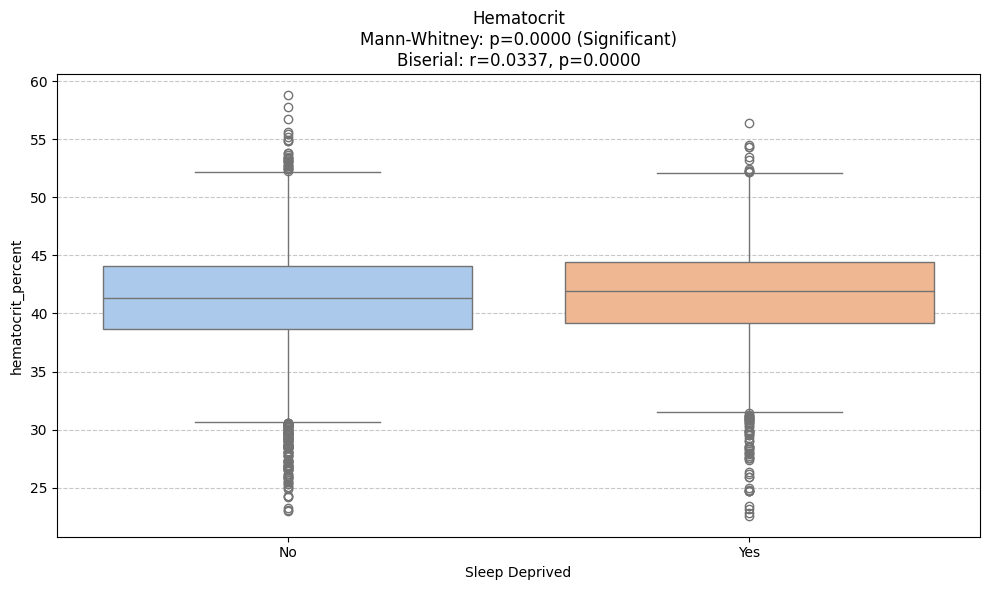


Statistical Summary:
Variable: hematocrit_percent
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev   Min   25%   75%   Max
            No  11674 41.33   41.30     4.15 21.10 38.70 44.10 58.80
           Yes   3343 41.67   41.90     4.19 19.90 39.20 44.40 56.40
------------------------------------------------------------
Mann-Whitney U test results: U=18357106.5, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


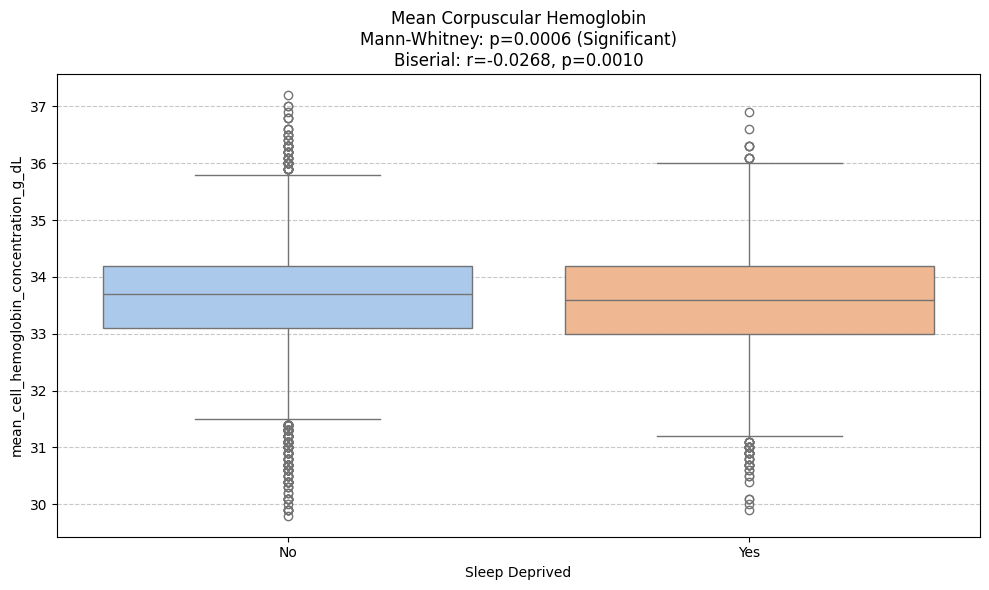


Statistical Summary:
Variable: mean_cell_hemoglobin_concentration_g_dL
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev   Min   25%   75%   Max
            No  11674 33.63   33.70     0.94 25.20 33.10 34.20 40.50
           Yes   3343 33.57   33.60     0.95 27.70 33.00 34.20 36.90
------------------------------------------------------------
Mann-Whitney U test results: U=20267328.0, p-value=0.0006
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


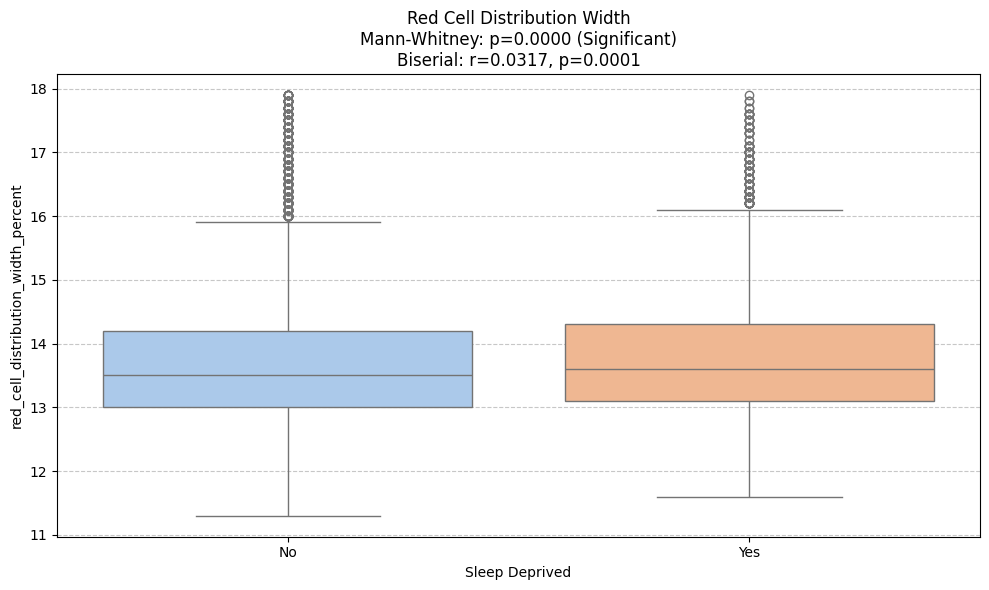


Statistical Summary:
Variable: red_cell_distribution_width_percent
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev   Min   25%   75%   Max
            No  11674 13.84   13.50     1.37 11.30 13.00 14.20 37.50
           Yes   3343 13.95   13.70     1.40 11.60 13.10 14.40 32.10
------------------------------------------------------------
Mann-Whitney U test results: U=18234925.5, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


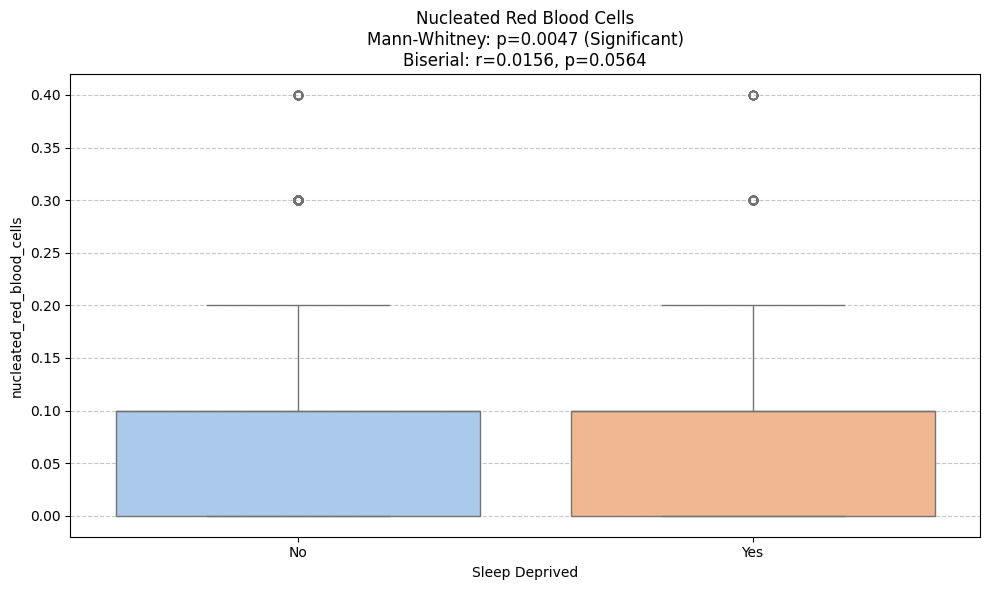


Statistical Summary:
Variable: nucleated_red_blood_cells
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min  25%  75%  Max
            No  11663  0.08    0.10     0.10 0.00 0.00 0.10 4.00
           Yes   3340  0.08    0.10     0.09 0.00 0.00 0.10 3.00
------------------------------------------------------------
Mann-Whitney U test results: U=18921756.5, p-value=0.0047
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


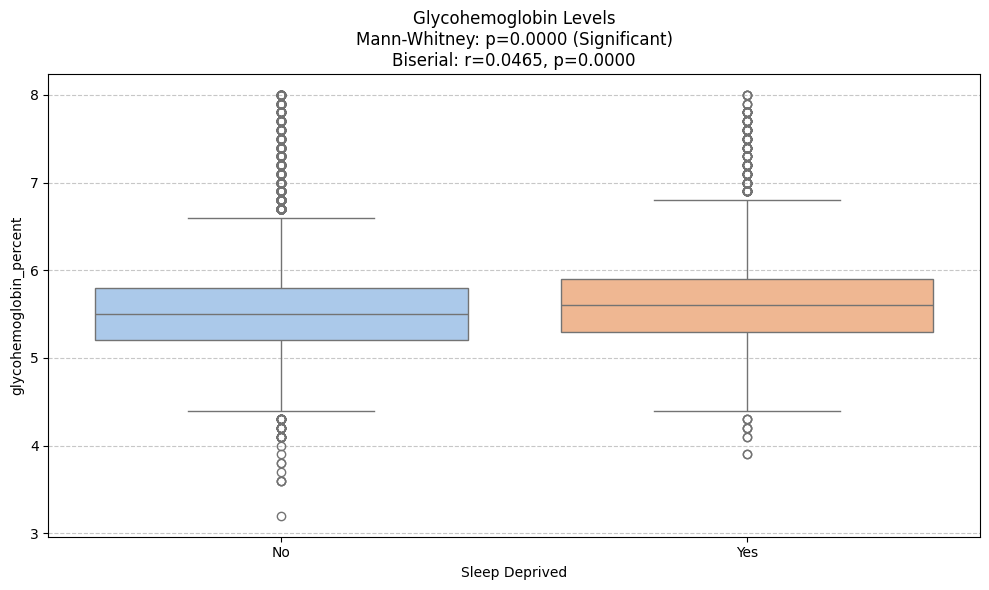


Statistical Summary:
Variable: glycohemoglobin_percent
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min  25%  75%   Max
            No  11637  5.75    5.50     1.06 3.20 5.20 5.90 17.10
           Yes   3334  5.87    5.60     1.16 2.80 5.30 6.00 17.10
------------------------------------------------------------
Mann-Whitney U test results: U=17563035.5, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


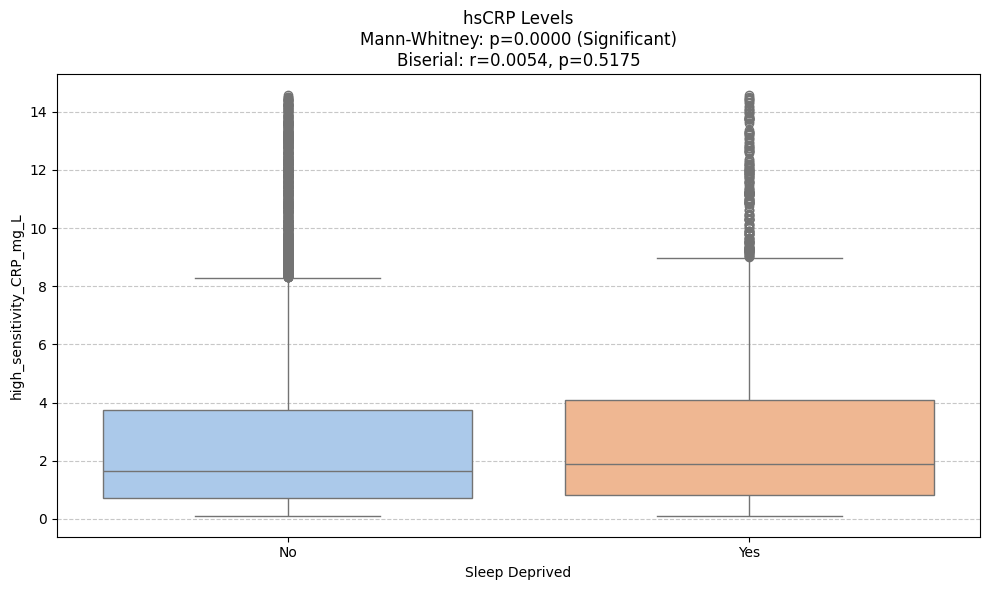


Statistical Summary:
Variable: high_sensitivity_CRP_mg_L
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min  25%  75%    Max
            No  11310  3.91    1.75     8.46 0.11 0.75 4.16 246.86
           Yes   3238  4.01    2.02     7.08 0.11 0.85 4.54 138.81
------------------------------------------------------------
Mann-Whitney U test results: U=17340609.0, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


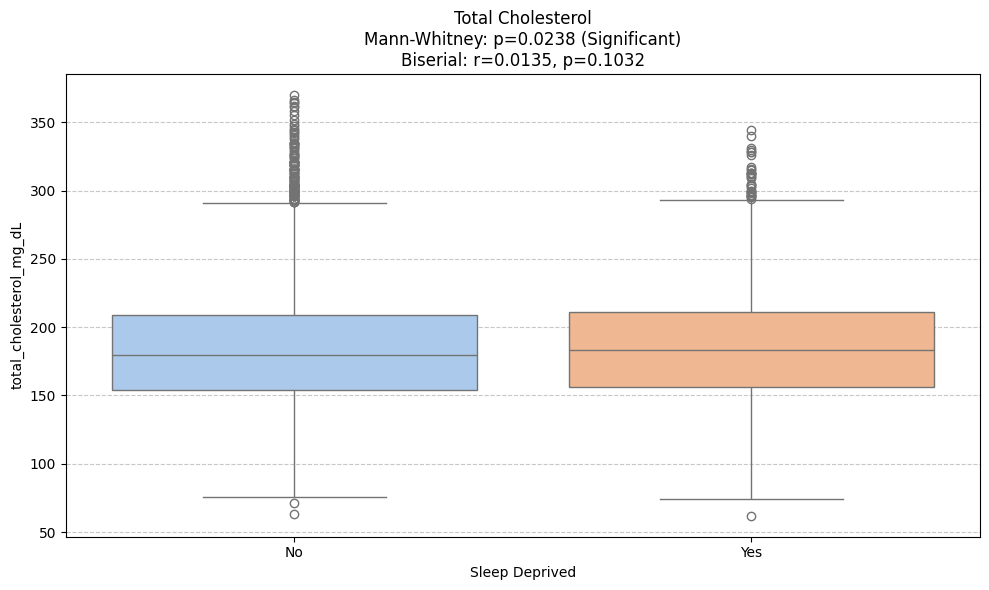


Statistical Summary:
Variable: total_cholesterol_mg_dL
------------------------------------------------------------
Sleep Deprived  Count   Mean  Median  Std Dev   Min    25%    75%    Max
            No  11276 183.83  180.00    41.86 63.00 154.00 209.00 438.00
           Yes   3230 185.19  183.00    41.12 62.00 156.00 211.00 446.00
------------------------------------------------------------
Mann-Whitney U test results: U=17736533.5, p-value=0.0238
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


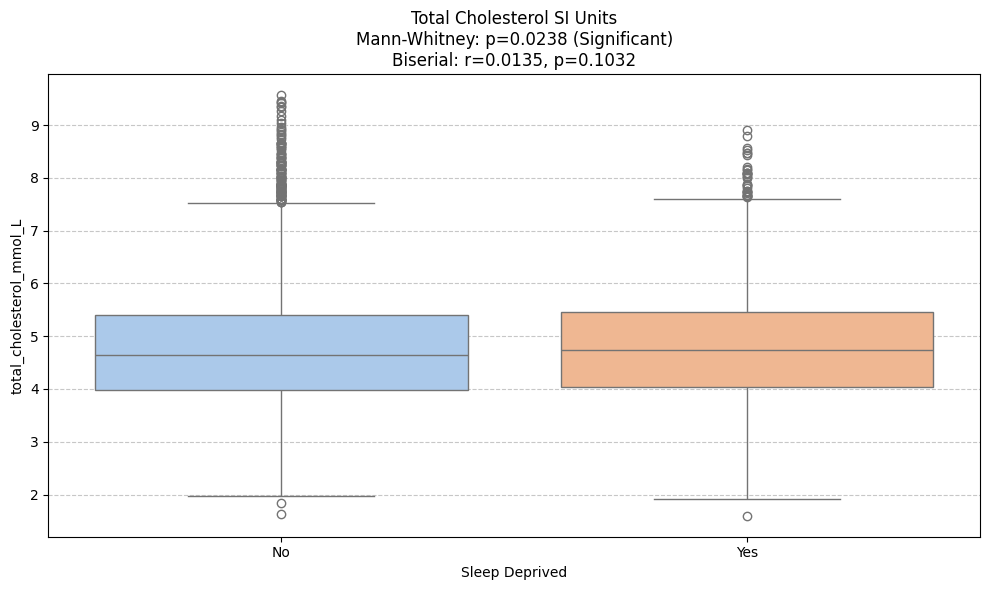


Statistical Summary:
Variable: total_cholesterol_mmol_L
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min  25%  75%   Max
            No  11276  4.75    4.65     1.08 1.63 3.98 5.40 11.33
           Yes   3230  4.79    4.73     1.06 1.60 4.03 5.46 11.53
------------------------------------------------------------
Mann-Whitney U test results: U=17736533.5, p-value=0.0238
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


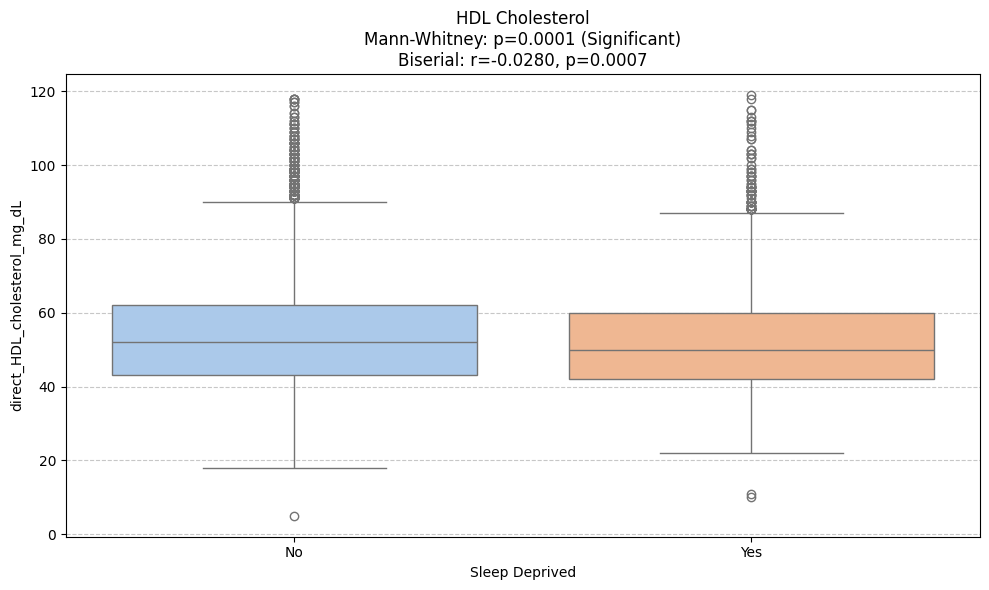


Statistical Summary:
Variable: direct_HDL_cholesterol_mg_dL
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev   Min   25%   75%    Max
            No  11276 53.97   52.00    15.21  5.00 43.00 62.00 187.00
           Yes   3230 52.94   50.00    15.28 10.00 42.00 61.00 189.00
------------------------------------------------------------
Mann-Whitney U test results: U=19019045.5, p-value=0.0001
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


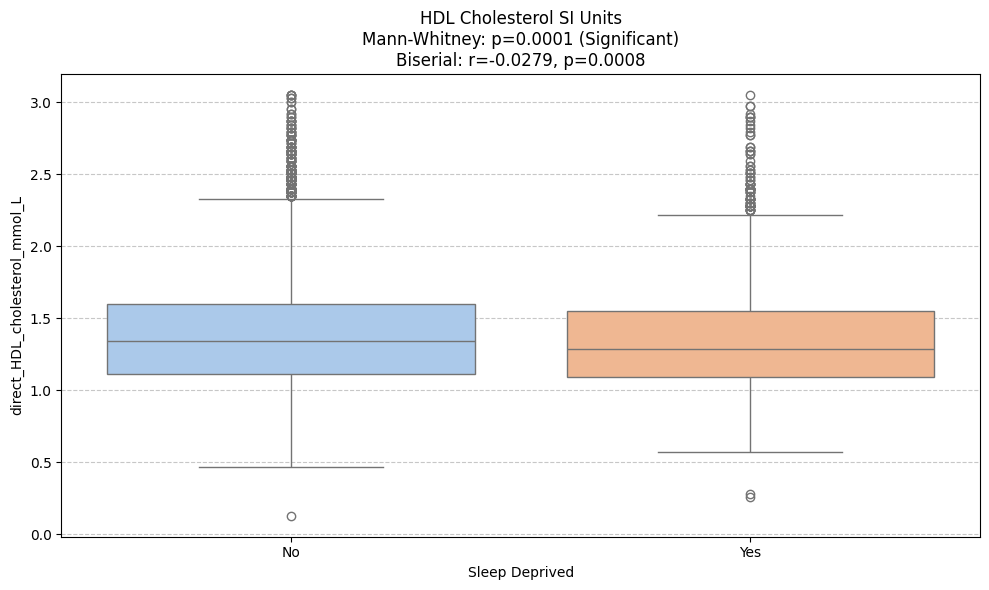


Statistical Summary:
Variable: direct_HDL_cholesterol_mmol_L
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min  25%  75%  Max
            No  11276  1.40    1.34     0.39 0.13 1.11 1.60 4.84
           Yes   3230  1.37    1.29     0.40 0.26 1.09 1.58 4.89
------------------------------------------------------------
Mann-Whitney U test results: U=19019045.5, p-value=0.0001
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


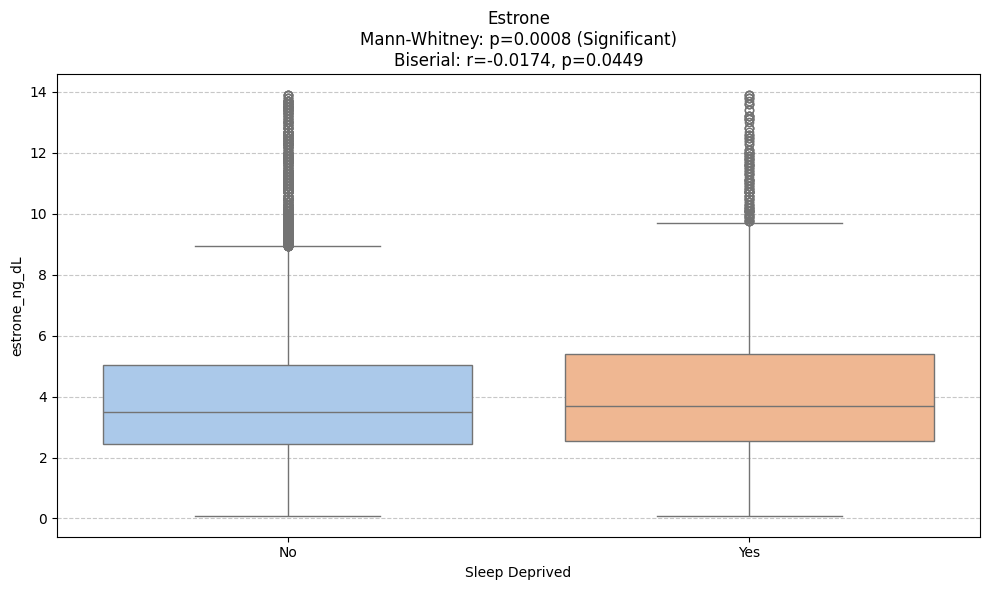


Statistical Summary:
Variable: estrone_ng_dL
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min  25%  75%    Max
            No  10375  5.90    3.56    21.52 0.09 2.49 5.28 498.00
           Yes   2938  5.07    3.75    11.57 0.09 2.57 5.56 510.00
------------------------------------------------------------
Mann-Whitney U test results: U=14622648.5, p-value=0.0008
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


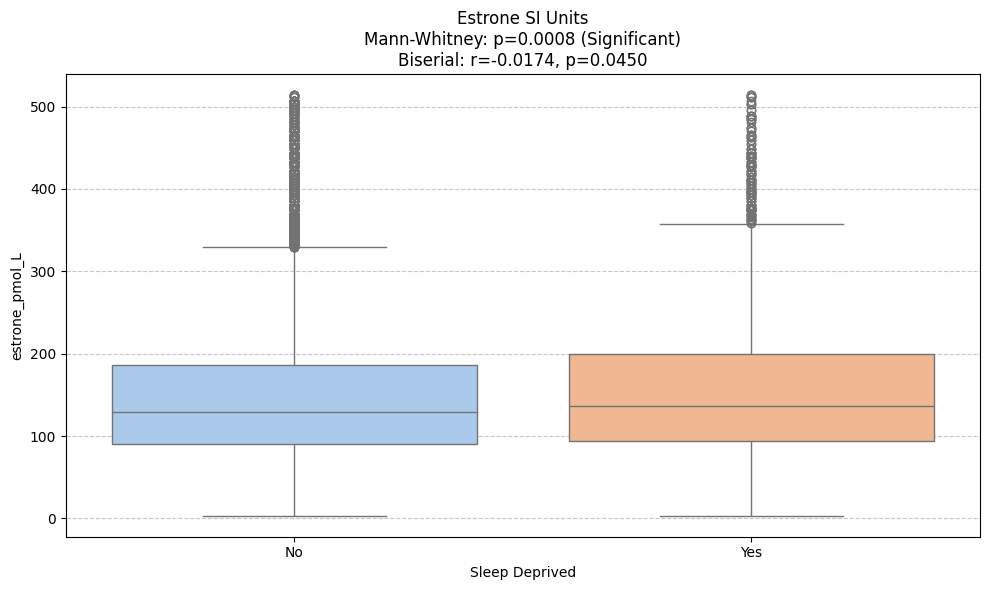


Statistical Summary:
Variable: estrone_pmol_L
------------------------------------------------------------
Sleep Deprived  Count   Mean  Median  Std Dev  Min   25%    75%      Max
            No  10375 218.12  132.00   795.65 3.40 92.10 195.00 18400.00
           Yes   2938 187.51  139.00   428.58 3.40 95.20 205.75 18900.00
------------------------------------------------------------
Mann-Whitney U test results: U=14622871.0, p-value=0.0008
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


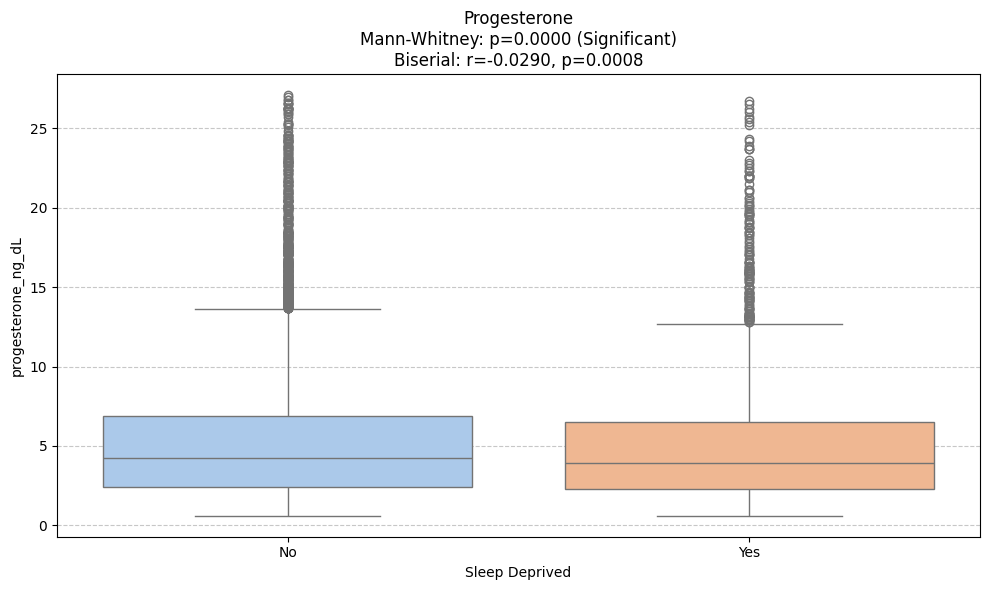


Statistical Summary:
Variable: progesterone_ng_dL
------------------------------------------------------------
Sleep Deprived  Count   Mean  Median  Std Dev  Min  25%  75%      Max
            No  10510 118.76    4.76   652.88 0.61 2.67 8.93 16200.00
           Yes   2990  76.82    4.38   362.55 0.61 2.45 8.04 10100.00
------------------------------------------------------------
Mann-Whitney U test results: U=16535461.0, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


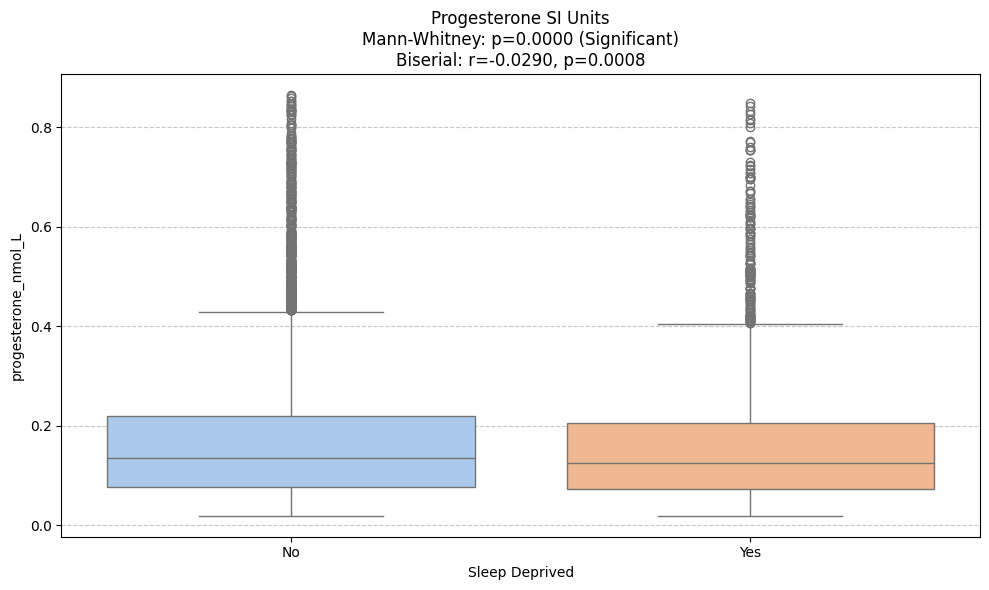


Statistical Summary:
Variable: progesterone_nmol_L
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min  25%  75%    Max
            No  10510  3.78    0.15    20.76 0.02 0.08 0.28 515.00
           Yes   2990  2.44    0.14    11.53 0.02 0.08 0.26 321.00
------------------------------------------------------------
Mann-Whitney U test results: U=16535476.0, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


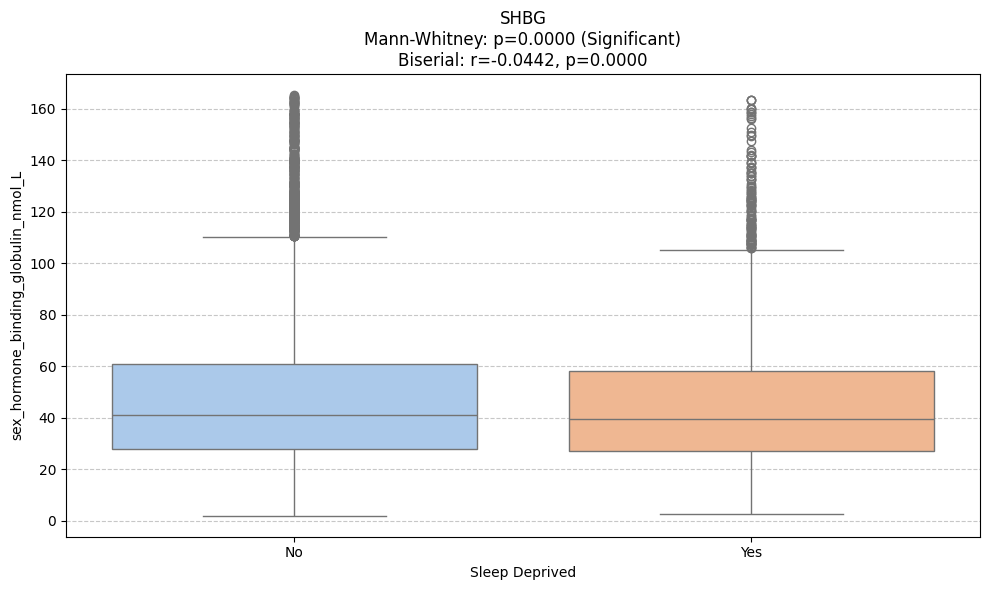


Statistical Summary:
Variable: sex_hormone_binding_globulin_nmol_L
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min   25%   75%    Max
            No  10559 53.31   42.06    46.10 2.05 28.31 63.32 895.50
           Yes   3016 48.63   40.09    35.31 2.54 27.19 59.85 671.90
------------------------------------------------------------
Mann-Whitney U test results: U=16704585.0, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


In [47]:
# Complete Blood Count dataset
create_boxplot(df_lab, 'lymphocyte_percent', dataset_cat="Lymphocyte Percent")
create_boxplot(df_lab, 'segmented_neutrophils_percent', dataset_cat="Neutrophil Percent")
create_boxplot(df_lab, 'basophils_percent', dataset_cat="Basophil Percent")
create_boxplot(df_lab, 'lymphocyte_number_1000_per_uL', dataset_cat="Lymphocyte Number")
create_boxplot(df_lab, 'monocyte_number_1000_per_uL', dataset_cat="Monocyte Number")
create_boxplot(df_lab, 'basophils_number_1000_per_uL', dataset_cat="Basophil Number")
create_boxplot(df_lab, 'red_blood_cell_count_million_per_uL', dataset_cat="Red Blood Cell Count")
create_boxplot(df_lab, 'hemoglobin_g_dL', dataset_cat="Hemoglobin")
create_boxplot(df_lab, 'hematocrit_percent', dataset_cat="Hematocrit")
create_boxplot(df_lab, 'mean_cell_hemoglobin_concentration_g_dL', dataset_cat="Mean Corpuscular Hemoglobin")
create_boxplot(df_lab, 'red_cell_distribution_width_percent', dataset_cat="Red Cell Distribution Width")
create_boxplot(df_lab, 'nucleated_red_blood_cells', dataset_cat="Nucleated Red Blood Cells")

# Glycohemoglobin dataset
create_boxplot(df_lab, 'glycohemoglobin_percent', dataset_cat="Glycohemoglobin Levels")

# High-Sensitivity C-Reactive Protein dataset
create_boxplot(df_lab, 'high_sensitivity_CRP_mg_L', dataset_cat="hsCRP Levels")

# Cholesterol dataset
create_boxplot(df_lab, 'total_cholesterol_mg_dL', dataset_cat="Total Cholesterol")
create_boxplot(df_lab, 'total_cholesterol_mmol_L', dataset_cat="Total Cholesterol SI Units")
create_boxplot(df_lab, 'direct_HDL_cholesterol_mg_dL', dataset_cat="HDL Cholesterol")
create_boxplot(df_lab, 'direct_HDL_cholesterol_mmol_L', dataset_cat="HDL Cholesterol SI Units")

# Sex Steroid Hormone dataset
create_boxplot(df_lab, 'estrone_ng_dL', dataset_cat="Estrone")
create_boxplot(df_lab, 'estrone_pmol_L', dataset_cat="Estrone SI Units")
create_boxplot(df_lab, 'progesterone_ng_dL', dataset_cat="Progesterone")
create_boxplot(df_lab, 'progesterone_nmol_L', dataset_cat="Progesterone SI Units")
create_boxplot(df_lab, 'sex_hormone_binding_globulin_nmol_L', dataset_cat="SHBG")

#### Demographics Boxplot

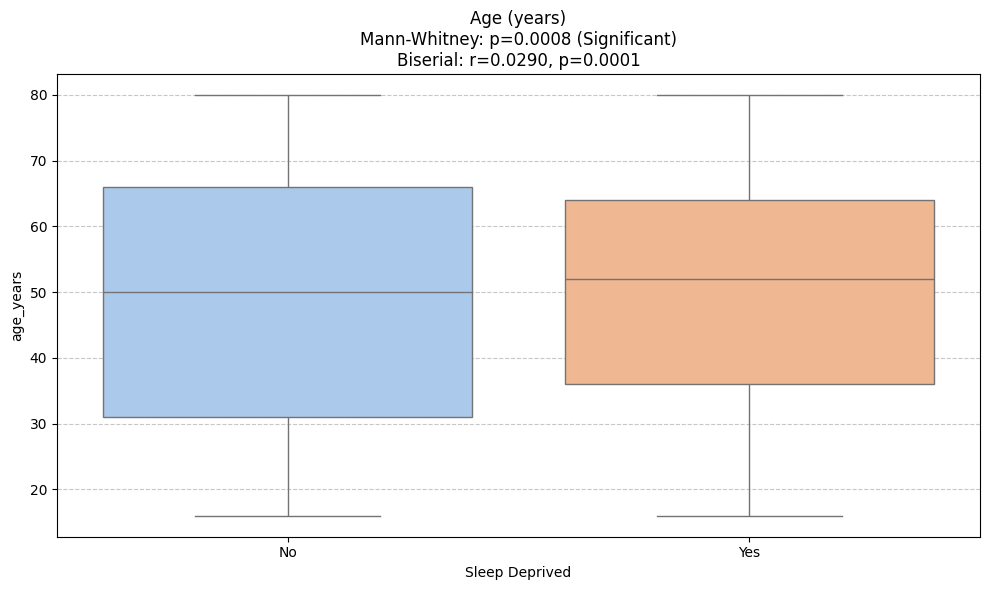


Statistical Summary:
Variable: age_years
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev   Min   25%   75%   Max
            No  14424 48.80   50.00    20.10 16.00 31.00 66.00 80.00
           Yes   4014 50.17   52.00    17.44 16.00 36.00 64.00 80.00
------------------------------------------------------------
Mann-Whitney U test results: U=27952408.5, p-value=0.0008
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


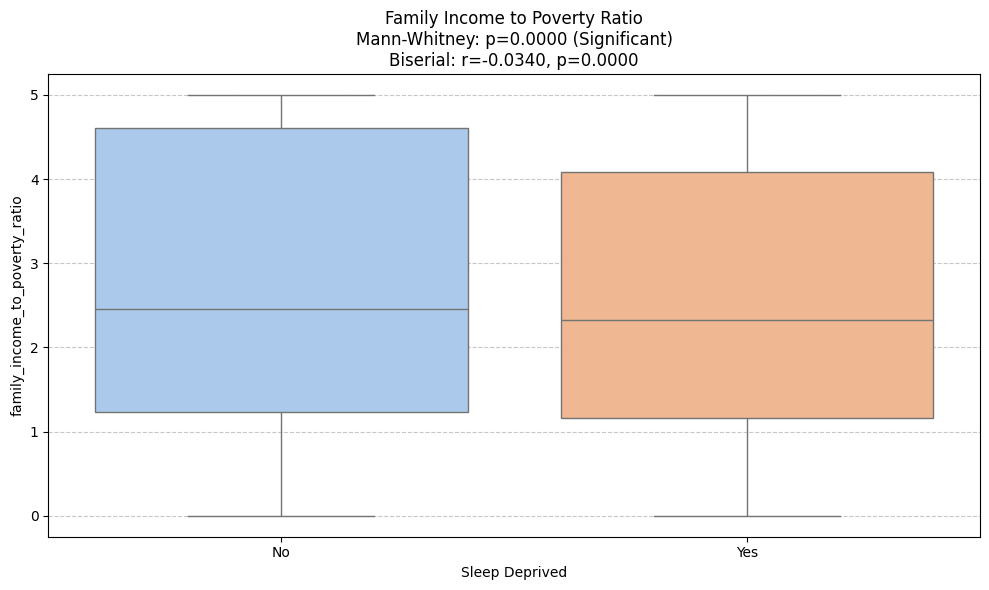


Statistical Summary:
Variable: family_income_to_poverty_ratio
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min  25%  75%  Max
            No  12164  2.73    2.46     1.66 0.00 1.23 4.61 5.00
           Yes   3390  2.59    2.32     1.61 0.00 1.16 4.08 5.00
------------------------------------------------------------
Mann-Whitney U test results: U=21570680.5, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


In [48]:
# Demographic variables
create_boxplot(df_demo, 'age_years', dataset_cat="Age (years)")
create_boxplot(df_demo, 'family_income_to_poverty_ratio', dataset_cat="Family Income to Poverty Ratio")

#### Examination Boxplot

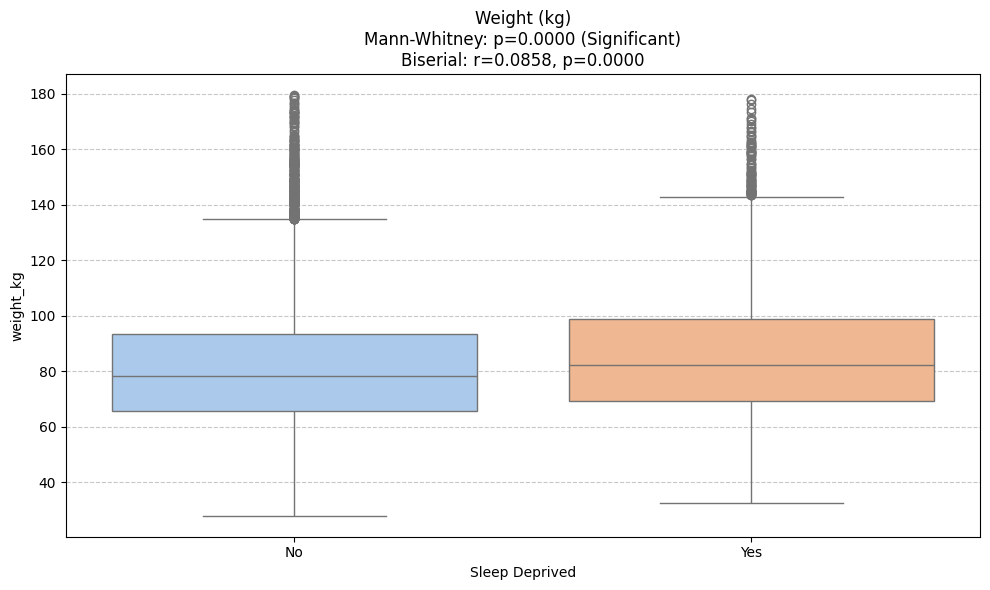


Statistical Summary:
Variable: weight_kg
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev   Min   25%   75%    Max
            No  12167 81.54   78.20    22.42 27.90 65.70 93.40 248.20
           Yes   3462 86.28   82.25    24.34 32.60 69.22 99.07 254.30
------------------------------------------------------------
Mann-Whitney U test results: U=18605730.0, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


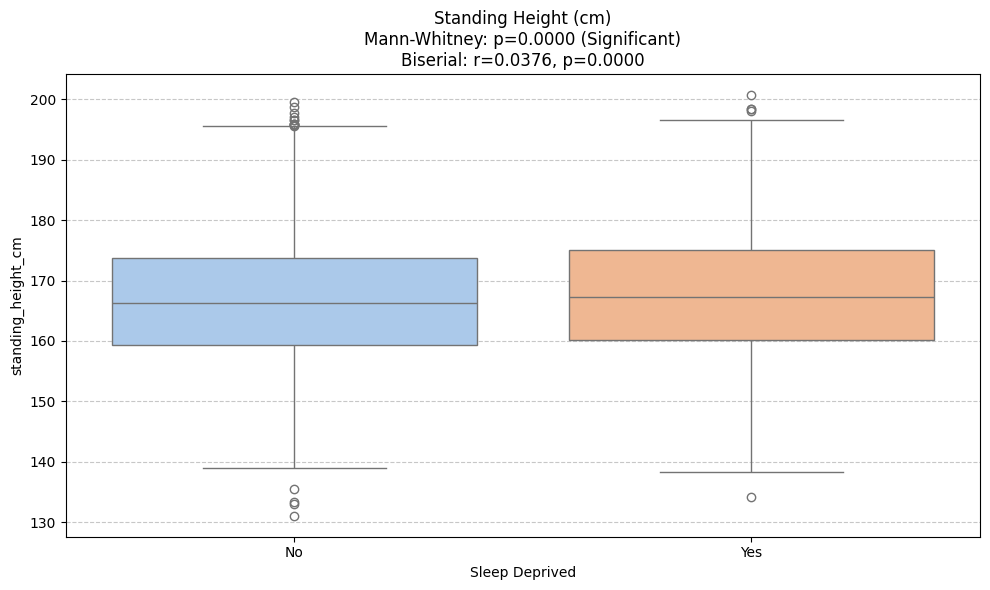


Statistical Summary:
Variable: standing_height_cm
------------------------------------------------------------
Sleep Deprived  Count   Mean  Median  Std Dev    Min    25%    75%    Max
            No  12170 166.69  166.30    10.01 131.10 159.30 173.80 199.60
           Yes   3467 167.60  167.30    10.11 134.20 160.10 175.00 200.70
------------------------------------------------------------
Mann-Whitney U test results: U=20001132.0, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


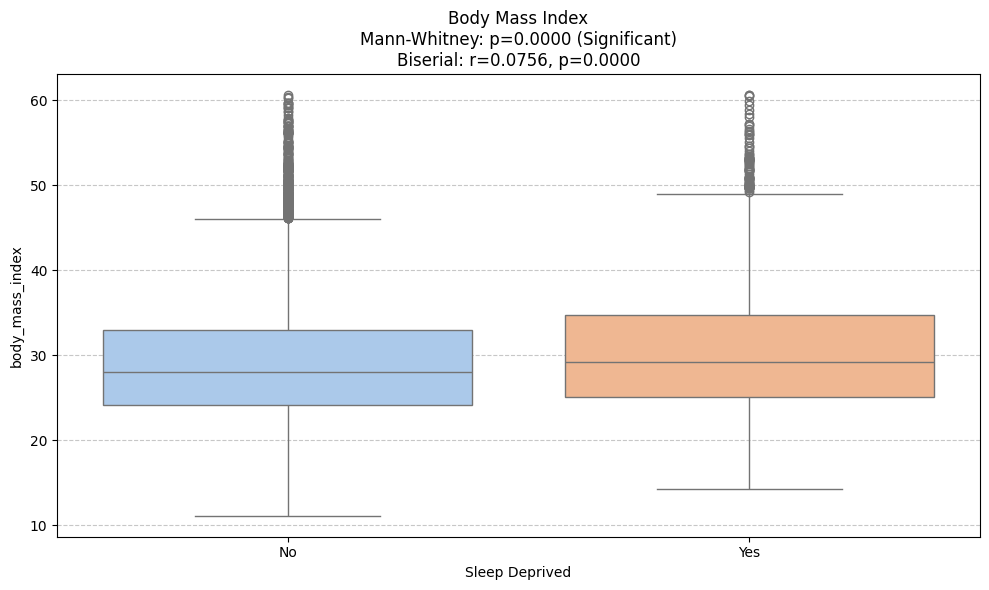


Statistical Summary:
Variable: body_mass_index
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev   Min   25%   75%   Max
            No  12139 29.27   28.00     7.38 11.10 24.10 33.00 86.20
           Yes   3458 30.64   29.20     8.00 14.20 25.10 34.80 92.30
------------------------------------------------------------
Mann-Whitney U test results: U=18805329.0, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


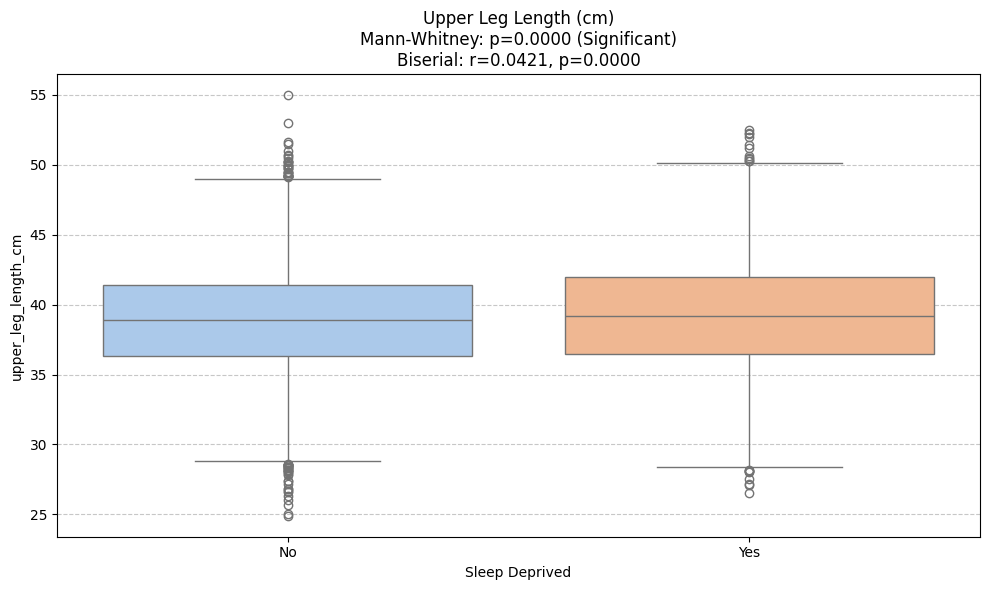


Statistical Summary:
Variable: upper_leg_length_cm
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev   Min   25%   75%   Max
            No  11621 38.90   38.90     3.74 24.90 36.30 41.40 55.00
           Yes   3290 39.28   39.20     3.92 26.50 36.50 42.00 52.50
------------------------------------------------------------
Mann-Whitney U test results: U=18030961.0, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


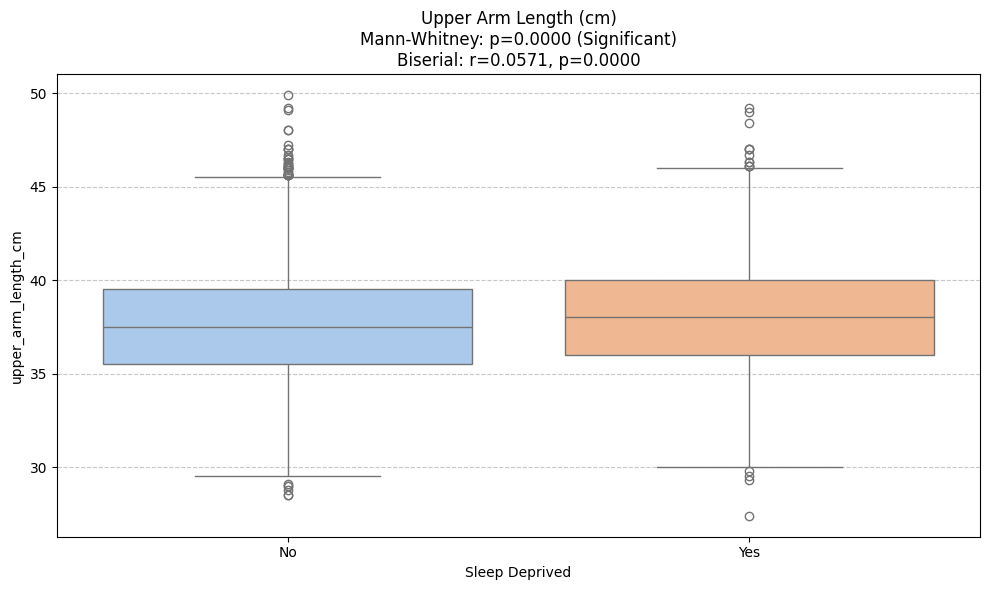


Statistical Summary:
Variable: upper_arm_length_cm
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev   Min   25%   75%   Max
            No  11877 37.52   37.50     2.87 28.50 35.50 39.50 49.90
           Yes   3391 37.92   38.00     2.90 27.40 36.00 40.00 49.20
------------------------------------------------------------
Mann-Whitney U test results: U=18525593.5, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


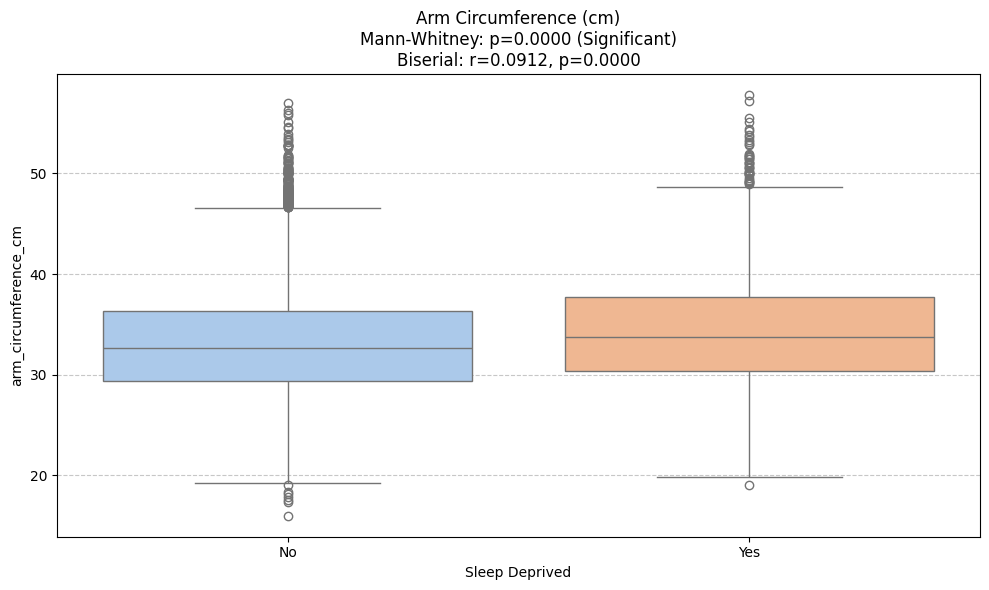


Statistical Summary:
Variable: arm_circumference_cm
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev   Min   25%   75%   Max
            No  11874 33.14   32.70     5.30 16.00 29.40 36.30 64.50
           Yes   3390 34.33   33.80     5.65 19.00 30.40 37.70 61.90
------------------------------------------------------------
Mann-Whitney U test results: U=17647921.5, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


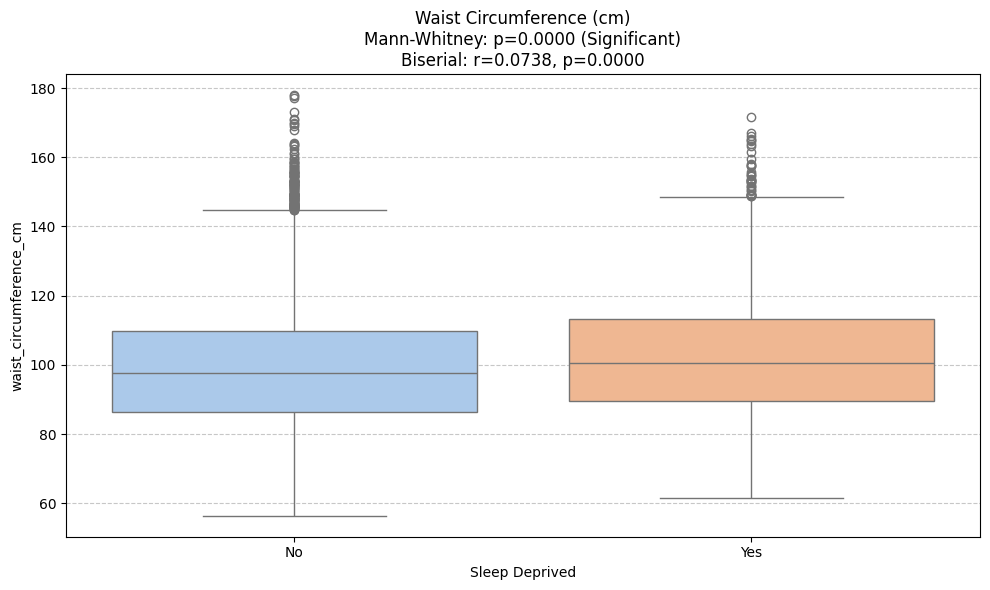


Statistical Summary:
Variable: waist_circumference_cm
------------------------------------------------------------
Sleep Deprived  Count   Mean  Median  Std Dev   Min   25%    75%    Max
            No  11701  98.95   97.70    17.36 56.40 86.40 109.80 187.50
           Yes   3338 102.06  100.50    17.99 61.40 89.50 113.17 171.50
------------------------------------------------------------
Mann-Whitney U test results: U=17569747.5, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


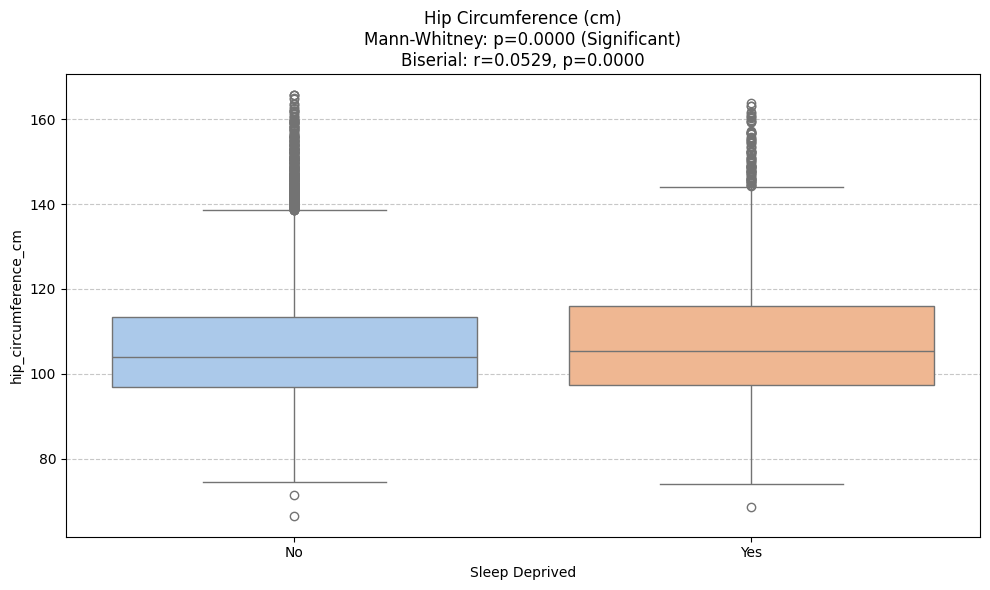


Statistical Summary:
Variable: hip_circumference_cm
------------------------------------------------------------
Sleep Deprived  Count   Mean  Median  Std Dev   Min   25%    75%    Max
            No  11664 106.62  104.00    14.33 66.60 96.80 113.70 187.50
           Yes   3329 108.48  105.50    15.45 68.70 97.40 116.30 177.40
------------------------------------------------------------
Mann-Whitney U test results: U=18126874.0, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


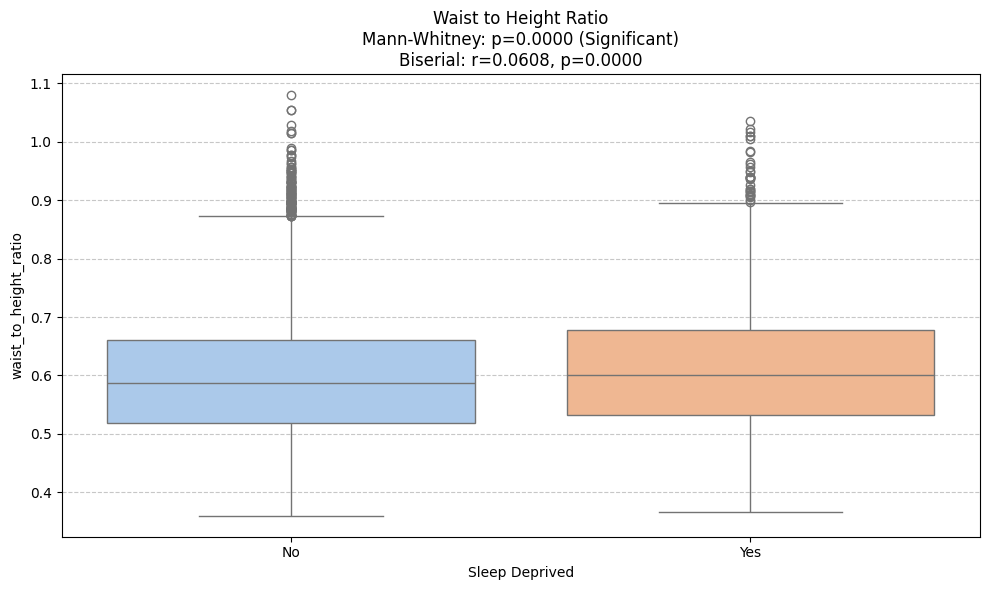


Statistical Summary:
Variable: waist_to_height_ratio
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min  25%  75%  Max
            No  11683  0.59    0.59     0.10 0.36 0.52 0.66 1.13
           Yes   3335  0.61    0.60     0.11 0.37 0.53 0.68 1.03
------------------------------------------------------------
Mann-Whitney U test results: U=17865360.5, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


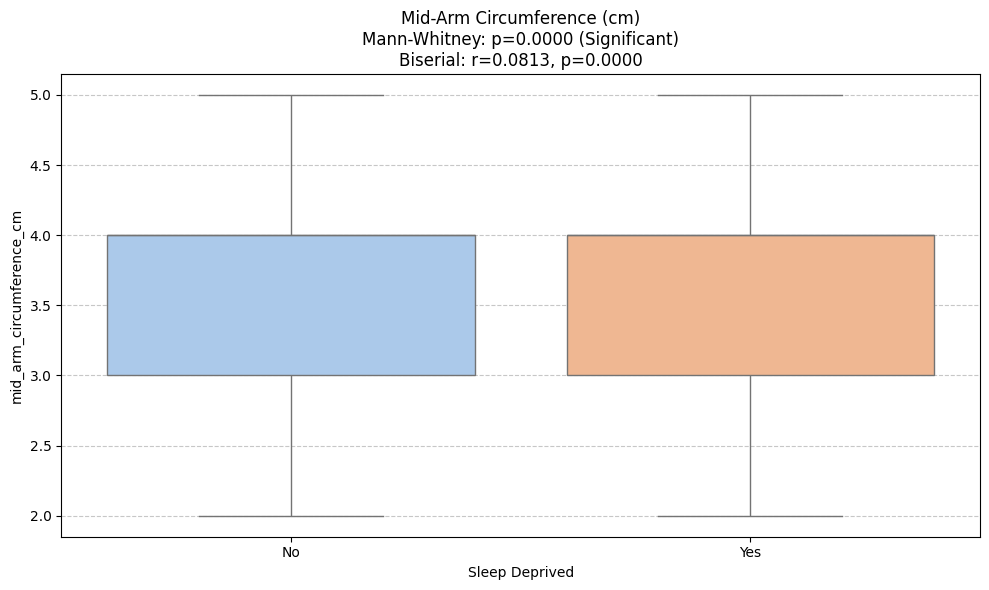


Statistical Summary:
Variable: mid_arm_circumference_cm
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev  Min  25%  75%  Max
            No  11468  3.62    4.00     0.61 2.00 3.00 4.00 5.00
           Yes   3295  3.74    4.00     0.63 2.00 3.00 4.00 5.00
------------------------------------------------------------
Mann-Whitney U test results: U=17046363.5, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


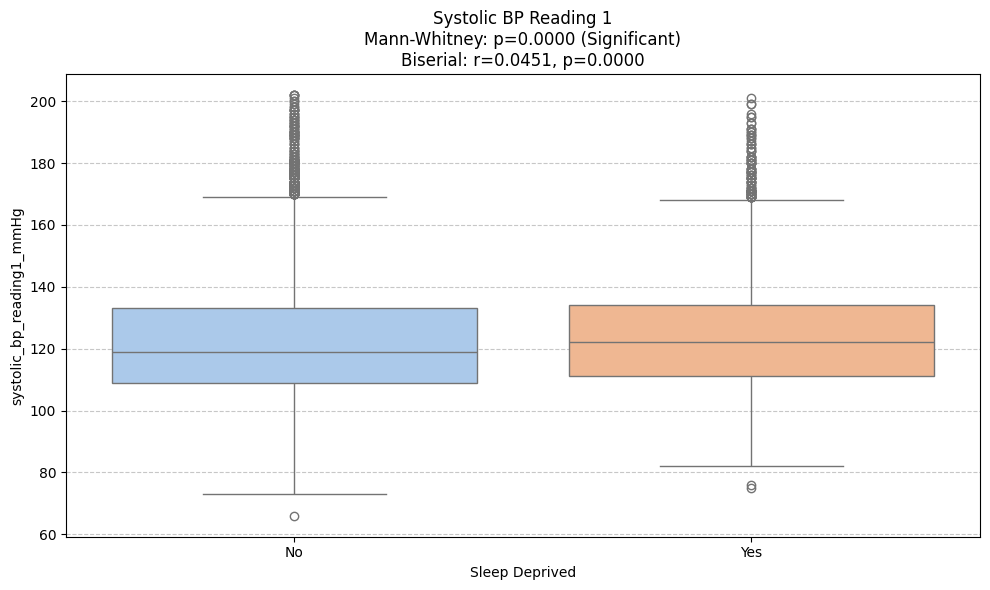


Statistical Summary:
Variable: systolic_bp_reading1_mmHg
------------------------------------------------------------
Sleep Deprived  Count   Mean  Median  Std Dev   Min    25%    75%    Max
            No  11407 122.46  119.00    19.02 66.00 109.00 133.00 225.00
           Yes   3278 124.53  122.00    19.29 75.00 111.00 135.00 225.00
------------------------------------------------------------
Mann-Whitney U test results: U=17445857.5, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


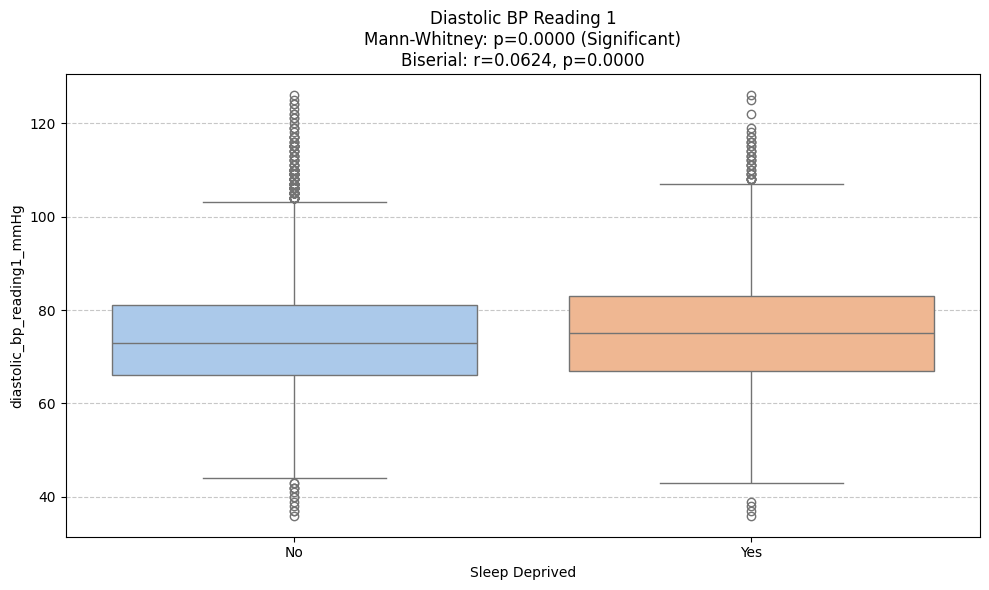


Statistical Summary:
Variable: diastolic_bp_reading1_mmHg
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev   Min   25%   75%    Max
            No  11407 74.05   73.00    11.56 36.00 66.00 81.00 141.00
           Yes   3278 75.80   75.00    12.00 36.00 67.00 83.00 142.00
------------------------------------------------------------
Mann-Whitney U test results: U=17097377.5, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


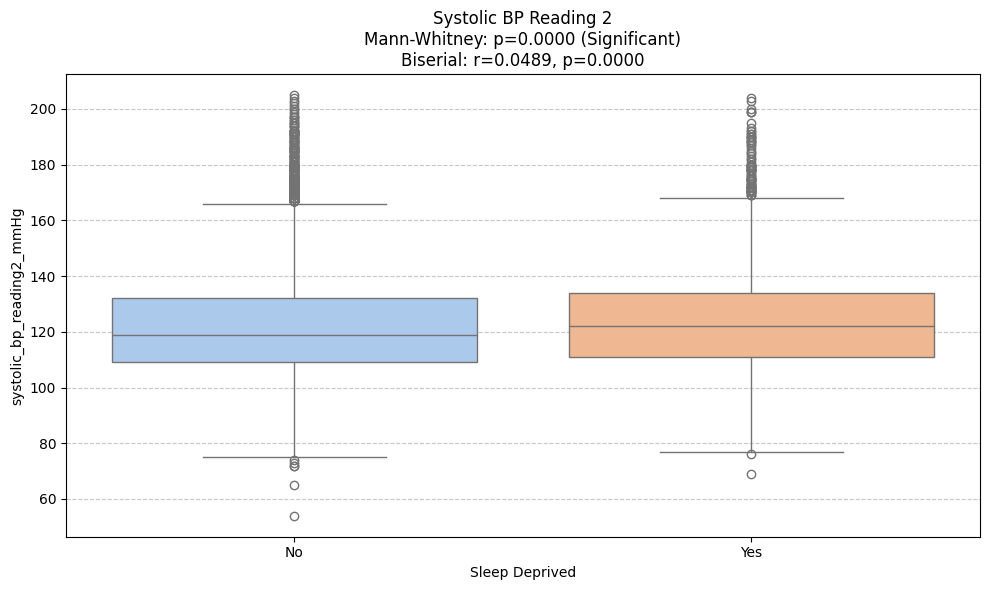


Statistical Summary:
Variable: systolic_bp_reading2_mmHg
------------------------------------------------------------
Sleep Deprived  Count   Mean  Median  Std Dev   Min    25%    75%    Max
            No  11394 122.19  119.00    18.88 54.00 109.00 132.00 222.00
           Yes   3274 124.41  122.00    19.14 69.00 111.00 134.00 218.00
------------------------------------------------------------
Mann-Whitney U test results: U=17294259.5, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


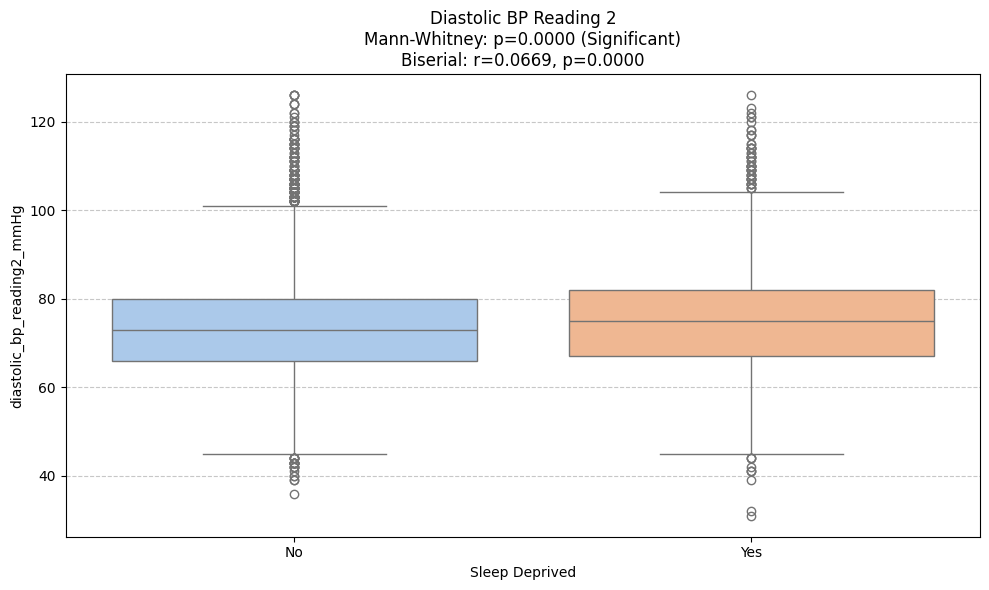


Statistical Summary:
Variable: diastolic_bp_reading2_mmHg
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev   Min   25%   75%    Max
            No  11394 73.43   73.00    11.47 36.00 66.00 80.00 146.00
           Yes   3274 75.30   75.00    12.04 31.00 67.00 82.00 139.00
------------------------------------------------------------
Mann-Whitney U test results: U=16901005.0, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


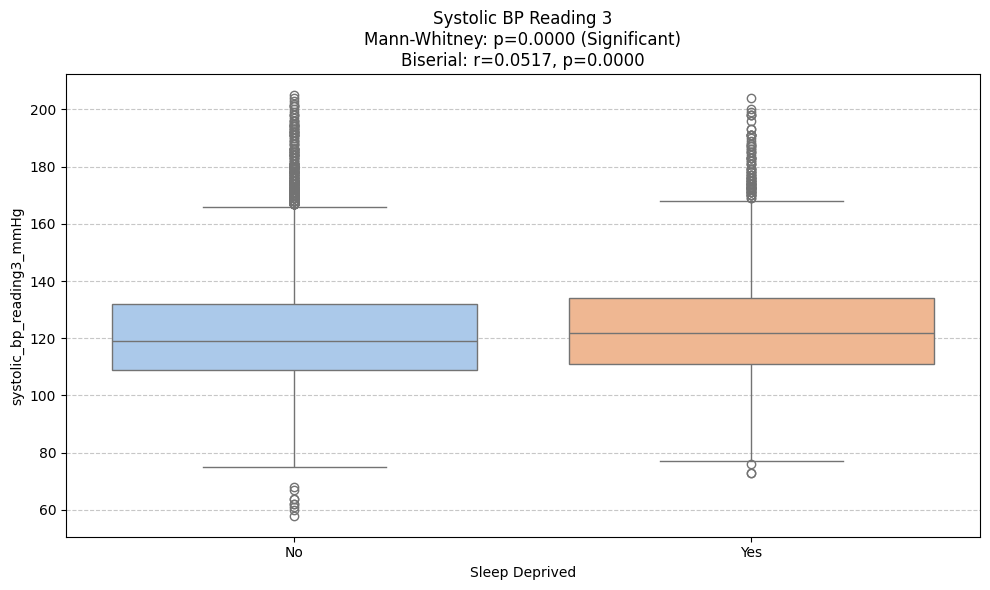


Statistical Summary:
Variable: systolic_bp_reading3_mmHg
------------------------------------------------------------
Sleep Deprived  Count   Mean  Median  Std Dev   Min    25%    75%    Max
            No  11367 122.03  119.00    18.70 58.00 109.00 132.00 224.00
           Yes   3264 124.37  122.00    19.20 73.00 111.00 134.00 220.00
------------------------------------------------------------
Mann-Whitney U test results: U=17182245.5, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


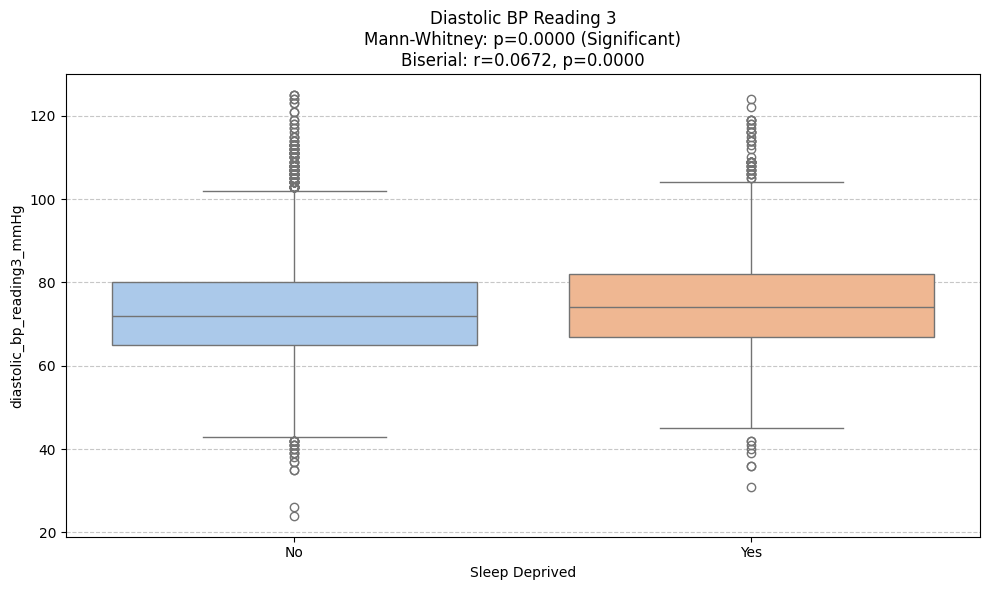


Statistical Summary:
Variable: diastolic_bp_reading3_mmHg
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev   Min   25%   75%    Max
            No  11367 73.11   72.00    11.52 24.00 65.00 80.00 145.00
           Yes   3264 74.99   74.00    11.89 31.00 67.00 82.00 136.00
------------------------------------------------------------
Mann-Whitney U test results: U=16776667.0, p-value=0.0000
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


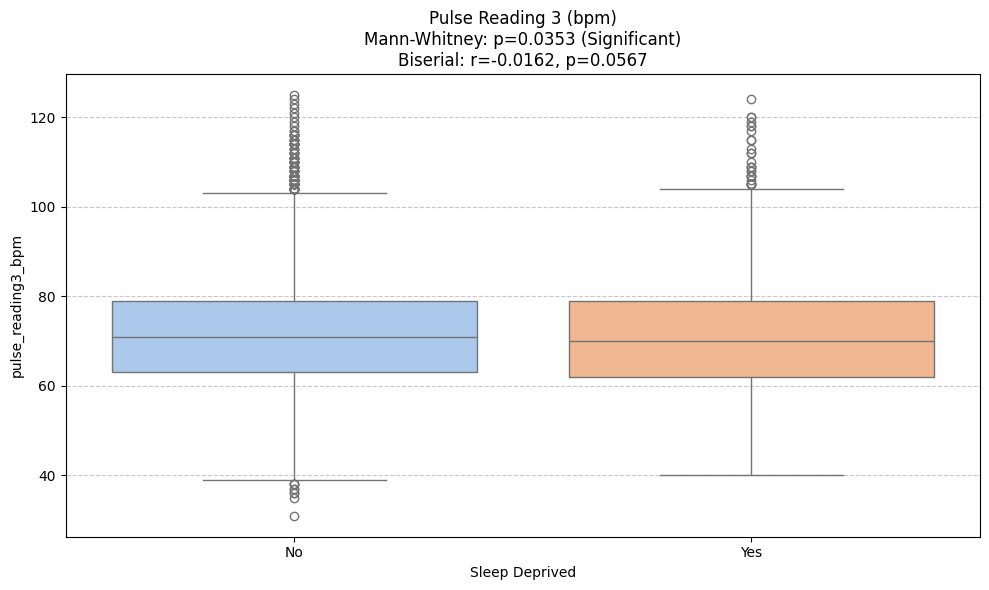


Statistical Summary:
Variable: pulse_reading3_bpm
------------------------------------------------------------
Sleep Deprived  Count  Mean  Median  Std Dev   Min   25%   75%    Max
            No  10806 71.59   71.00    12.20 31.00 63.00 79.00 147.00
           Yes   3088 71.12   70.00    12.12 40.00 62.00 79.00 124.00
------------------------------------------------------------
Mann-Whitney U test results: U=17098011.0, p-value=0.0353
The difference between sleep-deprived and non-sleep-deprived groups is statistically significant (p<0.05).
------------------------------------------------------------


In [49]:
# Body Measurements dataset
create_boxplot(df_bmx, 'weight_kg', dataset_cat="Weight (kg)")
create_boxplot(df_bmx, 'standing_height_cm', dataset_cat="Standing Height (cm)")
create_boxplot(df_bmx, 'body_mass_index', dataset_cat="Body Mass Index")
create_boxplot(df_bmx, 'upper_leg_length_cm', dataset_cat="Upper Leg Length (cm)")
create_boxplot(df_bmx, 'upper_arm_length_cm', dataset_cat="Upper Arm Length (cm)")
create_boxplot(df_bmx, 'arm_circumference_cm', dataset_cat="Arm Circumference (cm)")
create_boxplot(df_bmx, 'waist_circumference_cm', dataset_cat="Waist Circumference (cm)")
create_boxplot(df_bmx, 'hip_circumference_cm', dataset_cat="Hip Circumference (cm)")
create_boxplot(df_bmx, 'waist_to_height_ratio', dataset_cat="Waist to Height Ratio")

# Blood Pressure dataset
create_boxplot(df_bpxo, 'mid_arm_circumference_cm', dataset_cat="Mid-Arm Circumference (cm)")
create_boxplot(df_bpxo, 'systolic_bp_reading1_mmHg', dataset_cat="Systolic BP Reading 1")
create_boxplot(df_bpxo, 'diastolic_bp_reading1_mmHg', dataset_cat="Diastolic BP Reading 1")
create_boxplot(df_bpxo, 'systolic_bp_reading2_mmHg', dataset_cat="Systolic BP Reading 2")
create_boxplot(df_bpxo, 'diastolic_bp_reading2_mmHg', dataset_cat="Diastolic BP Reading 2")
create_boxplot(df_bpxo, 'systolic_bp_reading3_mmHg', dataset_cat="Systolic BP Reading 3")
create_boxplot(df_bpxo, 'diastolic_bp_reading3_mmHg', dataset_cat="Diastolic BP Reading 3")
create_boxplot(df_bpxo, 'pulse_reading3_bpm', dataset_cat="Pulse Reading 3 (bpm)")

### Stacked Bar Chart

#### Demographics

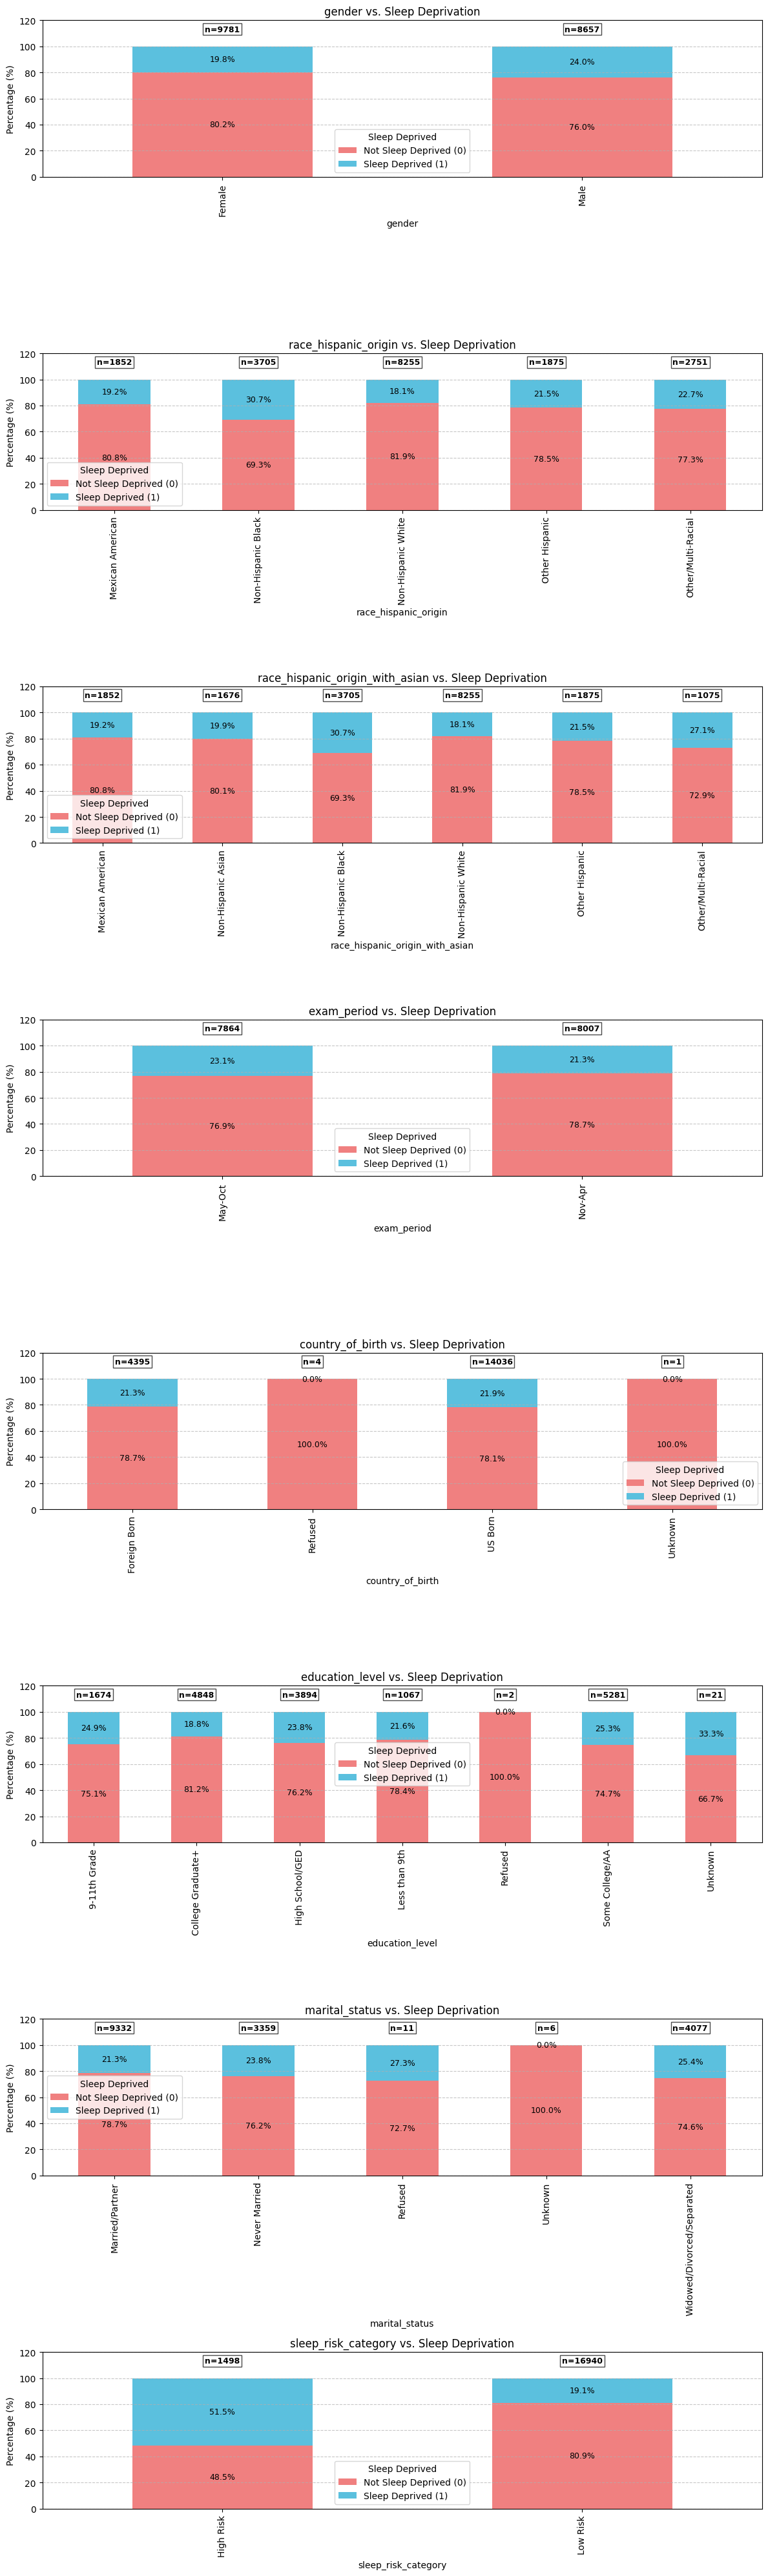

In [50]:
# Categorical variables
categorical_cols = [
    'gender',
    'race_hispanic_origin',
    'race_hispanic_origin_with_asian',
    'exam_period',
    'country_of_birth',
    'education_level',
    'marital_status',
    'sleep_risk_category'
]

# Create subplots for each categorical variable
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, 5*len(categorical_cols)))

# Plot each categorical variable
for i, cat_col in enumerate(categorical_cols):
    cross_tab = pd.crosstab(
        df_demo_cat[cat_col], 
        df_demo_cat['is_sleep_deprived'],
        normalize='index'
    ) * 100

    # Get counts
    count_tab = pd.crosstab(
        df_demo_cat[cat_col], 
        df_demo_cat['is_sleep_deprived']
    )
    count_tab['total'] = count_tab.sum(axis=1)

    cross_tab.plot(
        kind='bar', 
        stacked=True,
        ax=axes[i],
        color=['#f08080', '#5bc0de']
    )

    # Increase y-limit to make more room
    axes[i].set_ylim(0, 120)

    # Better positioned labels with background box
    for j, category in enumerate(count_tab.index):
        total = count_tab.loc[category, 'total']
        axes[i].text(j, 110, f'n={total}', 
                    ha='center', 
                    va='bottom',
                    fontsize=9, 
                    fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.7, pad=2))
        
        # Add percentage labels inside the bars
        not_deprived_pct = cross_tab.loc[category, 0]
        deprived_pct = cross_tab.loc[category, 1]
        
        # Position for not sleep deprived (bottom bar)
        axes[i].text(j, not_deprived_pct/2, 
                    f'{not_deprived_pct:.1f}%', 
                    ha='center', 
                    va='center',
                    fontsize=9,
                    color='black')
        
        # Position for sleep deprived (top bar)
        axes[i].text(j, not_deprived_pct + deprived_pct/2, 
                    f'{deprived_pct:.1f}%', 
                    ha='center', 
                    va='center',
                    fontsize=9,
                    color='black')

    axes[i].set_title(f'{cat_col} vs. Sleep Deprivation')
    axes[i].set_xlabel(cat_col)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(title='Sleep Deprived', labels=['Not Sleep Deprived (0)', 'Sleep Deprived (1)'])
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

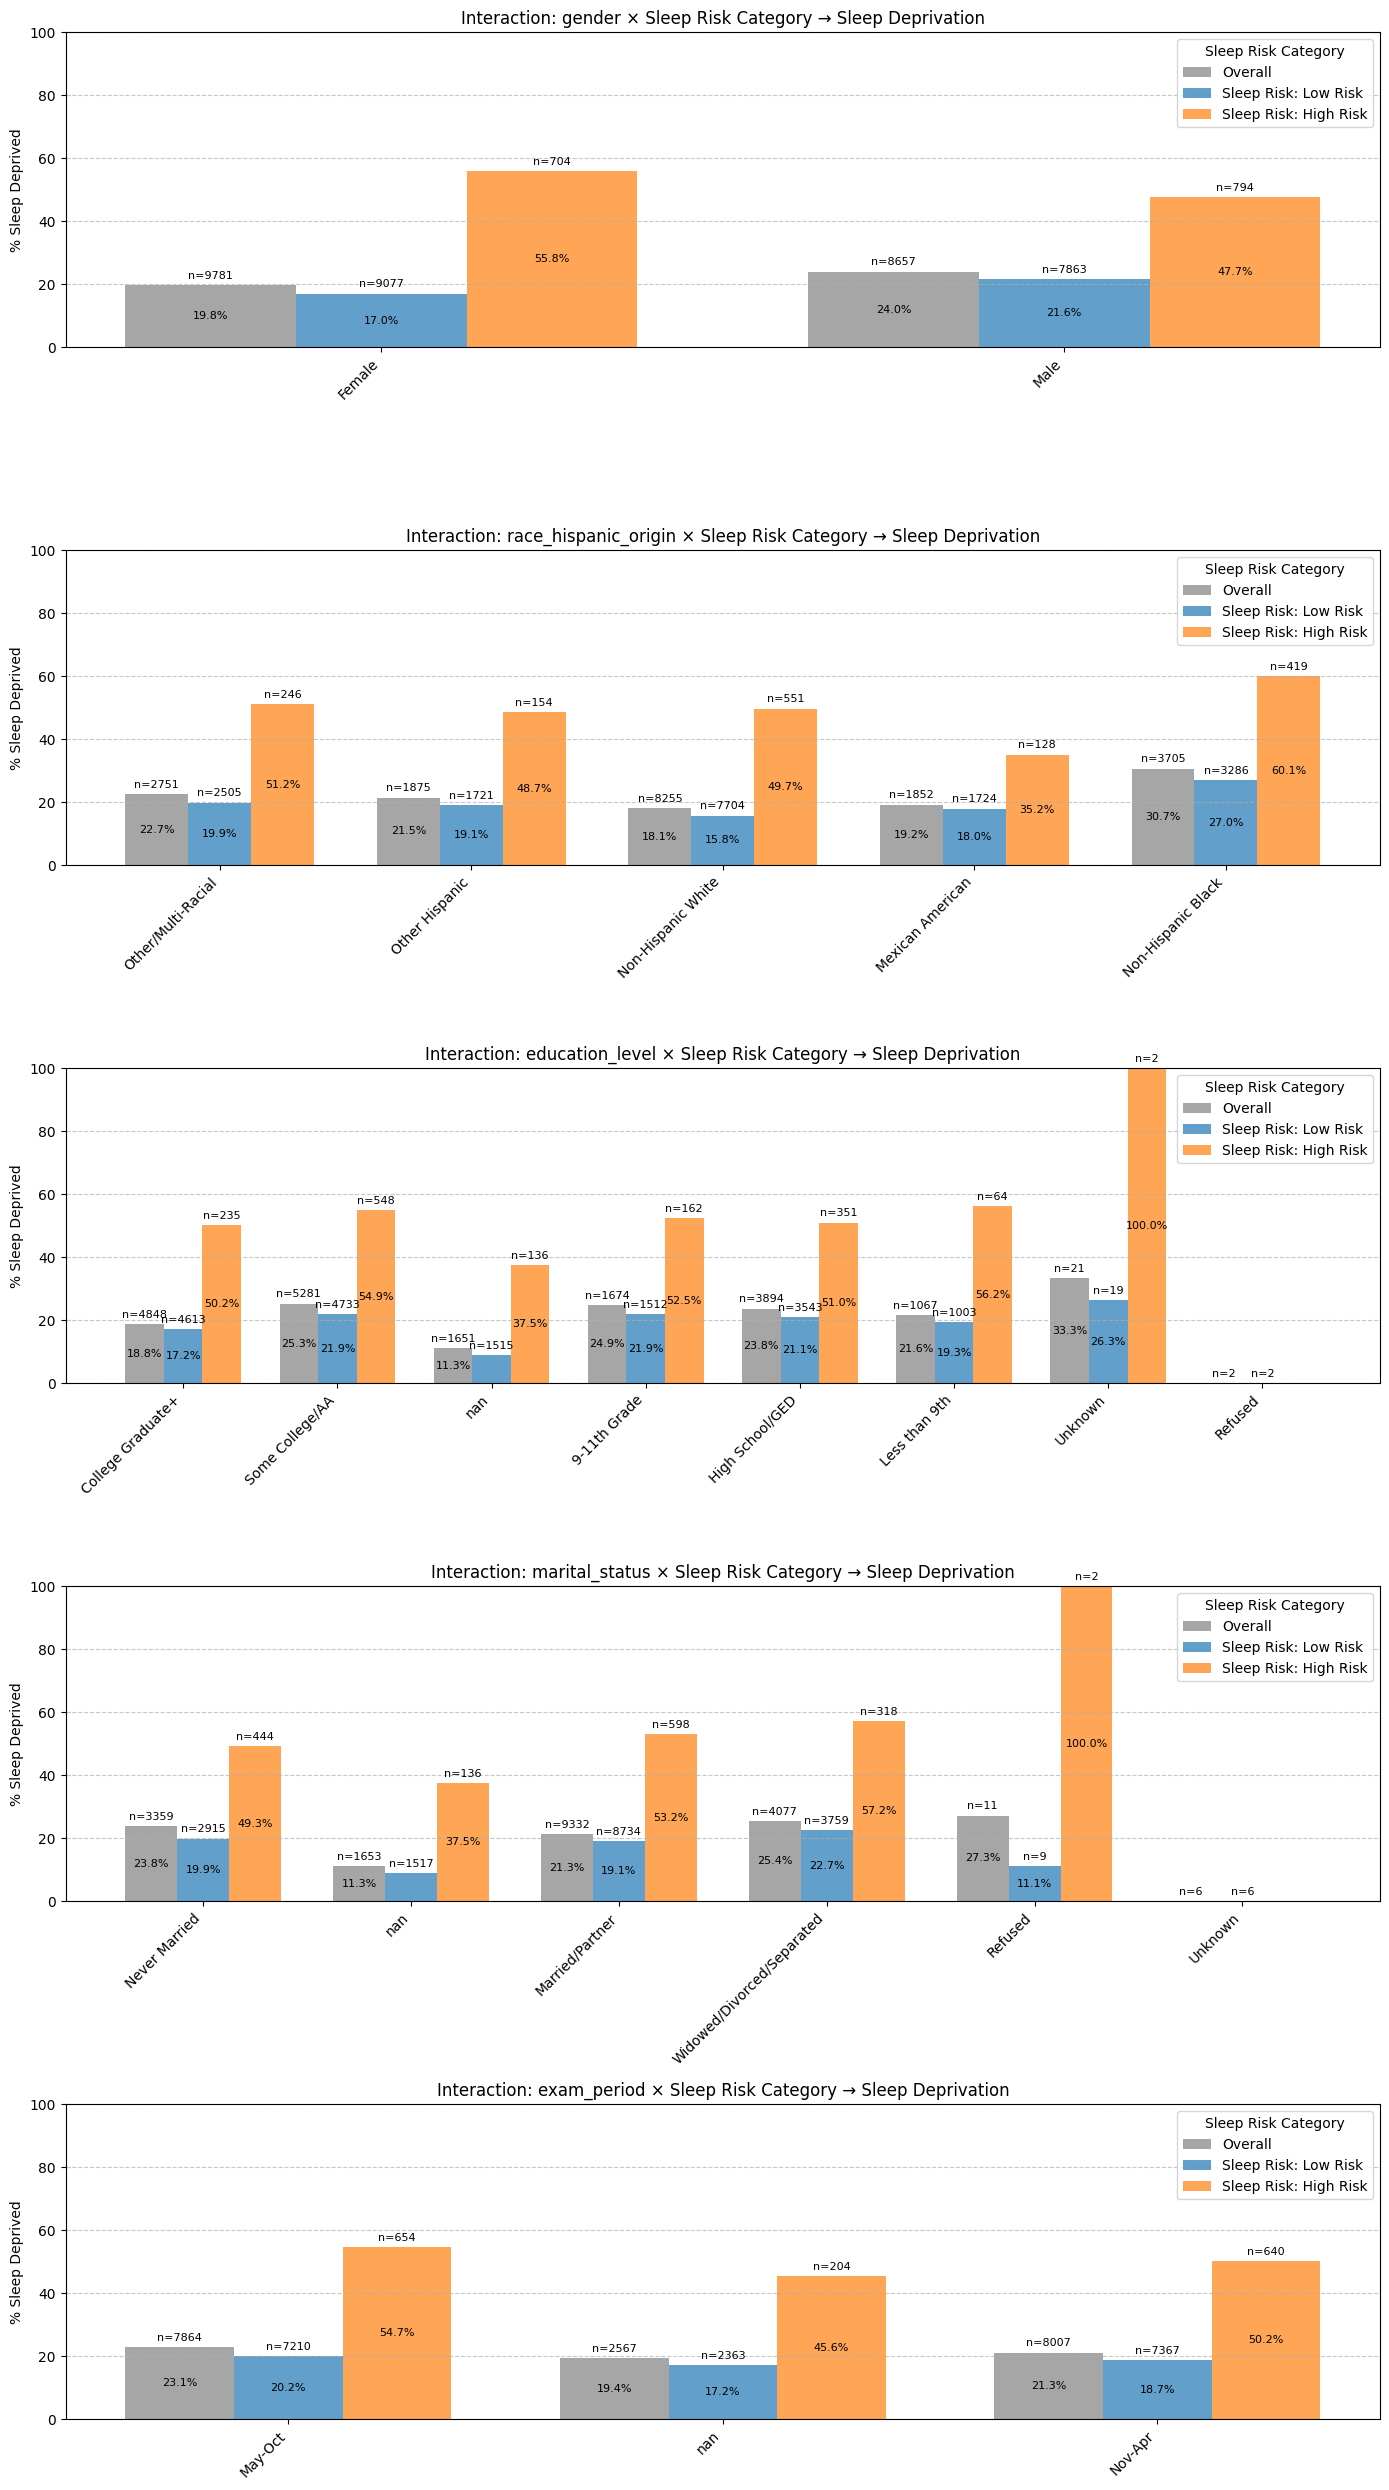

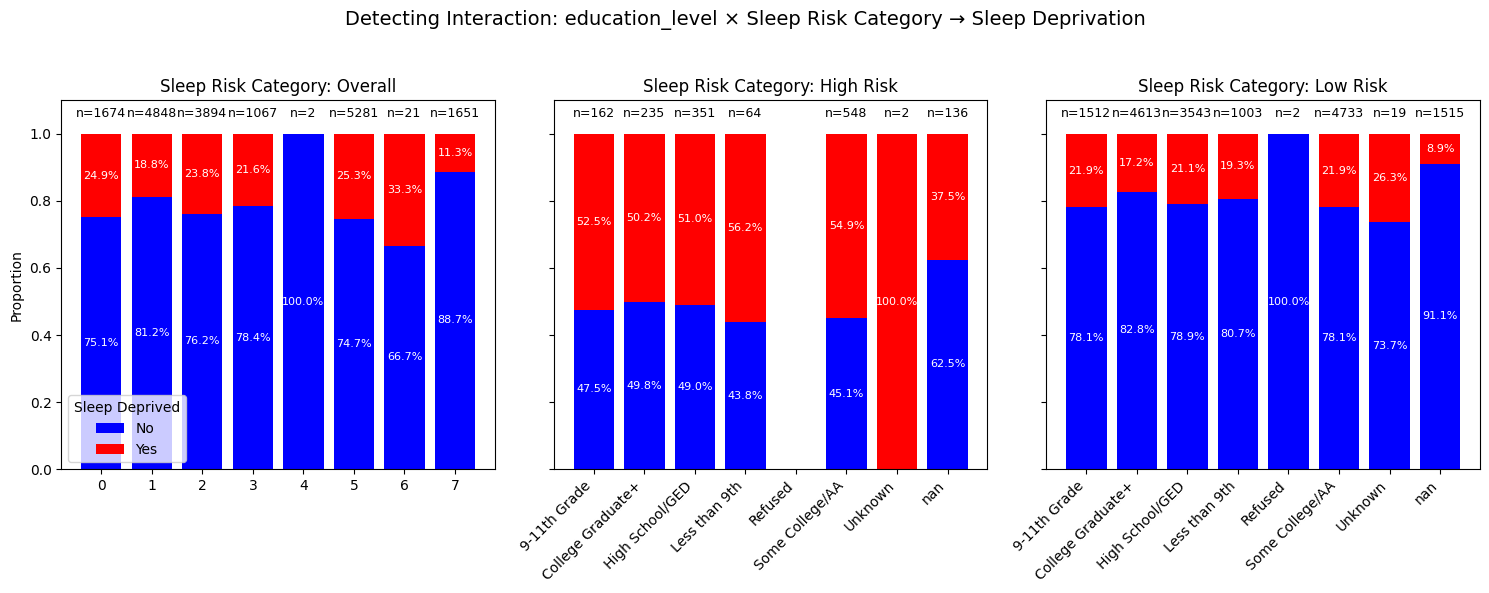

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Variables to check for interaction with sleep_risk_category
interaction_vars = [
    'gender',
    'race_hispanic_origin',
    'education_level',
    'marital_status',
    'exam_period'
]

# Function to safely compare categorical values by converting to strings first
def create_mask(df, col1, val1, col2=None, val2=None):
    if col2 is not None and val2 is not None:
        return (df[col1].astype(str) == str(val1)) & (df[col2].astype(str) == str(val2))
    else:
        return df[col1].astype(str) == str(val1)

# Plot 1: Bar charts showing interaction effects
fig, axes = plt.subplots(len(interaction_vars), 1, figsize=(14, 5*len(interaction_vars)))

for i, var in enumerate(interaction_vars):
    ax = axes[i]
    
    # Convert all values to strings to avoid comparison issues
    var_values = df_demo_cat[var].astype(str).unique()
    risk_values = df_demo_cat['sleep_risk_category'].astype(str).unique()
    
    # Set up the plot
    x = np.arange(len(var_values))  # positions for categories
    width = 0.25  # width of bars (adjusted for 3 categories)
    
    # Set colors for consistent appearance
    colors = {'Overall': 'gray', 'Low Risk': 'tab:blue', 'High Risk': 'tab:orange'}
    
    # First, plot the overall data (not filtered by risk category)
    overall_pcts = []
    overall_counts = []
    
    for cat in var_values:
        # Create mask for just this demographic category
        mask = create_mask(df_demo_cat, var, cat)
        subset = df_demo_cat[mask]
        
        if len(subset) > 0:
            # Calculate percentage of sleep deprived overall
            sleep_dep_pct = (subset['is_sleep_deprived'] == 1).mean() * 100
            overall_pcts.append(sleep_dep_pct)
            overall_counts.append(len(subset))
        else:
            overall_pcts.append(0)
            overall_counts.append(0)
    
    # Position bars for overall
    positions = x - width
    
    # Plot overall bars
    bars = ax.bar(positions, overall_pcts, width, 
                  label='Overall',
                  color=colors['Overall'],
                  alpha=0.7)
    
    # Add count labels for overall
    for k, (pos, count) in enumerate(zip(positions, overall_counts)):
        if count > 0:
            ax.text(pos, overall_pcts[k] + 2, f'n={count}', 
                    ha='center', fontsize=8)
            
            # Add percentage inside bars if high enough
            if overall_pcts[k] > 10:
                ax.text(pos, overall_pcts[k]/2, 
                        f'{overall_pcts[k]:.1f}%', 
                        ha='center', va='center',
                        fontsize=8, color='black')
    
    # Now plot each sleep risk category
    positions_map = {'Low Risk': 0, 'High Risk': width}
    
    for risk in risk_values:
        risk_label = 'Low Risk' if risk == 'Low Risk' else 'High Risk'
        sleep_dep_pcts = []
        counts = []
        
        for cat in var_values:
            # Create mask for this combination
            mask = create_mask(df_demo_cat, var, cat, 'sleep_risk_category', risk)
            subset = df_demo_cat[mask]
            
            if len(subset) > 0:
                # Calculate percentage of sleep deprived
                sleep_dep_pct = (subset['is_sleep_deprived'] == 1).mean() * 100
                sleep_dep_pcts.append(sleep_dep_pct)
                counts.append(len(subset))
            else:
                sleep_dep_pcts.append(0)
                counts.append(0)
        
        # Position bars
        positions = x + positions_map[risk_label]
        
        # Plot bars
        bars = ax.bar(positions, sleep_dep_pcts, width, 
                      label=f'Sleep Risk: {risk_label}',
                      color=colors[risk_label],
                      alpha=0.7)
        
        # Add count labels
        for k, (pos, count) in enumerate(zip(positions, counts)):
            if count > 0:
                ax.text(pos, sleep_dep_pcts[k] + 2, f'n={count}', 
                        ha='center', fontsize=8)
                
                # Add percentage inside bars if high enough
                if sleep_dep_pcts[k] > 10:
                    ax.text(pos, sleep_dep_pcts[k]/2, 
                            f'{sleep_dep_pcts[k]:.1f}%', 
                            ha='center', va='center',
                            fontsize=8, color='black')
    
    # Customize plot
    ax.set_title(f'Interaction: {var} × Sleep Risk Category → Sleep Deprivation')
    ax.set_xticks(x)
    ax.set_xticklabels(var_values, rotation=45, ha='right')
    ax.set_ylabel('% Sleep Deprived')
    ax.set_ylim(0, 100)
    ax.legend(title='Sleep Risk Category')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Plot 2: Faceted plots with an added "Overall" category
demo_var = 'education_level'

# Get the unique values as strings
risk_values = sorted(df_demo_cat['sleep_risk_category'].astype(str).unique())
var_values = sorted(df_demo_cat[demo_var].astype(str).unique())

# Create a figure with one subplot per sleep risk category + overall
fig2, axes2 = plt.subplots(1, len(risk_values) + 1, 
                          figsize=(5*(len(risk_values) + 1), 6),
                          sharey=True)

# Colors for sleep deprived status
colors = {'No': 'blue', 'Yes': 'red'}

# First plot overall (not filtered by risk)
ax = axes2[0]
ax.set_title('Sleep Risk Category: Overall')

# For each category of the demo variable
for j, cat in enumerate(var_values):
    # Get data for this demographic
    mask = create_mask(df_demo_cat, demo_var, cat)
    subset = df_demo_cat[mask]
    
    if len(subset) > 0:
        # Calculate proportions
        prop_yes = (subset['is_sleep_deprived'] == 1).mean()
        prop_no = 1 - prop_yes
        
        # Plot stacked bars
        ax.bar(j, prop_no, color=colors['No'], label='No' if j == 0 else "")
        ax.bar(j, prop_yes, bottom=prop_no, color=colors['Yes'], label='Yes' if j == 0 else "")
        
        # Add count label
        ax.text(j, 1.05, f'n={len(subset)}', ha='center', fontsize=9)
        
        # Add percentage labels if bars are big enough
        if prop_yes > 0.05:
            ax.text(j, prop_no + prop_yes/2, f'{prop_yes*100:.1f}%', 
                   ha='center', va='center', fontsize=8, color='white')
        
        if prop_no > 0.05:
            ax.text(j, prop_no/2, f'{prop_no*100:.1f}%', 
                   ha='center', va='center', fontsize=8, color='white')

# Now, for each sleep risk category
for i, risk in enumerate(risk_values):
    ax = axes2[i + 1]  # Offset by 1 because "Overall" is first
    
    # For each category of the demo variable
    for j, cat in enumerate(var_values):
        # Get data for this combination
        mask = create_mask(df_demo_cat, demo_var, cat, 'sleep_risk_category', risk)
        subset = df_demo_cat[mask]
        
        if len(subset) > 0:
            # Calculate proportions
            prop_yes = (subset['is_sleep_deprived'] == 1).mean()
            prop_no = 1 - prop_yes
            
            # Plot stacked bars
            ax.bar(j, prop_no, color=colors['No'], label='No' if j == 0 else "")
            ax.bar(j, prop_yes, bottom=prop_no, color=colors['Yes'], label='Yes' if j == 0 else "")
            
            # Add count label
            ax.text(j, 1.05, f'n={len(subset)}', ha='center', fontsize=9)
            
            # Add percentage labels if bars are big enough
            if prop_yes > 0.05:
                ax.text(j, prop_no + prop_yes/2, f'{prop_yes*100:.1f}%', 
                       ha='center', va='center', fontsize=8, color='white')
            
            if prop_no > 0.05:
                ax.text(j, prop_no/2, f'{prop_no*100:.1f}%', 
                       ha='center', va='center', fontsize=8, color='white')
    
    # Customize subplot
    ax.set_title(f'Sleep Risk Category: {risk}')
    ax.set_xticks(range(len(var_values)))
    ax.set_xticklabels(var_values, rotation=45, ha='right')
    ax.set_ylim(0, 1.1)
    
# Set y-label only for the first subplot
axes2[0].set_ylabel('Proportion')
axes2[0].legend(title='Sleep Deprived')

# Add a main title
plt.suptitle(f'Detecting Interaction: {demo_var} × Sleep Risk Category → Sleep Deprivation', 
             fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

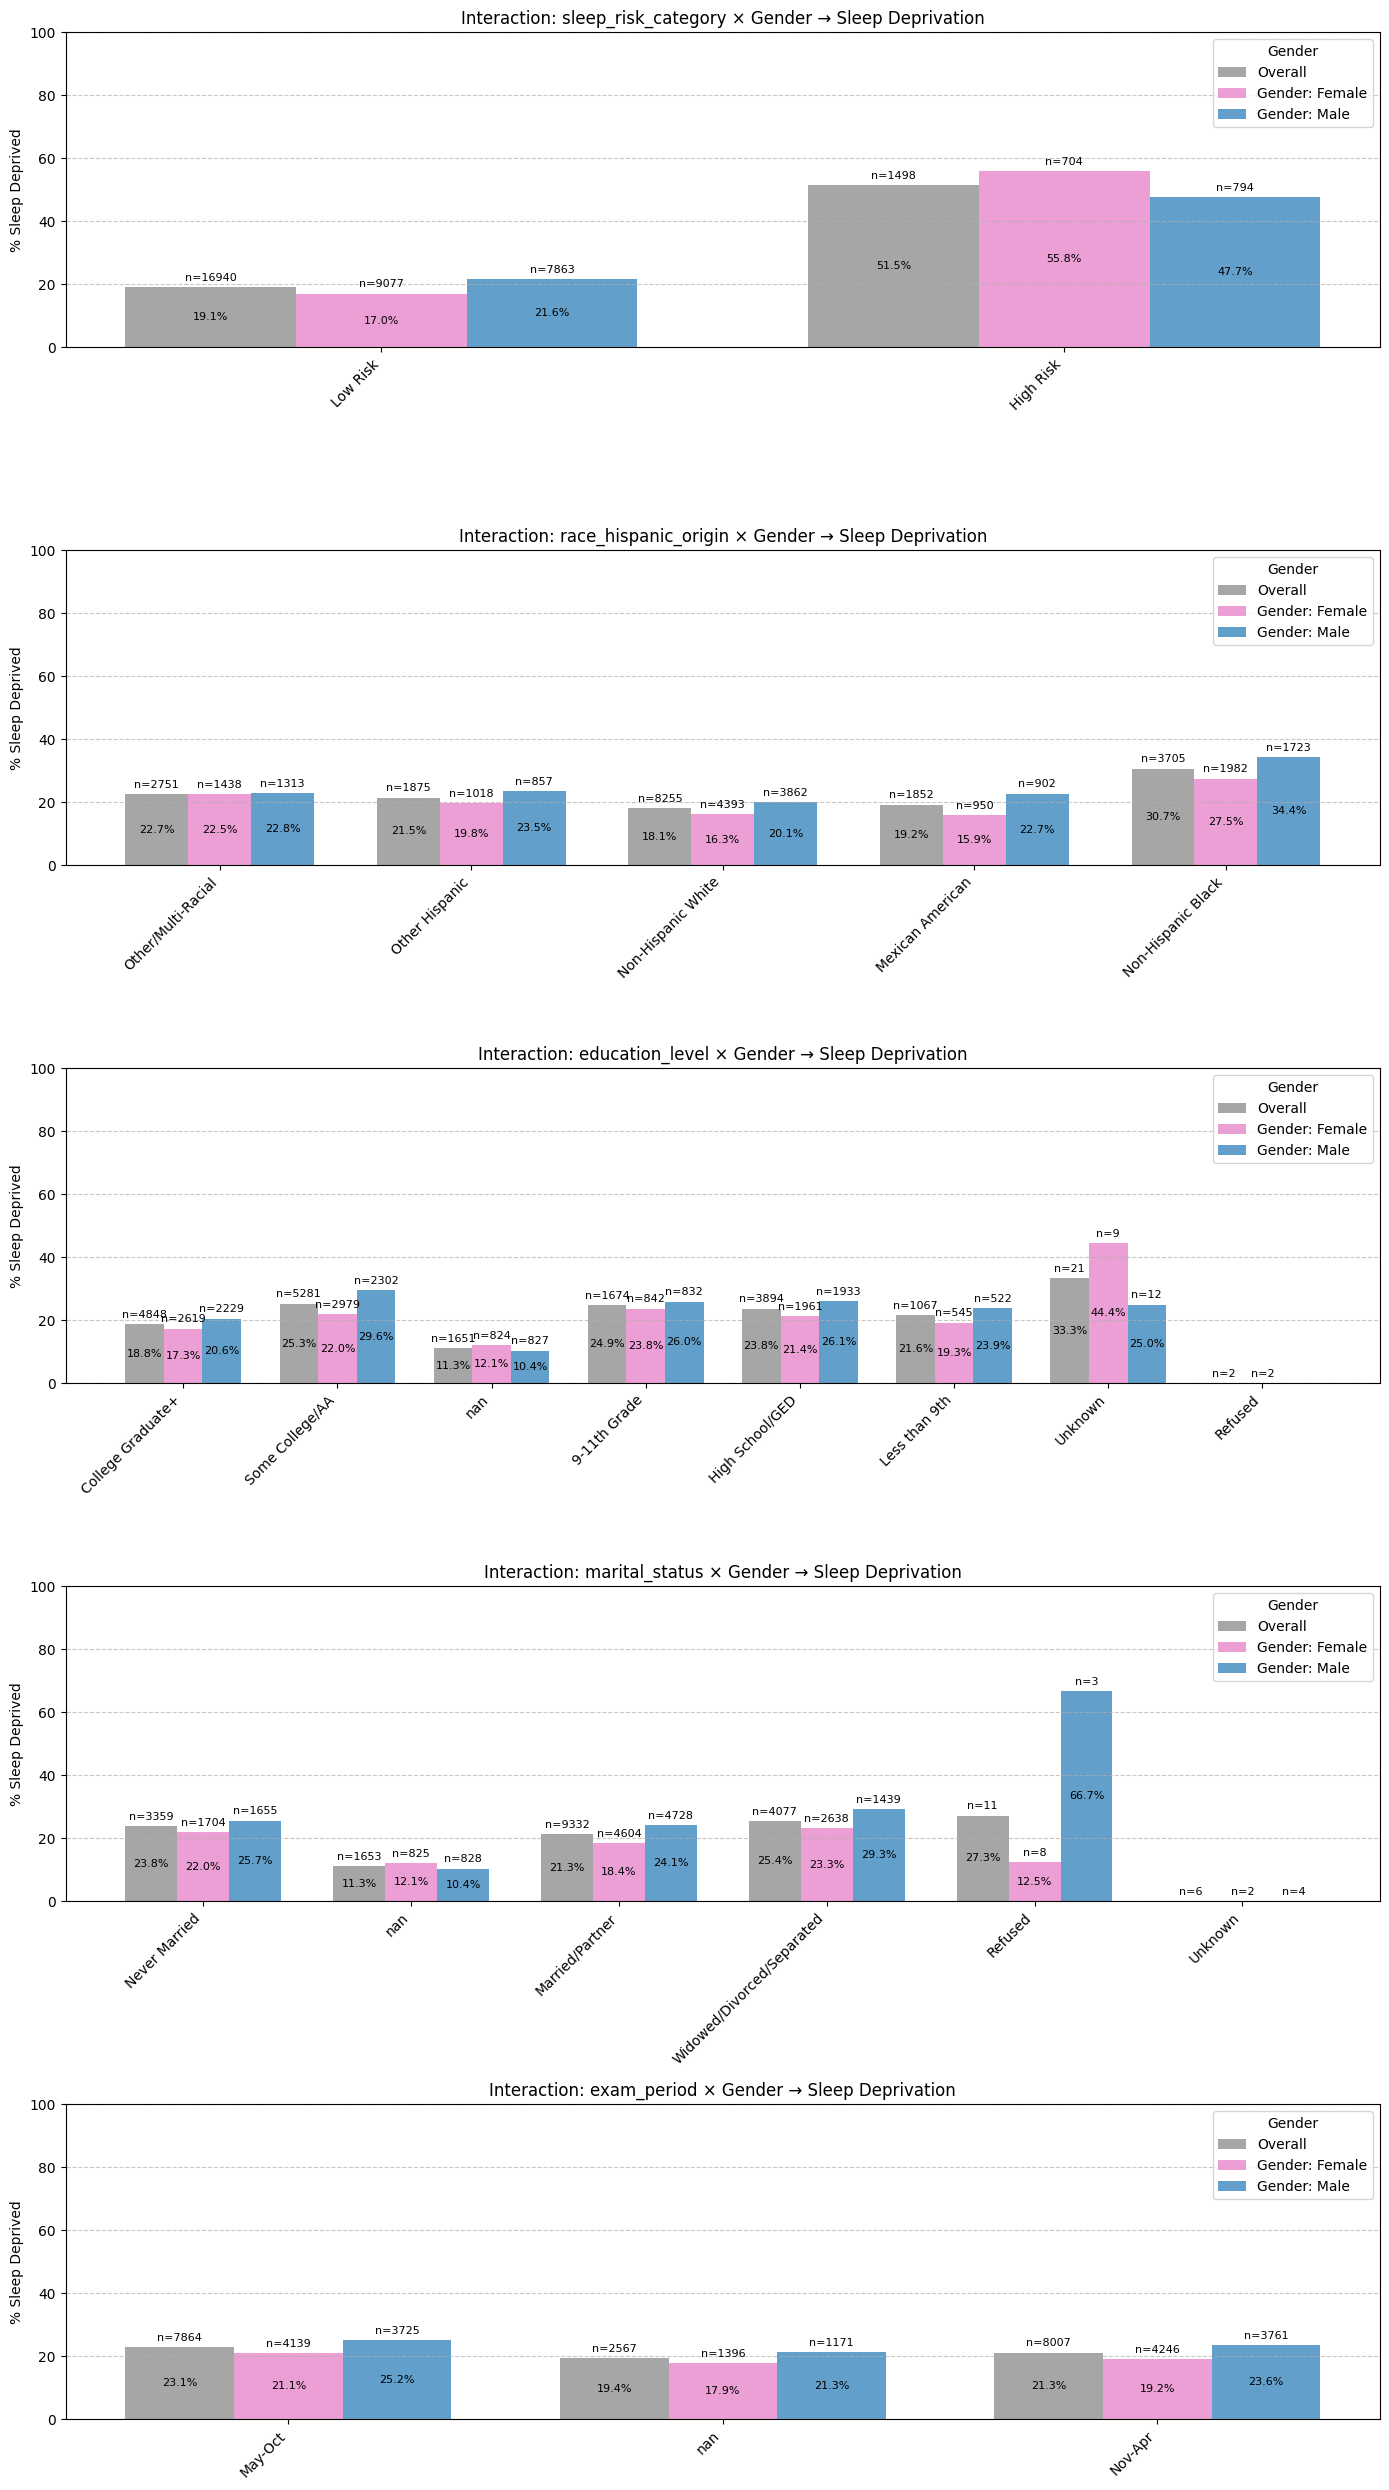

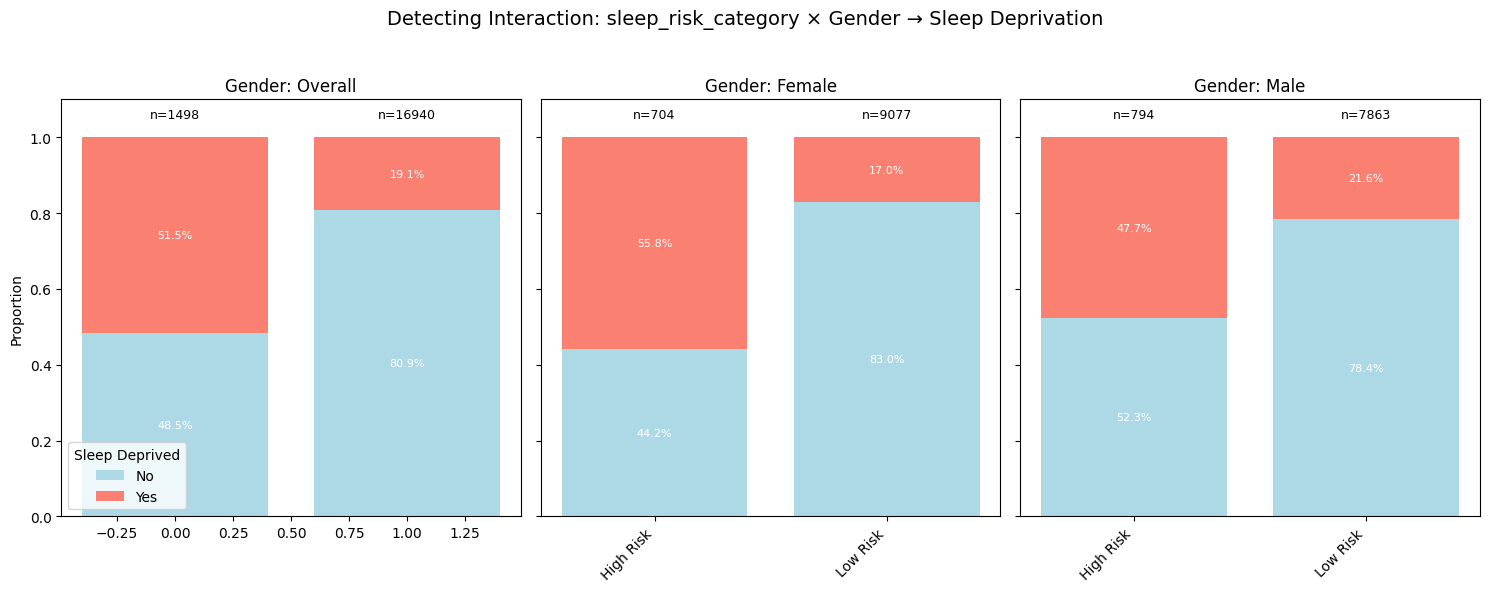

In [52]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Variables to check for interaction with gender
interaction_vars = [
    'sleep_risk_category',
    'race_hispanic_origin',
    'education_level',
    'marital_status',
    'exam_period'
]

# Function to safely compare categorical values by converting to strings first
def create_mask(df, col1, val1, col2=None, val2=None):
    if col2 is not None and val2 is not None:
        return (df[col1].astype(str) == str(val1)) & (df[col2].astype(str) == str(val2))
    else:
        return df[col1].astype(str) == str(val1)

# Plot 1: Bar charts showing interaction effects
fig, axes = plt.subplots(len(interaction_vars), 1, figsize=(14, 5*len(interaction_vars)))

for i, var in enumerate(interaction_vars):
    ax = axes[i]
    
    # Convert all values to strings to avoid comparison issues
    var_values = df_demo_cat[var].astype(str).unique()
    gender_values = df_demo_cat['gender'].astype(str).unique()
    
    # Set up the plot
    x = np.arange(len(var_values))  # positions for categories
    width = 0.25  # width of bars (adjusted for 3 categories)
    
    # Set colors for consistent appearance
    colors = {'Overall': 'gray', 'Female': 'tab:pink', 'Male': 'tab:blue'}
    
    # First, plot the overall data (not filtered by gender)
    overall_pcts = []
    overall_counts = []
    
    for cat in var_values:
        # Create mask for just this demographic category
        mask = create_mask(df_demo_cat, var, cat)
        subset = df_demo_cat[mask]
        
        if len(subset) > 0:
            # Calculate percentage of sleep deprived overall
            sleep_dep_pct = (subset['is_sleep_deprived'] == 1).mean() * 100
            overall_pcts.append(sleep_dep_pct)
            overall_counts.append(len(subset))
        else:
            overall_pcts.append(0)
            overall_counts.append(0)
    
    # Position bars for overall
    positions = x - width
    
    # Plot overall bars
    bars = ax.bar(positions, overall_pcts, width, 
                  label='Overall',
                  color=colors['Overall'],
                  alpha=0.7)
    
    # Add count labels for overall
    for k, (pos, count) in enumerate(zip(positions, overall_counts)):
        if count > 0:
            ax.text(pos, overall_pcts[k] + 2, f'n={count}', 
                    ha='center', fontsize=8)
            
            # Add percentage inside bars if high enough
            if overall_pcts[k] > 10:
                ax.text(pos, overall_pcts[k]/2, 
                        f'{overall_pcts[k]:.1f}%', 
                        ha='center', va='center',
                        fontsize=8, color='black')
    
    # Now plot each gender category
    positions_map = {'Female': 0, 'Male': width}
    
    for gender in gender_values:
        sleep_dep_pcts = []
        counts = []
        
        for cat in var_values:
            # Create mask for this combination
            mask = create_mask(df_demo_cat, var, cat, 'gender', gender)
            subset = df_demo_cat[mask]
            
            if len(subset) > 0:
                # Calculate percentage of sleep deprived
                sleep_dep_pct = (subset['is_sleep_deprived'] == 1).mean() * 100
                sleep_dep_pcts.append(sleep_dep_pct)
                counts.append(len(subset))
            else:
                sleep_dep_pcts.append(0)
                counts.append(0)
        
        # Position bars
        positions = x + positions_map[gender]
        
        # Plot bars
        bars = ax.bar(positions, sleep_dep_pcts, width, 
                      label=f'Gender: {gender}',
                      color=colors[gender],
                      alpha=0.7)
        
        # Add count labels
        for k, (pos, count) in enumerate(zip(positions, counts)):
            if count > 0:
                ax.text(pos, sleep_dep_pcts[k] + 2, f'n={count}', 
                        ha='center', fontsize=8)
                
                # Add percentage inside bars if high enough
                if sleep_dep_pcts[k] > 10:
                    ax.text(pos, sleep_dep_pcts[k]/2, 
                            f'{sleep_dep_pcts[k]:.1f}%', 
                            ha='center', va='center',
                            fontsize=8, color='black')
    
    # Customize plot
    ax.set_title(f'Interaction: {var} × Gender → Sleep Deprivation')
    ax.set_xticks(x)
    ax.set_xticklabels(var_values, rotation=45, ha='right')
    ax.set_ylabel('% Sleep Deprived')
    ax.set_ylim(0, 100)
    ax.legend(title='Gender')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Plot 2: Faceted plots with an added "Overall" category
demo_var = 'sleep_risk_category'  # Changed to sleep_risk_category for demo

# Get the unique values as strings
gender_values = sorted(df_demo_cat['gender'].astype(str).unique())
var_values = sorted(df_demo_cat[demo_var].astype(str).unique())

# Create a figure with one subplot per gender + overall
fig2, axes2 = plt.subplots(1, len(gender_values) + 1, 
                          figsize=(5*(len(gender_values) + 1), 6),
                          sharey=True)

# Colors for sleep deprived status
colors = {'No': 'lightblue', 'Yes': 'salmon'}

# First plot overall (not filtered by gender)
ax = axes2[0]
ax.set_title('Gender: Overall')

# For each category of the demo variable
for j, cat in enumerate(var_values):
    # Get data for this demographic
    mask = create_mask(df_demo_cat, demo_var, cat)
    subset = df_demo_cat[mask]
    
    if len(subset) > 0:
        # Calculate proportions
        prop_yes = (subset['is_sleep_deprived'] == 1).mean()
        prop_no = 1 - prop_yes
        
        # Plot stacked bars
        ax.bar(j, prop_no, color=colors['No'], label='No' if j == 0 else "")
        ax.bar(j, prop_yes, bottom=prop_no, color=colors['Yes'], label='Yes' if j == 0 else "")
        
        # Add count label
        ax.text(j, 1.05, f'n={len(subset)}', ha='center', fontsize=9)
        
        # Add percentage labels if bars are big enough
        if prop_yes > 0.05:
            ax.text(j, prop_no + prop_yes/2, f'{prop_yes*100:.1f}%', 
                   ha='center', va='center', fontsize=8, color='white')
        
        if prop_no > 0.05:
            ax.text(j, prop_no/2, f'{prop_no*100:.1f}%', 
                   ha='center', va='center', fontsize=8, color='white')

# Now, for each gender
for i, gender in enumerate(gender_values):
    ax = axes2[i + 1]  # Offset by 1 because "Overall" is first
    
    # For each category of the demo variable
    for j, cat in enumerate(var_values):
        # Get data for this combination
        mask = create_mask(df_demo_cat, demo_var, cat, 'gender', gender)
        subset = df_demo_cat[mask]
        
        if len(subset) > 0:
            # Calculate proportions
            prop_yes = (subset['is_sleep_deprived'] == 1).mean()
            prop_no = 1 - prop_yes
            
            # Plot stacked bars
            ax.bar(j, prop_no, color=colors['No'], label='No' if j == 0 else "")
            ax.bar(j, prop_yes, bottom=prop_no, color=colors['Yes'], label='Yes' if j == 0 else "")
            
            # Add count label
            ax.text(j, 1.05, f'n={len(subset)}', ha='center', fontsize=9)
            
            # Add percentage labels if bars are big enough
            if prop_yes > 0.05:
                ax.text(j, prop_no + prop_yes/2, f'{prop_yes*100:.1f}%', 
                       ha='center', va='center', fontsize=8, color='white')
            
            if prop_no > 0.05:
                ax.text(j, prop_no/2, f'{prop_no*100:.1f}%', 
                       ha='center', va='center', fontsize=8, color='white')
    
    # Customize subplot
    ax.set_title(f'Gender: {gender}')
    ax.set_xticks(range(len(var_values)))
    ax.set_xticklabels(var_values, rotation=45, ha='right')
    ax.set_ylim(0, 1.1)
    
# Set y-label only for the first subplot
axes2[0].set_ylabel('Proportion')
axes2[0].legend(title='Sleep Deprived')

# Add a main title
plt.suptitle(f'Detecting Interaction: {demo_var} × Gender → Sleep Deprivation', 
             fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [53]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

np.random.seed(42)

# Based on the available columns output, we only have categorical features
categorical_features = [
    'gender', 'race_hispanic_origin', 'exam_period', 
    'country_of_birth', 'education_level', 'marital_status', 
    'sleep_risk_category'
]

# Remove the target variable and ID from features
X = df_demo_cat.drop(['is_sleep_deprived', 'respondent_id', 'race_hispanic_origin_with_asian'], axis=1)
y = df_demo_cat['is_sleep_deprived']

print(f"Features being used: {X.columns.tolist()}")

# Create transformer for categorical data with median imputation
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the pipeline with random forest classifier
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train the model
rf_pipeline.fit(X_train, y_train)

# Evaluate the model
print("\nTraining accuracy:", rf_pipeline.score(X_train, y_train))
print("Test accuracy:", rf_pipeline.score(X_test, y_test))

# Get predictions
y_pred = rf_pipeline.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Cross-validation
cv_scores = cross_val_score(rf_pipeline, X, y, cv=5)
print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV score: {cv_scores.mean():.4f}")

# Feature importance
try:
    # Get feature names from the preprocessor
    feature_names = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
    
    importances = rf_pipeline.named_steps['classifier'].feature_importances_
    
    # Sort and display top features
    indices = np.argsort(importances)[::-1]
    print("\nTop 10 most important features:")
    for i in range(min(10, len(feature_names))):
        print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")
except Exception as e:
    print("\nCouldn't extract feature importances:", e)

Features being used: ['gender', 'race_hispanic_origin', 'exam_period', 'country_of_birth', 'education_level', 'marital_status', 'sleep_risk_category']

Training accuracy: 0.8021405843216662
Test accuracy: 0.7843817787418655

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.96      0.88      3640
           1       0.46      0.13      0.20       970

    accuracy                           0.78      4610
   macro avg       0.63      0.54      0.54      4610
weighted avg       0.73      0.78      0.73      4610


Cross-validation scores: [0.77630152 0.77657267 0.78497831 0.77895308 0.77976675]
Mean CV score: 0.7793

Top 10 most important features:
1. sleep_risk_category_Low Risk: 0.1347
2. sleep_risk_category_High Risk: 0.1188
3. race_hispanic_origin_Non-Hispanic Black: 0.0582
4. education_level_Some College/AA: 0.0506
5. education_level_High School/GED: 0.0463
6. education_level_College Graduate+: 0.0432
7. country_of_birth_US B

In [54]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

np.random.seed(42)

# Features to use
categorical_features = [
    'gender', 'race_hispanic_origin', 'exam_period', 
    'country_of_birth', 'education_level', 'marital_status',
    'sleep_risk_category'
]

# Prepare data
X = df_demo_cat.drop(['is_sleep_deprived', 'respondent_id', 'race_hispanic_origin_with_asian'], axis=1)
y = df_demo_cat['is_sleep_deprived']

print(f"Features being used: {X.columns.tolist()}")
print(f"Class distribution before balancing: {np.bincount(y)}")

# Create preprocessing pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Method 1: Class weights in RandomForest
rf_weighted = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100, 
        class_weight='balanced',  # This helps with imbalanced data
        random_state=42))
])

# Train the weighted model
rf_weighted.fit(X_train, y_train)
print("\n--- Results with Class Weights ---")
print("Training accuracy:", rf_weighted.score(X_train, y_train))
print("Test accuracy:", rf_weighted.score(X_test, y_test))
y_pred_weighted = rf_weighted.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred_weighted))

# Method 2: SMOTE oversampling
# First, preprocess the data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)
print(f"Class distribution after SMOTE: {np.bincount(y_train_resampled)}")

# Train a model on the resampled data
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_resampled, y_train_resampled)

# Evaluate
print("\n--- Results with SMOTE ---")
print("Training accuracy on resampled data:", rf_smote.score(X_train_resampled, y_train_resampled))
print("Test accuracy:", rf_smote.score(X_test_processed, y_test))
y_pred_smote = rf_smote.predict(X_test_processed)
print("Classification Report:")
print(classification_report(y_test, y_pred_smote))

# Show feature importances for both models
if hasattr(rf_weighted, 'named_steps'):
    feature_names = rf_weighted.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
    
    print("\n--- Top 10 Feature Importances (Weighted Model) ---")
    importances = rf_weighted.named_steps['classifier'].feature_importances_
    indices = np.argsort(importances)[::-1]
    for i in range(min(10, len(feature_names))):
        print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")
    
    print("\n--- Top 10 Feature Importances (SMOTE Model) ---")
    importances = rf_smote.feature_importances_
    indices = np.argsort(importances)[::-1]
    for i in range(min(10, len(feature_names))):
        print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

Features being used: ['gender', 'race_hispanic_origin', 'exam_period', 'country_of_birth', 'education_level', 'marital_status', 'sleep_risk_category']
Class distribution before balancing: [14424  4014]

--- Results with Class Weights ---
Training accuracy: 0.6937373445183685
Test accuracy: 0.6555314533622559
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.70      0.76      3640
           1       0.30      0.49      0.37       970

    accuracy                           0.66      4610
   macro avg       0.57      0.59      0.57      4610
weighted avg       0.72      0.66      0.68      4610

Class distribution after SMOTE: [10784 10784]

--- Results with SMOTE ---
Training accuracy on resampled data: 0.6808234421364985
Test accuracy: 0.6598698481561822
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.72      0.77      3640
           1       0.29      0.44      0.35 

In [55]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, make_scorer, f1_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Set random seed for all operations
np.random.seed(42)

# Features to use
categorical_features = [
    'gender', 'race_hispanic_origin', 'exam_period', 
    'country_of_birth', 'education_level', 'marital_status',
    'sleep_risk_category'
]

# Prepare data
X = df_demo_cat.drop(['is_sleep_deprived', 'respondent_id', 'race_hispanic_origin_with_asian'], axis=1)
y = df_demo_cat['is_sleep_deprived']

print(f"Features being used: {X.columns.tolist()}")
print(f"Class distribution: {np.bincount(y)}")

# Create preprocessing pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)
    ])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Create the base pipeline with RandomForest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define hyperparameter search space
param_distributions = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__class_weight': ['balanced', 'balanced_subsample', None]
}

# Create a custom scorer that emphasizes recall for the minority class (sleep-deprived)
f1_sleep_deprived = make_scorer(f1_score, pos_label=1)

# Create the randomized search
random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring=f1_sleep_deprived,
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Perform the search
print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)

# Print the best parameters and score
print("\nBest parameters:")
for param, value in random_search.best_params_.items():
    print(f"{param}: {value}")
print(f"Best CV score: {random_search.best_score_:.4f}")

# Evaluate the best model
best_model = random_search.best_estimator_
print("\n--- Results with Best Model ---")
print("Training accuracy:", best_model.score(X_train, y_train))
print("Test accuracy:", best_model.score(X_test, y_test))
y_pred = best_model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Display feature importances
try:
    feature_names = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
    
    print("\n--- Top 10 Feature Importances (Best Model) ---")
    importances = best_model.named_steps['classifier'].feature_importances_
    indices = np.argsort(importances)[::-1]
    for i in range(min(10, len(feature_names))):
        print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")
except Exception as e:
    print(f"Couldn't extract feature importances: {e}")

Features being used: ['gender', 'race_hispanic_origin', 'exam_period', 'country_of_birth', 'education_level', 'marital_status', 'sleep_risk_category']
Class distribution: [14424  4014]
Starting hyperparameter tuning...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters:
classifier__n_estimators: 100
classifier__min_samples_split: 5
classifier__min_samples_leaf: 4
classifier__max_features: log2
classifier__max_depth: 20
classifier__class_weight: balanced_subsample
Best CV score: 0.3817

--- Results with Best Model ---
Training accuracy: 0.6813711310384727
Test accuracy: 0.6540130151843818
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.69      0.76      3640
           1       0.31      0.53      0.39       970

    accuracy                           0.65      4610
   macro avg       0.58      0.61      0.58      4610
weighted avg       0.73      0.65      0.68      4610


--- Top 10 Feature Importa

Performance at different thresholds:
   threshold  precision    recall        f1  accuracy
0       0.10   0.210126  0.996907  0.347093  0.210846
1       0.15   0.210572  0.993814  0.347513  0.214751
2       0.20   0.211138  0.992784  0.348219  0.218004
3       0.25   0.212514  0.962887  0.348183  0.241432
4       0.30   0.224627  0.930928  0.361924  0.309328
5       0.35   0.234252  0.858763  0.368095  0.379610
6       0.40   0.247071  0.760825  0.373010  0.461822
7       0.45   0.284123  0.630928  0.391805  0.587852
8       0.50   0.311634  0.532990  0.393305  0.654013
9       0.55   0.359712  0.360825  0.360268  0.730369

Best threshold: 0.10

Final classification report:
              precision    recall  f1-score   support

           0       0.62      0.00      0.00      3640
           1       0.21      1.00      0.35       970

    accuracy                           0.21      4610
   macro avg       0.42      0.50      0.17      4610
weighted avg       0.54      0.21      0.08  

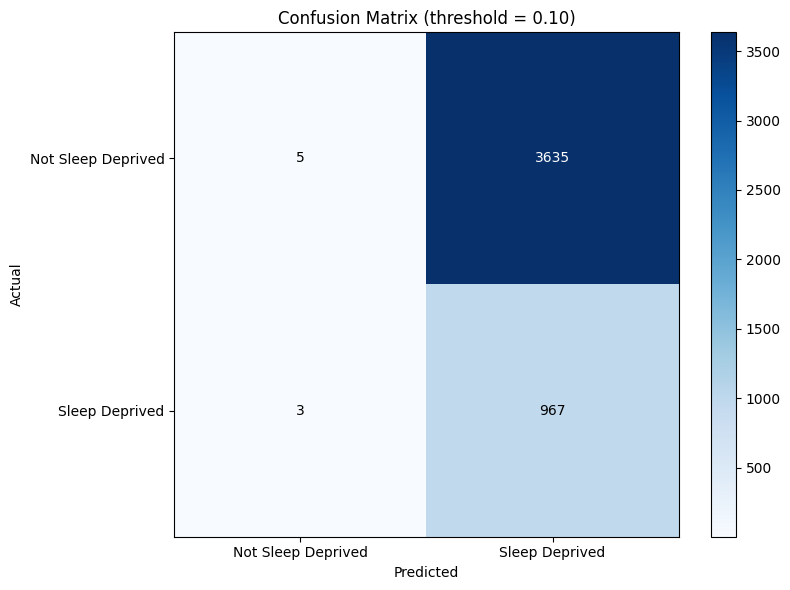

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

# Use the best model from hyperparameter tuning
# This example assumes rf_model is already trained with your best parameters
rf_model = best_model

# Get predicted probabilities instead of class predictions
y_proba = rf_model.predict_proba(X_test)[:, 1]

# Try different thresholds
thresholds = np.arange(0.1, 0.6, 0.05)
results = []

for threshold in thresholds:
    # Apply threshold to probabilities
    y_pred = (y_proba >= threshold).astype(int)
    
    # Get metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']
    accuracy = report['accuracy']
    
    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy
    })

# Create results table
results_df = pd.DataFrame(results)
print("Performance at different thresholds:")
print(results_df)

# Find threshold with best recall while maintaining minimum precision
min_precision = 0.2  # Set minimum acceptable precision
valid_results = results_df[results_df['precision'] >= min_precision]
best_recall_idx = valid_results['recall'].idxmax()
best_threshold = results_df.loc[best_recall_idx, 'threshold']

# Apply best threshold
final_predictions = (y_proba >= best_threshold).astype(int)

# Print final results
print(f"\nBest threshold: {best_threshold:.2f}")
print("\nFinal classification report:")
print(classification_report(y_test, final_predictions))

# Visualize confusion matrix
cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title(f'Confusion Matrix (threshold = {best_threshold:.2f})')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['Not Sleep Deprived', 'Sleep Deprived'])
plt.yticks([0, 1], ['Not Sleep Deprived', 'Sleep Deprived'])

# Add count labels
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), 
                 ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()

In [57]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Identify numerical and categorical features
# First check which columns actually exist
print("Available columns:", df_demo_cat.columns.tolist())

# Potential numerical features (check which ones exist)
numerical_features = []
for col in ['age_years', 'daily_sleep_duration', 'family_income_to_poverty_ratio']:
    if col in df_demo_cat.columns:
        numerical_features.append(col)

# Categorical features
categorical_features = []
for col in ['gender', 'race_hispanic_origin', 'exam_period', 'country_of_birth', 
            'education_level', 'marital_status', 'sleep_risk_category']:
    if col in df_demo_cat.columns:
        categorical_features.append(col)

# Prepare data
X = df_demo_cat.drop(['is_sleep_deprived', 'respondent_id'], axis=1)
if 'race_hispanic_origin_with_asian' in X.columns:
    X = X.drop('race_hispanic_origin_with_asian', axis=1)
    
y = df_demo_cat['is_sleep_deprived']

print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")
print(f"Class distribution: {np.bincount(y)}")

# Split data first to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_SEED)

# Create preprocessing steps
numerical_transformer = Pipeline(steps=[
    # MICE imputation for numerical features
    ('imputer', IterativeImputer(max_iter=10, random_state=RANDOM_SEED))
])

categorical_transformer = Pipeline(steps=[
    # Most frequent imputation for categorical features
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# Create the final pipeline with RandomForest using the best parameters from tuning
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=4,
        max_features='log2',
        class_weight='balanced_subsample',
        random_state=RANDOM_SEED
    ))
])

# Fit the model
print("Training model with MICE imputation...")
rf_pipeline.fit(X_train, y_train)

# Evaluate on test set
print("\n--- Results with MICE imputation ---")
print("Training accuracy:", rf_pipeline.score(X_train, y_train))
print("Test accuracy:", rf_pipeline.score(X_test, y_test))

# Get predictions
y_proba = rf_pipeline.predict_proba(X_test)[:, 1]
y_pred = rf_pipeline.predict(X_test)

print("Classification Report (threshold=0.5):")
print(classification_report(y_test, y_pred))

# Try different thresholds to optimize recall
thresholds = np.arange(0.2, 0.5, 0.05)
results = []

print("\nPerformance at different thresholds:")
for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    report = classification_report(y_test, y_pred_threshold, output_dict=True)
    
    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']
    accuracy = report['accuracy']
    
    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy
    })
    
    print(f"Threshold: {threshold:.2f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | Accuracy: {accuracy:.4f}")

# Find optimal threshold with good balance of precision and recall
f1_scores = [r['f1'] for r in results]
best_idx = np.argmax(f1_scores)
best_threshold = results[best_idx]['threshold']

# Final predictions with best threshold
y_pred_optimal = (y_proba >= best_threshold).astype(int)

print(f"\nBest threshold (by F1): {best_threshold:.2f}")
print("Final classification report:")
print(classification_report(y_test, y_pred_optimal))

# Show feature importances
try:
    if len(numerical_features) > 0:
        feature_names = (
            numerical_features +
            list(rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))
        )
    else:
        feature_names = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
    
    importances = rf_pipeline.named_steps['classifier'].feature_importances_
    
    # Sort and display top features
    indices = np.argsort(importances)[::-1]
    print("\n--- Top 10 Feature Importances ---")
    for i in range(min(10, len(feature_names))):
        print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")
except Exception as e:
    print(f"Couldn't extract feature importances: {e}")

Available columns: ['respondent_id', 'is_sleep_deprived', 'gender', 'race_hispanic_origin', 'race_hispanic_origin_with_asian', 'exam_period', 'country_of_birth', 'education_level', 'marital_status', 'sleep_risk_category']
Numerical features: []
Categorical features: ['gender', 'race_hispanic_origin', 'exam_period', 'country_of_birth', 'education_level', 'marital_status', 'sleep_risk_category']
Class distribution: [14424  4014]
Training model with MICE imputation...

--- Results with MICE imputation ---
Training accuracy: 0.6813711310384727
Test accuracy: 0.6540130151843818
Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.85      0.69      0.76      3640
           1       0.31      0.53      0.39       970

    accuracy                           0.65      4610
   macro avg       0.58      0.61      0.58      4610
weighted avg       0.73      0.65      0.68      4610


Performance at different thresholds:
Threshold: 0.20 

Classification Report (threshold=0.45):
              precision    recall  f1-score   support

           0       0.85      0.58      0.69      3640
           1       0.28      0.63      0.39       970

    accuracy                           0.59      4610
   macro avg       0.57      0.60      0.54      4610
weighted avg       0.73      0.59      0.63      4610

Confusion Matrix:
True Negatives (TN): 2098
False Positives (FP): 1542
False Negatives (FN): 358
True Positives (TP): 612

Derived Metrics:
Accuracy: 0.5879
Precision: 0.2841
Recall (Sensitivity): 0.6309
Specificity: 0.5764
F1 Score: 0.3918


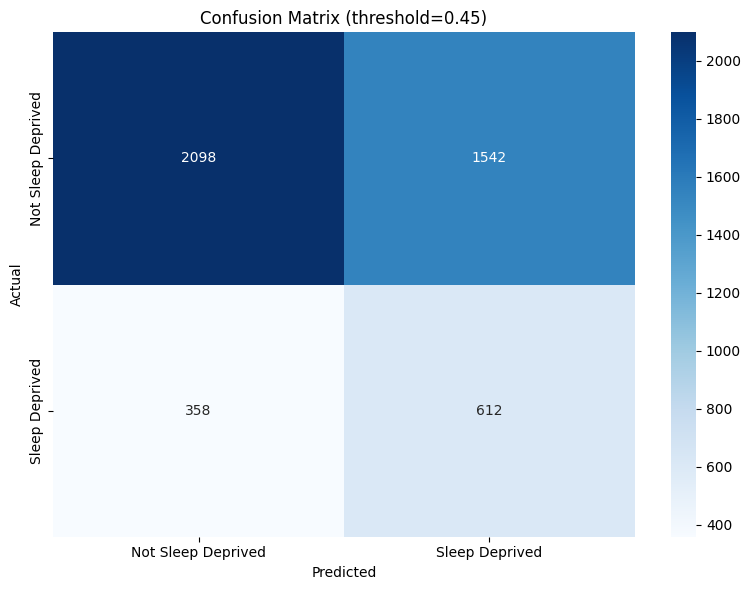


Confusion Matrix (normalized by row):
                  | Predicted Negative | Predicted Positive |
------------------|-------------------|-------------------|
Actually Negative | TN: 2098 (57.6%) | FP: 1542 (42.4%) |
Actually Positive | FN: 358 (36.9%) | TP: 612 (63.1%) |
AUC: 0.6410


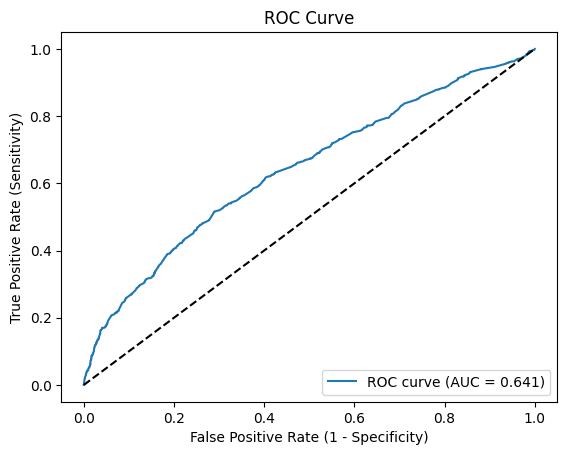

In [58]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make sure we're using the same predictions for both reports
# If you have probability scores, apply your optimal threshold
threshold = 0.45  # Replace with your optimal threshold from previous analysis
y_pred_threshold = (y_proba >= threshold).astype(int)

# First print classification report with these predictions
print("Classification Report (threshold={:.2f}):".format(threshold))
print(classification_report(y_test, y_pred_threshold))

# Calculate confusion matrix using the SAME predictions
cm = confusion_matrix(y_test, y_pred_threshold)

# Extract values
tn, fp, fn, tp = cm.ravel()

# Print the values
print("Confusion Matrix:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# Calculate derived metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("\nDerived Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score: {f1:.4f}")

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Sleep Deprived', 'Sleep Deprived'],
            yticklabels=['Not Sleep Deprived', 'Sleep Deprived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (threshold={threshold:.2f})')
plt.tight_layout()
plt.show()

# Display as a 2x2 table with percentages
print("\nConfusion Matrix (normalized by row):")
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print(f"                  | Predicted Negative | Predicted Positive |")
print(f"------------------|-------------------|-------------------|")
print(f"Actually Negative | TN: {tn} ({cm_normalized[0,0]:.1%}) | FP: {fp} ({cm_normalized[0,1]:.1%}) |")
print(f"Actually Positive | FN: {fn} ({cm_normalized[1,0]:.1%}) | TP: {tp} ({cm_normalized[1,1]:.1%}) |")


from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Calculate AUC (using probabilities, not thresholded predictions)
auc_score = roc_auc_score(y_test, y_proba)
print(f"AUC: {auc_score:.4f}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [59]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Start with original features
X = df_demo_cat.drop(['is_sleep_deprived', 'respondent_id', 'race_hispanic_origin_with_asian'], axis=1)
y = df_demo_cat['is_sleep_deprived']

# Create engineered features
print("Creating engineered features...")

# Interaction terms
X['high_risk_female'] = ((X['sleep_risk_category'] == 'High Risk') & 
                           (X['gender'] == 'Female')).astype(int)

X['high_risk_black'] = ((X['sleep_risk_category'] == 'High Risk') & 
                          (X['race_hispanic_origin'] == 'Non-Hispanic Black')).astype(int)

# Demographic risk score
def calc_demo_risk_score(row):
    score = 0
    if row['race_hispanic_origin'] == 'Non-Hispanic Black':
        score += 3
    elif row['race_hispanic_origin'] == 'Other/Multi-Racial':
        score += 2
    if row['gender'] == 'Female':
        score += 1
    if pd.notna(row['education_level']) and row['education_level'] not in ['College Graduate+', 'Some College/AA']:
        score += 1
    return score

X['demographic_risk_score'] = X.apply(calc_demo_risk_score, axis=1)

# Identify categorical and numerical features
categorical_features = [
    'gender', 'race_hispanic_origin', 'exam_period', 
    'country_of_birth', 'education_level', 'marital_status',
    'sleep_risk_category'
]

numerical_features = [col for col in X.columns if col not in categorical_features]
print(f"Numerical features (engineered): {numerical_features}")

# Create preprocessing pipelines
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())  # Scaling is important for logistic regression
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_SEED)

# Create logistic regression pipeline with class balancing
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        penalty='l2',         
        solver='liblinear',   # Good for smaller datasets
        class_weight='balanced', # Handle class imbalance
        random_state=RANDOM_SEED,
        max_iter=1000         
    ))
])

# Define hyperparameter grid for C (inverse regularization strength)
param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0]
}

# Use GridSearchCV to optimize for AUC
grid_search = GridSearchCV(logreg_pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
print("Performing grid search to optimize AUC...")
grid_search.fit(X_train, y_train)

print(f"Best parameter (C): {grid_search.best_params_}")
print(f"Best cross-validated AUC: {grid_search.best_score_:.4f}")

# Use best estimator
best_model = grid_search.best_estimator_

# Get predictions on test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Evaluate model
print("\n--- Optimized Logistic Regression Results ---")
print("Training accuracy:", best_model.score(X_train, y_train))
print("Test accuracy:", best_model.score(X_test, y_test))

# Calculate AUC
auc_score = roc_auc_score(y_test, y_proba)
print(f"AUC: {auc_score:.4f}")

# Classification report at default threshold
print("\nClassification Report (default threshold):")
print(classification_report(y_test, y_pred))

# Try different thresholds for additional insight
thresholds = np.arange(0.2, 0.6, 0.05)
results = []
print("\nPerformance at different thresholds:")
for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    report = classification_report(y_test, y_pred_threshold, output_dict=True)
    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']
    accuracy = report['accuracy']
    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy
    })
    print(f"Threshold: {threshold:.2f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | Accuracy: {accuracy:.4f}")

# Find optimal threshold based on F1 score
f1_scores = [r['f1'] for r in results]
best_idx = np.argmax(f1_scores)
best_threshold = results[best_idx]['threshold']

# Apply best threshold
y_pred_optimal = (y_proba >= best_threshold).astype(int)

# Note: AUC is computed on probabilities, so thresholding doesn't change it.
auc_score_opt = roc_auc_score(y_test, y_proba)
print(f"\nAUC (unchanged by thresholding): {auc_score_opt:.4f}")

print(f"\nBest threshold based on F1: {best_threshold:.2f}")
print("Final classification report:")
print(classification_report(y_test, y_pred_optimal))

# Calculate and display confusion matrix
cm = confusion_matrix(y_test, y_pred_optimal)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# Derived metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("\nDerived Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1 Score: {f1:.4f}")

# Display normalized confusion matrix
print("\nConfusion Matrix (normalized by row):")
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print("                  | Predicted Negative | Predicted Positive |")
print("------------------|--------------------|--------------------|")
print(f"Actually Negative | TN: {tn} ({cm_normalized[0,0]:.1%}) | FP: {fp} ({cm_normalized[0,1]:.1%}) |")
print(f"Actually Positive | FN: {fn} ({cm_normalized[1,0]:.1%}) | TP: {tp} ({cm_normalized[1,1]:.1%}) |")

# Try to extract coefficients
try:
    # Get feature names from preprocessor
    cat_features = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
    feature_names = np.concatenate([numerical_features, cat_features])
    
    # Get coefficients
    coefficients = best_model.named_steps['classifier'].coef_[0]
    
    # Create DataFrame with coefficients
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients,
        'Abs_Coefficient': np.abs(coefficients)
    })
    
    # Sort by absolute coefficient value
    coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)
    
    # Show odds ratios for top 15 features
    print("\n--- Top 15 Features (by coefficient magnitude) ---")
    print("Feature | Coefficient | Odds Ratio")
    print("--------|-------------|----------")
    for i, row in coef_df.head(15).iterrows():
        odds_ratio = np.exp(row['Coefficient'])
        print(f"{row['Feature']} | {row['Coefficient']:.4f} | {odds_ratio:.4f}")
        
except Exception as e:
    print(f"Couldn't extract coefficients: {e}")

Creating engineered features...
Numerical features (engineered): ['high_risk_female', 'high_risk_black', 'demographic_risk_score']
Performing grid search to optimize AUC...
Best parameter (C): {'classifier__C': 1.0}
Best cross-validated AUC: 0.6395

--- Optimized Logistic Regression Results ---
Training accuracy: 0.6766705235753544
Test accuracy: 0.6767895878524945
AUC: 0.6557

Classification Report (default threshold):
              precision    recall  f1-score   support

           0       0.84      0.73      0.78      3640
           1       0.32      0.48      0.38       970

    accuracy                           0.68      4610
   macro avg       0.58      0.60      0.58      4610
weighted avg       0.73      0.68      0.70      4610


Performance at different thresholds:
Threshold: 0.20 | Precision: 0.2104 | Recall: 1.0000 | F1: 0.3477 | Accuracy: 0.2104
Threshold: 0.25 | Precision: 0.2105 | Recall: 1.0000 | F1: 0.3477 | Accuracy: 0.2106
Threshold: 0.30 | Precision: 0.2105 | Rec

In [60]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Prepare data - first check available columns
X = df_demo_cat.drop(['is_sleep_deprived', 'respondent_id'], axis=1)
if 'race_hispanic_origin_with_asian' in X.columns:
    X = X.drop('race_hispanic_origin_with_asian', axis=1)
    
y = df_demo_cat['is_sleep_deprived']

print(f"Available columns: {X.columns.tolist()}")

# Check for categorical features
categorical_features = []
for col in ['gender', 'race_hispanic_origin', 'exam_period', 'country_of_birth', 
            'education_level', 'marital_status', 'sleep_risk_category']:
    if col in X.columns:
        categorical_features.append(col)

print(f"Categorical features available: {categorical_features}")

# Get numerical features
numerical_features = [col for col in X.columns if col not in categorical_features]
print(f"Numerical features: {numerical_features}")

# Create preprocessing pipelines
if len(numerical_features) > 0:
    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    transformers = [('num', numerical_transformer, numerical_features)]
else:
    transformers = []

if len(categorical_features) > 0:
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    transformers.append(('cat', categorical_transformer, categorical_features))

preprocessor = ColumnTransformer(transformers=transformers)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_SEED)

# Apply preprocessing
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Get feature dimension
n_features = X_train_preprocessed.shape[1]
print(f"Number of features after preprocessing: {n_features}")

# Calculate class weights to handle imbalance
n_neg, n_pos = np.bincount(y_train)
weight_for_0 = (1 / n_neg) * (n_neg + n_pos) / 2
weight_for_1 = (1 / n_pos) * (n_neg + n_pos) / 2
class_weight = {0: weight_for_0, 1: weight_for_1}
print(f"Class weights: {class_weight}")

# Build neural network model
def create_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC()]
    )
    return model

# Create and train model
model = create_model(n_features)
print("Training neural network...")

# Add early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_preprocessed, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight,
    callbacks=[early_stopping],
    verbose=1  # Show progress
)

# Evaluate model
y_proba = model.predict(X_test_preprocessed, verbose=0).flatten()
y_pred = (y_proba >= 0.5).astype(int)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_proba)
print(f"\n--- Neural Network Results ---")
print(f"AUC: {auc_score:.4f}")

# Classification report at default threshold
print("\nClassification Report (default threshold):")
print(classification_report(y_test, y_pred))

# Try different thresholds
thresholds = np.arange(0.2, 0.6, 0.05)
results = []

print("\nPerformance at different thresholds:")
for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    report = classification_report(y_test, y_pred_threshold, output_dict=True)
    
    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']
    accuracy = report['accuracy']
    
    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy
    })
    
    print(f"Threshold: {threshold:.2f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | Accuracy: {accuracy:.4f}")

# Find optimal threshold based on F1 score
f1_scores = [r['f1'] for r in results]
best_idx = np.argmax(f1_scores)
best_threshold = results[best_idx]['threshold']

# Apply best threshold
y_pred_optimal = (y_proba >= best_threshold).astype(int)

print(f"\nBest threshold: {best_threshold:.2f}")
print("Final classification report:")
print(classification_report(y_test, y_pred_optimal))

# Calculate and display confusion matrix
cm = confusion_matrix(y_test, y_pred_optimal)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# Display confusion matrix as a 2x2 table with percentages
print("\nConfusion Matrix (normalized by row):")
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print(f"                  | Predicted Negative | Predicted Positive |")
print(f"------------------|-------------------|-------------------|")
print(f"Actually Negative | TN: {tn} ({cm_normalized[0,0]:.1%}) | FP: {fp} ({cm_normalized[0,1]:.1%}) |")
print(f"Actually Positive | FN: {fn} ({cm_normalized[1,0]:.1%}) | TP: {tp} ({cm_normalized[1,1]:.1%}) |")

Available columns: ['gender', 'race_hispanic_origin', 'exam_period', 'country_of_birth', 'education_level', 'marital_status', 'sleep_risk_category']
Categorical features available: ['gender', 'race_hispanic_origin', 'exam_period', 'country_of_birth', 'education_level', 'marital_status', 'sleep_risk_category']
Numerical features: []
Number of features after preprocessing: 26
Class weights: {0: 0.6411350148367952, 1: 2.271353482260184}
Training neural network...
Epoch 1/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5125 - auc: 0.5330 - loss: 0.6939 - val_accuracy: 0.6981 - val_auc: 0.6243 - val_loss: 0.6531
Epoch 2/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6394 - auc: 0.6117 - loss: 0.6622 - val_accuracy: 0.7166 - val_auc: 0.6247 - val_loss: 0.6331
Epoch 3/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6868 - auc: 0.6345 - loss: 0.6542 - val_accuracy: 0.6978 - val_auc: 0.6300 - val_loss: 0.6384
Epoch 4/50
346/346 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - a

In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import lightgbm as lgb

# Set random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Prepare data
X = df_demo_cat.drop(['is_sleep_deprived', 'respondent_id'], axis=1)
if 'race_hispanic_origin_with_asian' in X.columns:
    X = X.drop('race_hispanic_origin_with_asian', axis=1)
    
y = df_demo_cat['is_sleep_deprived']

print(f"Available columns: {X.columns.tolist()}")

# Identify categorical features
categorical_features = []
for col in ['gender', 'race_hispanic_origin', 'exam_period', 'country_of_birth', 
            'education_level', 'marital_status', 'sleep_risk_category']:
    if col in X.columns:
        categorical_features.append(col)

print(f"Categorical features: {categorical_features}")

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_SEED)

# Preprocess data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Calculate class weights for imbalance
n_neg = sum(y_train == 0)
n_pos = sum(y_train == 1)
scale_pos_weight = n_neg / n_pos

print(f"Class imbalance ratio (neg:pos): {n_neg/n_pos:.2f}")

# Create basic LightGBM classifier with minimal parameters
model = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=100,
    random_state=RANDOM_SEED,
    scale_pos_weight=scale_pos_weight
)

print("Training LightGBM model...")
model.fit(X_train_processed, y_train)

# Get predictions
y_proba = model.predict_proba(X_test_processed)[:, 1]
y_pred = model.predict(X_test_processed)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_proba)
print(f"\n--- LightGBM Results ---")
print(f"AUC: {auc_score:.4f}")

# Classification report at default threshold
print("\nClassification Report (default threshold):")
print(classification_report(y_test, y_pred))

# Try different thresholds
thresholds = np.arange(0.2, 0.6, 0.05)
results = []

print("\nPerformance at different thresholds:")
for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    report = classification_report(y_test, y_pred_threshold, output_dict=True)
    
    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']
    accuracy = report['accuracy']
    
    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy
    })
    
    print(f"Threshold: {threshold:.2f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | Accuracy: {accuracy:.4f}")

# Find optimal threshold based on F1 score
f1_scores = [r['f1'] for r in results]
best_idx = np.argmax(f1_scores)
best_threshold = results[best_idx]['threshold']

# Apply best threshold
y_pred_optimal = (y_proba >= best_threshold).astype(int)

print(f"\nBest threshold: {best_threshold:.2f}")
print("Final classification report:")
print(classification_report(y_test, y_pred_optimal))

# Calculate and display confusion matrix
cm = confusion_matrix(y_test, y_pred_optimal)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# Display confusion matrix as a 2x2 table with percentages
print("\nConfusion Matrix (normalized by row):")
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print(f"                  | Predicted Negative | Predicted Positive |")
print(f"------------------|-------------------|-------------------|")
print(f"Actually Negative | TN: {tn} ({cm_normalized[0,0]:.1%}) | FP: {fp} ({cm_normalized[0,1]:.1%}) |")
print(f"Actually Positive | FN: {fn} ({cm_normalized[1,0]:.1%}) | TP: {tp} ({cm_normalized[1,1]:.1%}) |")

# Try to get feature importance
try:
    # Get feature names
    feature_names = []
    if hasattr(preprocessor, 'get_feature_names_out'):
        feature_names = preprocessor.get_feature_names_out()
    else:
        feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    
    # Get feature importance
    importance = model.feature_importances_
    
    # Sort importance
    indices = np.argsort(importance)[::-1]
    
    # Display top 15 important features
    print("\n--- Top 15 Important Features ---")
    for i in range(min(15, len(feature_names))):
        print(f"{i+1}. {feature_names[indices[i]]}: {importance[indices[i]]}")
except Exception as e:
    print(f"Couldn't extract feature importance: {e}")

Available columns: ['gender', 'race_hispanic_origin', 'exam_period', 'country_of_birth', 'education_level', 'marital_status', 'sleep_risk_category']
Categorical features: ['gender', 'race_hispanic_origin', 'exam_period', 'country_of_birth', 'education_level', 'marital_status', 'sleep_risk_category']
Class imbalance ratio (neg:pos): 3.54
Training LightGBM model...
[LightGBM] [Info] Number of positive: 3044, number of negative: 10784
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000492 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 48
[LightGBM] [Info] Number of data points in the train set: 13828, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.220133 -> initscore=-1.264891
[LightGBM] [Info] Start training from score -1.264891

--- LightGBM Results ---
AUC: 0.6561

Classification Report (default threshold

In [62]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Set random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Prepare data
X = df_demo_cat.drop(['is_sleep_deprived', 'respondent_id'], axis=1)
if 'race_hispanic_origin_with_asian' in X.columns:
    X = X.drop('race_hispanic_origin_with_asian', axis=1)
    
y = df_demo_cat['is_sleep_deprived']

print(f"Available columns: {X.columns.tolist()}")

# Identify categorical features
categorical_features = []
for col in ['gender', 'race_hispanic_origin', 'exam_period', 'country_of_birth', 
            'education_level', 'marital_status', 'sleep_risk_category']:
    if col in X.columns:
        categorical_features.append(col)

print(f"Categorical features: {categorical_features}")

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Define base models with the best parameters from our previous attempts
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=4,
    max_features='log2',
    class_weight='balanced_subsample',
    random_state=RANDOM_SEED
)

xgb_model = xgb.XGBClassifier(
    learning_rate=0.01,
    max_depth=7,
    n_estimators=300,
    subsample=1.0,
    gamma=0.4,
    min_child_weight=1,
    scale_pos_weight=3,
    random_state=RANDOM_SEED
)

nn_model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=32,
    learning_rate='adaptive',
    max_iter=200,
    early_stopping=True,
    random_state=RANDOM_SEED
)

# Define meta-learner
meta_learner = LogisticRegression(class_weight='balanced', random_state=RANDOM_SEED)

# Create stacked model
stacked_model = StackingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('nn', nn_model)
    ],
    final_estimator=meta_learner,
    cv=5,  # 5-fold cross-validation
    stack_method='predict_proba',
    n_jobs=-1,
    verbose=0
)

# Create full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', stacked_model)
])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_SEED)

# Train model
print("Training stacked model (this may take a while)...")
pipeline.fit(X_train, y_train)

# Get predictions
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Calculate AUC
auc_score = roc_auc_score(y_test, y_proba)
print(f"\n--- Stacked Model Results ---")
print(f"AUC: {auc_score:.4f}")

# Classification report at default threshold
print("\nClassification Report (default threshold):")
print(classification_report(y_test, y_pred))

# Try different thresholds
thresholds = np.arange(0.2, 0.6, 0.05)
results = []

print("\nPerformance at different thresholds:")
for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    report = classification_report(y_test, y_pred_threshold, output_dict=True)
    
    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']
    accuracy = report['accuracy']
    
    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy
    })
    
    print(f"Threshold: {threshold:.2f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | Accuracy: {accuracy:.4f}")

# Find optimal threshold based on F1 score
f1_scores = [r['f1'] for r in results]
best_idx = np.argmax(f1_scores)
best_threshold = results[best_idx]['threshold']

# Apply best threshold
y_pred_optimal = (y_proba >= best_threshold).astype(int)

print(f"\nBest threshold: {best_threshold:.2f}")
print("Final classification report:")
print(classification_report(y_test, y_pred_optimal))

# Calculate and display confusion matrix
cm = confusion_matrix(y_test, y_pred_optimal)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# Display confusion matrix as a 2x2 table with percentages
print("\nConfusion Matrix (normalized by row):")
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print(f"                  | Predicted Negative | Predicted Positive |")
print(f"------------------|-------------------|-------------------|")
print(f"Actually Negative | TN: {tn} ({cm_normalized[0,0]:.1%}) | FP: {fp} ({cm_normalized[0,1]:.1%}) |")
print(f"Actually Positive | FN: {fn} ({cm_normalized[1,0]:.1%}) | TP: {tp} ({cm_normalized[1,1]:.1%}) |")

Available columns: ['gender', 'race_hispanic_origin', 'exam_period', 'country_of_birth', 'education_level', 'marital_status', 'sleep_risk_category']
Categorical features: ['gender', 'race_hispanic_origin', 'exam_period', 'country_of_birth', 'education_level', 'marital_status', 'sleep_risk_category']
Training stacked model (this may take a while)...

--- Stacked Model Results ---
AUC: 0.6722

Classification Report (default threshold):
              precision    recall  f1-score   support

           0       0.85      0.67      0.75      3640
           1       0.31      0.56      0.40       970

    accuracy                           0.65      4610
   macro avg       0.58      0.62      0.57      4610
weighted avg       0.74      0.65      0.68      4610


Performance at different thresholds:
Threshold: 0.20 | Precision: 0.2104 | Recall: 1.0000 | F1: 0.3477 | Accuracy: 0.2104
Threshold: 0.25 | Precision: 0.2113 | Recall: 0.9990 | F1: 0.3488 | Accuracy: 0.2152
Threshold: 0.30 | Precision

Original columns: ['gender', 'race_hispanic_origin', 'exam_period', 'country_of_birth', 'education_level', 'marital_status', 'sleep_risk_category']
Simplified columns: ['is_black', 'is_white', 'is_mexican', 'is_high_risk', 'is_low_risk', 'is_college_graduate', 'is_some_college', 'is_high_school', 'is_less_than_high_school', 'is_education_missing', 'is_female', 'is_married', 'is_divorced_widowed', 'is_never_married', 'is_marital_missing', 'is_mid_year_exam', 'is_us_born', 'is_black_high_risk', 'is_female_high_risk']
Starting grid search optimization...
Fitting 5 folds for each of 980 candidates, totalling 4900 fits

Best Parameters:
class_weight: balanced
criterion: gini
max_depth: 6
min_samples_leaf: 20
min_samples_split: 500

Best AUC Score (CV): 0.6020

--- Optimized Decision Tree Results ---
Test AUC: 0.6606

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.79      0.81      3640
           1       0.35      0.42      0.38 

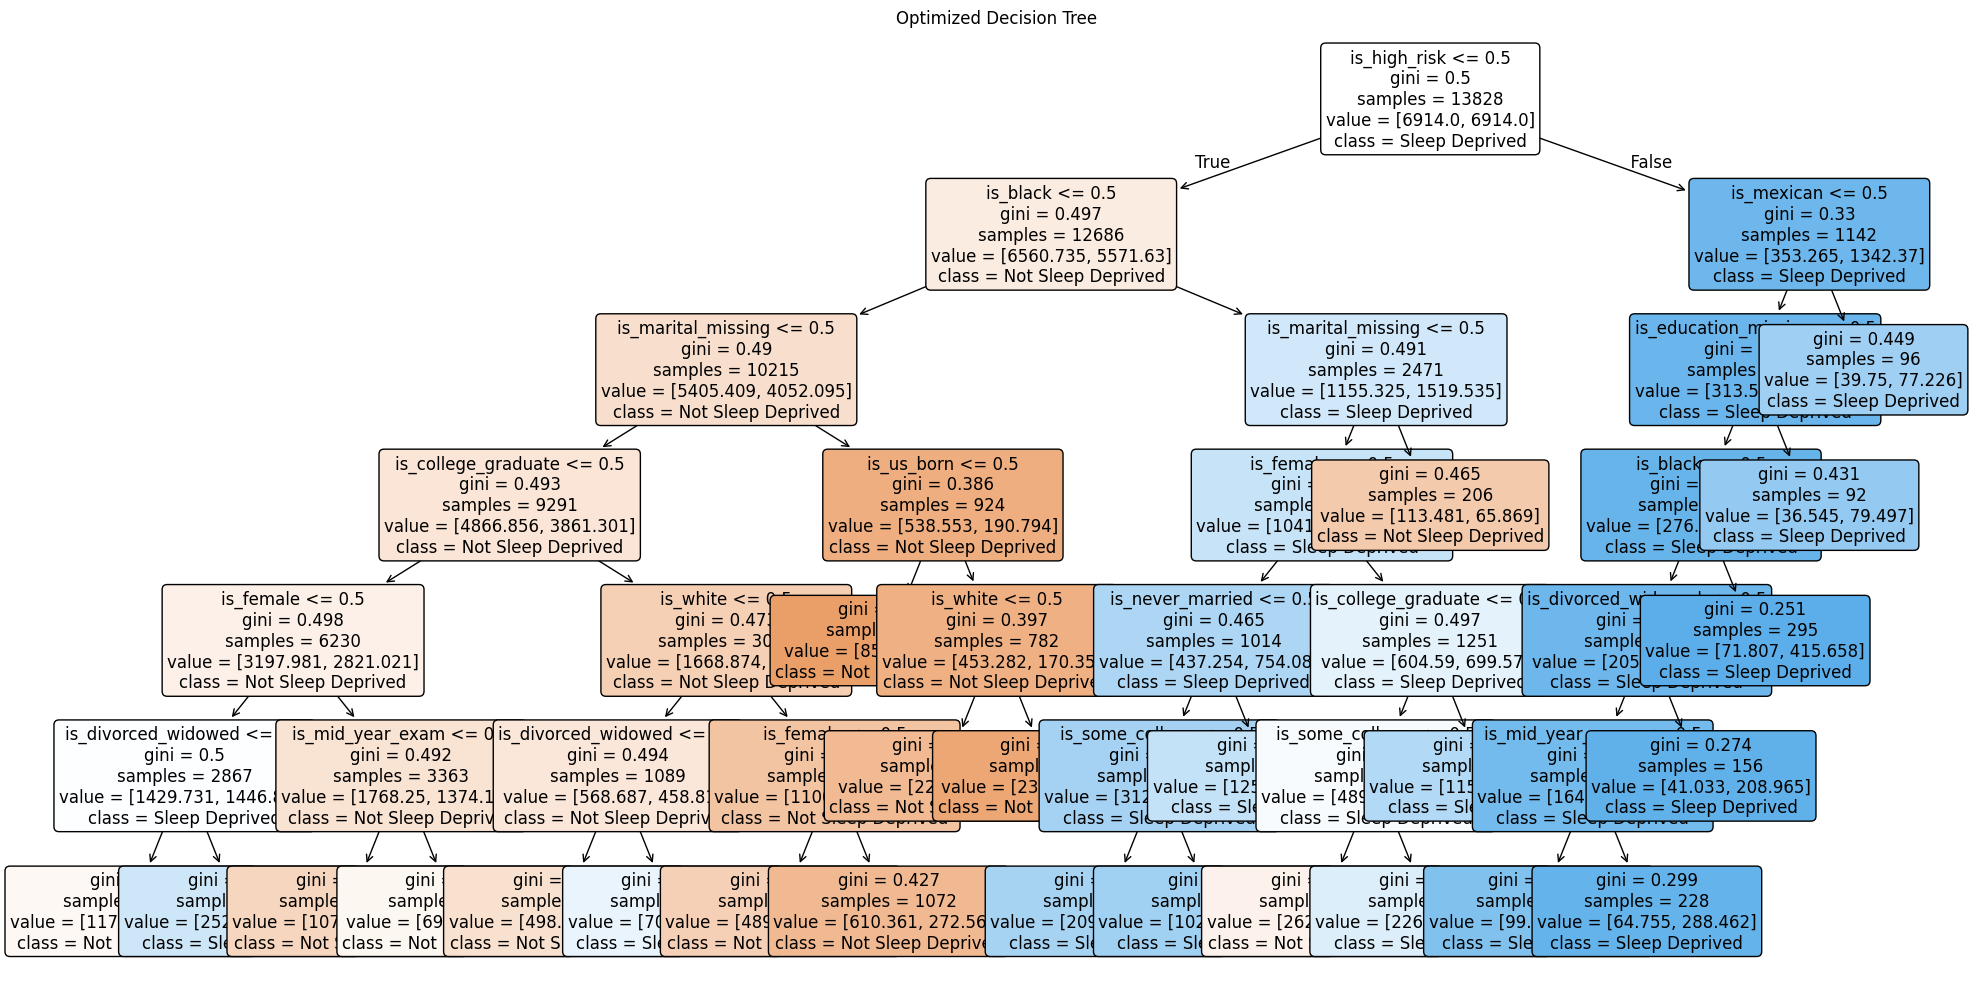


Optimized Decision Tree Text Representation:
|--- is_high_risk <= 0.50
|   |--- is_black <= 0.50
|   |   |--- is_marital_missing <= 0.50
|   |   |   |--- is_college_graduate <= 0.50
|   |   |   |   |--- is_female <= 0.50
|   |   |   |   |   |--- is_divorced_widowed <= 0.50
|   |   |   |   |   |   |--- weights: [1177.12, 1108.42] class: 0
|   |   |   |   |   |--- is_divorced_widowed >  0.50
|   |   |   |   |   |   |--- weights: [252.61, 338.43] class: 1
|   |   |   |   |--- is_female >  0.50
|   |   |   |   |   |--- is_mid_year_exam <= 0.50
|   |   |   |   |   |   |--- weights: [1073.26, 724.56] class: 0
|   |   |   |   |   |--- is_mid_year_exam >  0.50
|   |   |   |   |   |   |--- weights: [694.99, 649.61] class: 0
|   |   |   |--- is_college_graduate >  0.50
|   |   |   |   |--- is_white <= 0.50
|   |   |   |   |   |--- is_divorced_widowed <= 0.50
|   |   |   |   |   |   |--- weights: [498.16, 379.32] class: 0
|   |   |   |   |   |--- is_divorced_widowed >  0.50
|   |   |   |   |   |

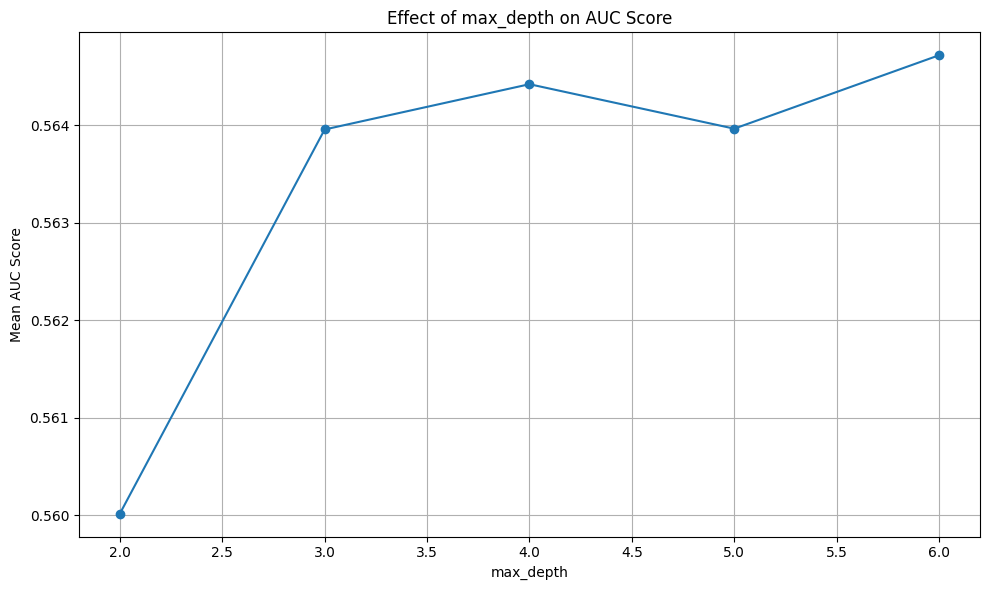

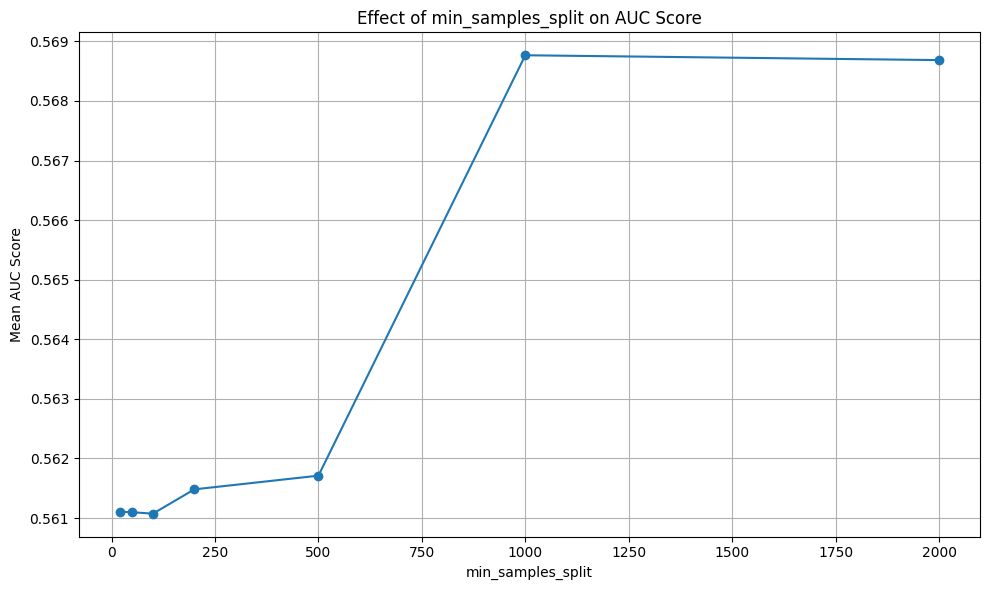

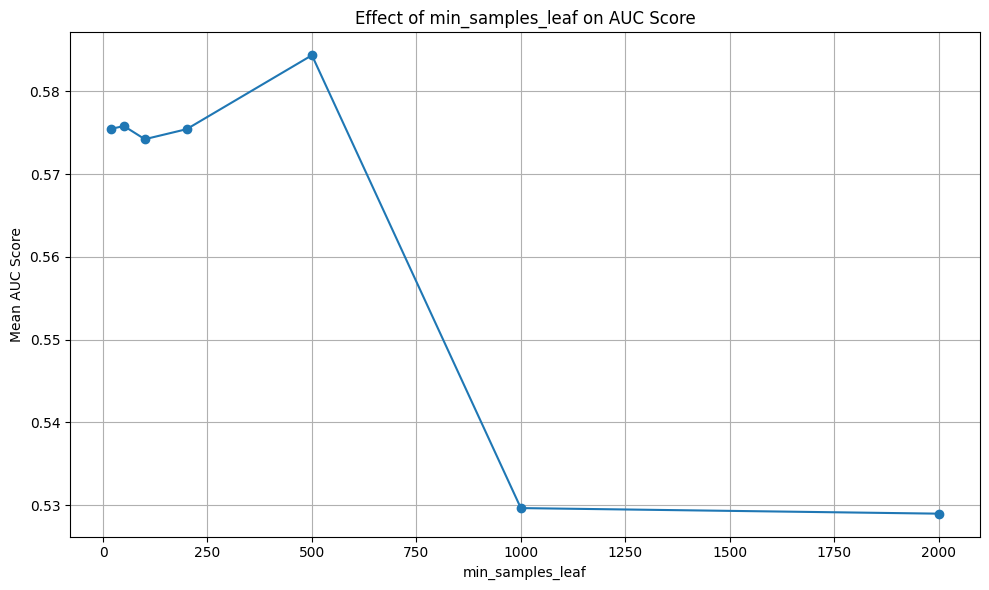

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, make_scorer, f1_score

# Set random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Prepare data from your dataset (ensure df_demo_cat is already loaded)
X = df_demo_cat.drop(['is_sleep_deprived', 'respondent_id'], axis=1)
if 'race_hispanic_origin_with_asian' in X.columns:
    X = X.drop('race_hispanic_origin_with_asian', axis=1)

y = df_demo_cat['is_sleep_deprived']

# Create binary features for better interpretability
X_simple = pd.DataFrame()

# Race - simplified to binary indicators
X_simple['is_black'] = (X['race_hispanic_origin'] == 'Non-Hispanic Black').astype(int)
X_simple['is_white'] = (X['race_hispanic_origin'] == 'Non-Hispanic White').astype(int)
X_simple['is_mexican'] = (X['race_hispanic_origin'] == 'Mexican American').astype(int)

# Sleep risk category - simplified
X_simple['is_high_risk'] = (X['sleep_risk_category'] == 'High Risk').astype(int)
X_simple['is_low_risk'] = (X['sleep_risk_category'] == 'Low Risk').astype(int)

# Education level - simplified
X_simple['is_college_graduate'] = (X['education_level'] == 'College Graduate+').astype(int)
X_simple['is_some_college'] = (X['education_level'] == 'Some College/AA').astype(int)
X_simple['is_high_school'] = (X['education_level'] == 'High School/GED').astype(int)
X_simple['is_less_than_high_school'] = X['education_level'].isin(['9-11th Grade', 'Less than 9th']).astype(int)
X_simple['is_education_missing'] = X['education_level'].isna().astype(int)

# Gender - simplified
X_simple['is_female'] = (X['gender'] == 'Female').astype(int)

# Marital status - simplified
X_simple['is_married'] = (X['marital_status'] == 'Married/Partner').astype(int)
X_simple['is_divorced_widowed'] = (X['marital_status'] == 'Widowed/Divorced/Separated').astype(int)
X_simple['is_never_married'] = (X['marital_status'] == 'Never Married').astype(int)
X_simple['is_marital_missing'] = X['marital_status'].isna().astype(int)

# Exam period
X_simple['is_mid_year_exam'] = (X['exam_period'] == 'May-Oct').astype(int)

# Country of birth
X_simple['is_us_born'] = (X['country_of_birth'] == 'US Born').astype(int)

# Create interaction features
X_simple['is_black_high_risk'] = X_simple['is_black'] * X_simple['is_high_risk']
X_simple['is_female_high_risk'] = X_simple['is_female'] * X_simple['is_high_risk']

print(f"Original columns: {X.columns.tolist()}")
print(f"Simplified columns: {X_simple.columns.tolist()}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.25, random_state=RANDOM_SEED)

# Define parameter grid for optimization
param_grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [20, 50, 100, 200, 500, 1000, 2000],
    'min_samples_leaf': [20, 50, 100, 200, 500, 1000, 2000],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]
}

# Create scorers for grid search
f1_macro_scorer = make_scorer(f1_score, average='macro')
auc_scorer = make_scorer(roc_auc_score)

# Initialize base decision tree classifier
dtree_base = DecisionTreeClassifier(random_state=RANDOM_SEED)

# Setup GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=dtree_base,
    param_grid=param_grid,
    scoring={'f1_macro': f1_macro_scorer, 'auc': auc_scorer},
    refit='auc',  # Optimize for AUC
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Run grid search optimization
print("Starting grid search optimization...")
grid_search.fit(X_train, y_train)

# Display best parameters and best AUC score
print("\nBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")
print(f"\nBest AUC Score (CV): {grid_search.best_score_:.4f}")

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_proba)
print(f"\n--- Optimized Decision Tree Results ---")
print(f"Test AUC: {test_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
print("\n--- Feature Importance ---")
importance = best_model.feature_importances_
feature_names = X_simple.columns
indices = np.argsort(importance)[::-1]

print("Features ranked by importance:")
for i in range(len(feature_names)):
    if importance[indices[i]] > 0.01:  # Display features with >1% importance
        print(f"{i+1}. {feature_names[indices[i]]}: {importance[indices[i]]:.4f}")

# Visualize the optimized decision tree
plt.figure(figsize=(20, 10))
plot_tree(best_model,
          feature_names=list(feature_names),
          class_names=['Not Sleep Deprived', 'Sleep Deprived'],
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Optimized Decision Tree")
plt.tight_layout()
plt.show()

# Export tree as text for easier interpretation
tree_text = export_text(best_model,
                        feature_names=list(feature_names),
                        show_weights=True)
print("\nOptimized Decision Tree Text Representation:")
print(tree_text)

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

print("\nConfusion Matrix (normalized by row):")
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print("                  | Predicted Negative | Predicted Positive |")
print(f"Actually Negative | TN: {tn} ({cm_normalized[0,0]:.1%}) | FP: {fp} ({cm_normalized[0,1]:.1%}) |")
print(f"Actually Positive | FN: {fn} ({cm_normalized[1,0]:.1%}) | TP: {tp} ({cm_normalized[1,1]:.1%}) |")

# Optional: Function to visualize grid search results for a parameter
def plot_grid_search_results(grid_search, param_name):
    results = pd.DataFrame(grid_search.cv_results_)
    # Group by the parameter of interest, ensuring numeric aggregation only
    grouped = results.groupby(f'param_{param_name}').mean(numeric_only=True)
    
    plt.figure(figsize=(10, 6))
    plt.plot(grouped.index, grouped['mean_test_auc'], marker='o', linestyle='-')
    plt.title(f'Effect of {param_name} on AUC Score')
    plt.xlabel(param_name)
    plt.ylabel('Mean AUC Score')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot effect of key parameters
plot_grid_search_results(grid_search, 'max_depth')
plot_grid_search_results(grid_search, 'min_samples_split')
plot_grid_search_results(grid_search, 'min_samples_leaf')


Original columns: ['gender', 'race_hispanic_origin', 'exam_period', 'country_of_birth', 'education_level', 'marital_status', 'sleep_risk_category']
Simplified columns: ['is_black', 'is_white', 'is_mexican', 'is_high_risk', 'is_low_risk', 'is_college_graduate', 'is_some_college', 'is_high_school', 'is_less_than_high_school', 'is_education_missing', 'is_female', 'is_married', 'is_divorced_widowed', 'is_never_married', 'is_marital_missing', 'is_mid_year_exam', 'is_us_born', 'is_black_high_risk', 'is_female_high_risk']
Training simplified decision tree model...

--- Simplified Decision Tree Results ---
AUC: 0.6583

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.74      0.79      3640
           1       0.33      0.47      0.39       970

    accuracy                           0.69      4610
   macro avg       0.58      0.61      0.59      4610
weighted avg       0.73      0.69      0.70      4610


--- Feature Importance ---
Fea

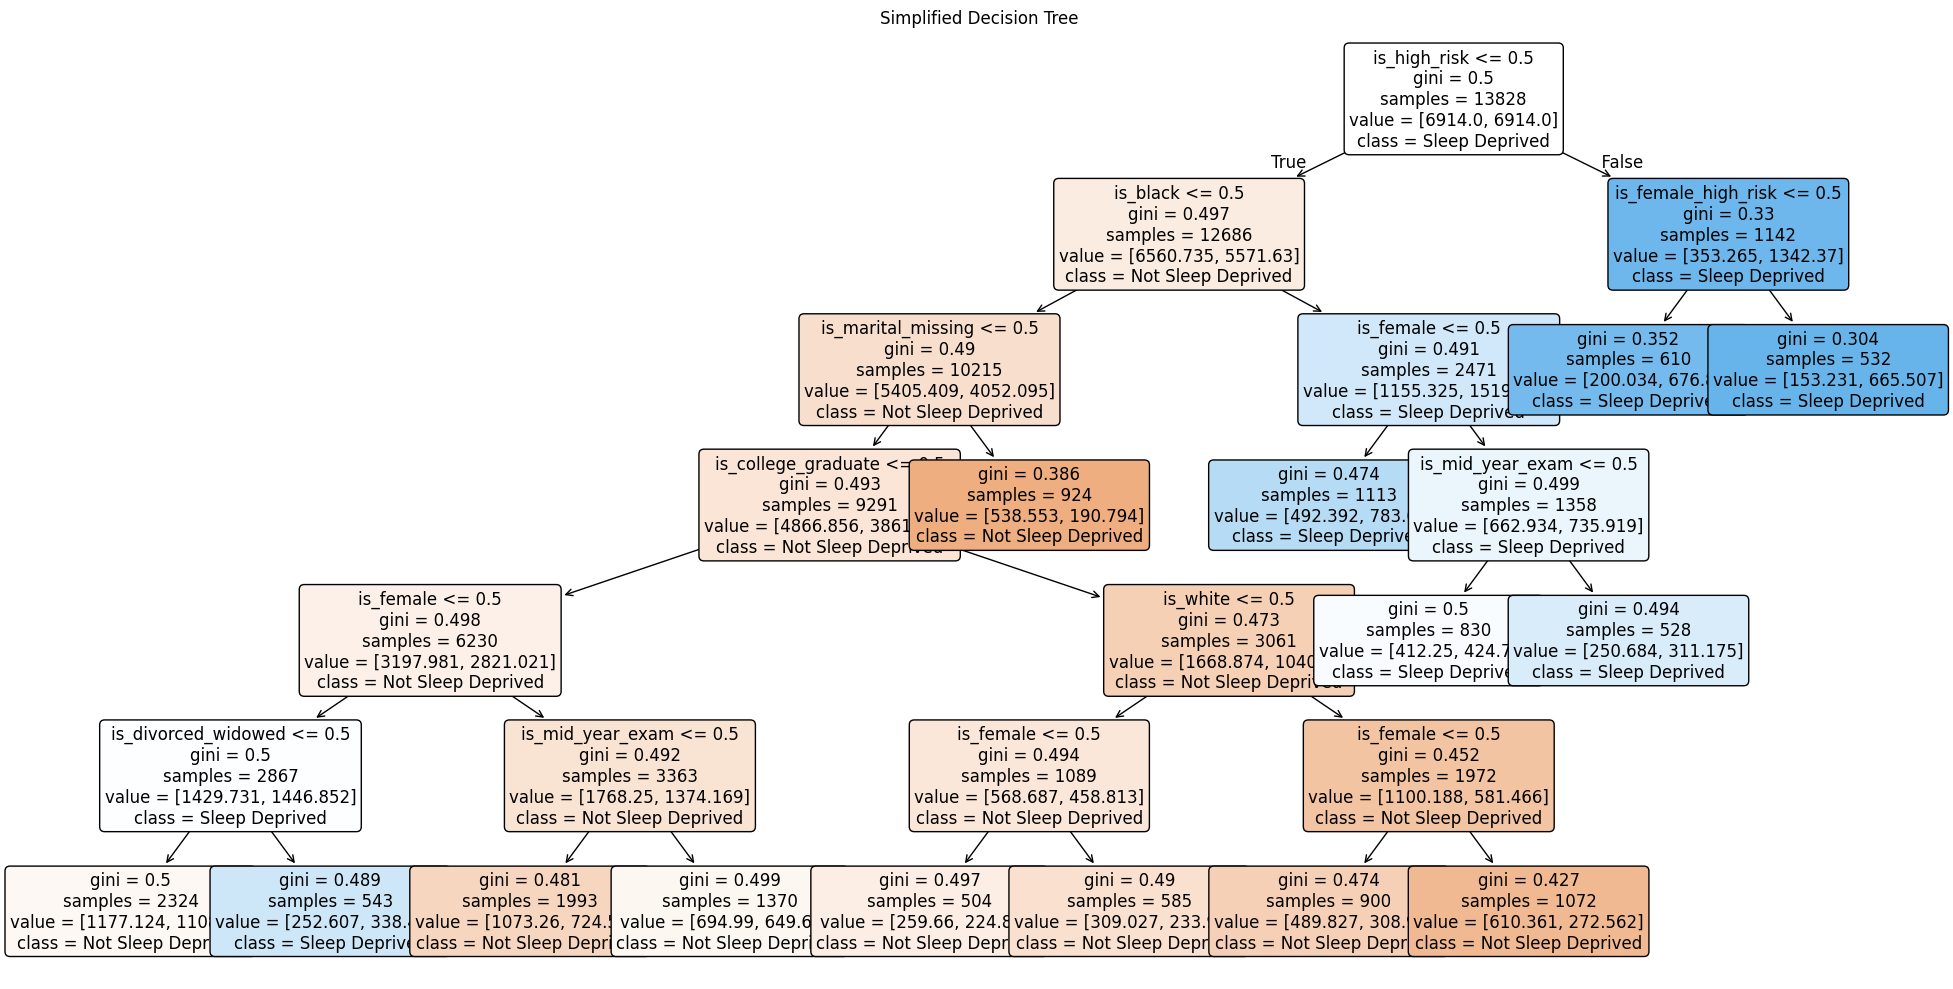


Simplified Decision Tree Text Representation:
|--- is_high_risk <= 0.50
|   |--- is_black <= 0.50
|   |   |--- is_marital_missing <= 0.50
|   |   |   |--- is_college_graduate <= 0.50
|   |   |   |   |--- is_female <= 0.50
|   |   |   |   |   |--- is_divorced_widowed <= 0.50
|   |   |   |   |   |   |--- weights: [1177.12, 1108.42] class: 0
|   |   |   |   |   |--- is_divorced_widowed >  0.50
|   |   |   |   |   |   |--- weights: [252.61, 338.43] class: 1
|   |   |   |   |--- is_female >  0.50
|   |   |   |   |   |--- is_mid_year_exam <= 0.50
|   |   |   |   |   |   |--- weights: [1073.26, 724.56] class: 0
|   |   |   |   |   |--- is_mid_year_exam >  0.50
|   |   |   |   |   |   |--- weights: [694.99, 649.61] class: 0
|   |   |   |--- is_college_graduate >  0.50
|   |   |   |   |--- is_white <= 0.50
|   |   |   |   |   |--- is_female <= 0.50
|   |   |   |   |   |   |--- weights: [259.66, 224.86] class: 0
|   |   |   |   |   |--- is_female >  0.50
|   |   |   |   |   |   |--- weights: [3

In [64]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt

# Set random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Prepare data
X = df_demo_cat.drop(['is_sleep_deprived', 'respondent_id'], axis=1)
if 'race_hispanic_origin_with_asian' in X.columns:
    X = X.drop('race_hispanic_origin_with_asian', axis=1)
    
y = df_demo_cat['is_sleep_deprived']

# Create binary features for better interpretability
X_simple = pd.DataFrame()

# Race - simplified to binary indicators
X_simple['is_black'] = (X['race_hispanic_origin'] == 'Non-Hispanic Black').astype(int)
X_simple['is_white'] = (X['race_hispanic_origin'] == 'Non-Hispanic White').astype(int)
X_simple['is_mexican'] = (X['race_hispanic_origin'] == 'Mexican American').astype(int)

# Sleep risk category - simplified
X_simple['is_high_risk'] = (X['sleep_risk_category'] == 'High Risk').astype(int) 
X_simple['is_low_risk'] = (X['sleep_risk_category'] == 'Low Risk').astype(int)

# Education level - simplified
X_simple['is_college_graduate'] = (X['education_level'] == 'College Graduate+').astype(int)
X_simple['is_some_college'] = (X['education_level'] == 'Some College/AA').astype(int)
X_simple['is_high_school'] = (X['education_level'] == 'High School/GED').astype(int)
X_simple['is_less_than_high_school'] = X['education_level'].isin(['9-11th Grade', 'Less than 9th']).astype(int)
X_simple['is_education_missing'] = X['education_level'].isna().astype(int)

# Gender - simplified
X_simple['is_female'] = (X['gender'] == 'Female').astype(int)

# Marital status - simplified
X_simple['is_married'] = (X['marital_status'] == 'Married/Partner').astype(int)
X_simple['is_divorced_widowed'] = (X['marital_status'] == 'Widowed/Divorced/Separated').astype(int)
X_simple['is_never_married'] = (X['marital_status'] == 'Never Married').astype(int)
X_simple['is_marital_missing'] = X['marital_status'].isna().astype(int)

# Exam period
X_simple['is_mid_year_exam'] = (X['exam_period'] == 'May-Oct').astype(int)

# Country of birth
X_simple['is_us_born'] = (X['country_of_birth'] == 'US Born').astype(int)

# Create interaction features
X_simple['is_black_high_risk'] = X_simple['is_black'] * X_simple['is_high_risk']
X_simple['is_female_high_risk'] = X_simple['is_female'] * X_simple['is_high_risk']

print(f"Original columns: {X.columns.tolist()}")
print(f"Simplified columns: {X_simple.columns.tolist()}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.25, random_state=RANDOM_SEED)

# Create a decision tree with simpler rules
dtree = DecisionTreeClassifier(
    max_depth=6,              # Set to 3 for a balance of complexity and interpretability
    min_samples_split=20,    
    min_samples_leaf=500,     
    class_weight='balanced', 
    random_state=RANDOM_SEED
)

# Train model
print("Training simplified decision tree model...")
dtree.fit(X_train, y_train)

# Get predictions
y_pred = dtree.predict(X_test)
y_proba = dtree.predict_proba(X_test)[:, 1]

# Calculate AUC
auc_score = roc_auc_score(y_test, y_proba)
print(f"\n--- Simplified Decision Tree Results ---")
print(f"AUC: {auc_score:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
print("\n--- Feature Importance ---")
importance = dtree.feature_importances_
feature_names = X_simple.columns
indices = np.argsort(importance)[::-1]

# Display important features
print("Features ranked by importance:")
for i in range(len(feature_names)):
    if importance[indices[i]] > 0.01:  # Only show features with >1% importance
        print(f"{i+1}. {feature_names[indices[i]]}: {importance[indices[i]]:.4f}")

# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(dtree, 
          feature_names=list(feature_names), 
          class_names=['Not Sleep Deprived', 'Sleep Deprived'],
          filled=True,
          rounded=True,
          fontsize=12)
plt.title("Simplified Decision Tree")
plt.tight_layout()
plt.show()

# Export tree as text for easier interpretation
tree_text = export_text(dtree, 
                       feature_names=list(feature_names),
                       show_weights=True)
print("\nSimplified Decision Tree Text Representation:")
print(tree_text)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

print("\nConfusion Matrix (normalized by row):")
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
print(f"                  | Predicted Negative | Predicted Positive |")
print(f"------------------|-------------------|-------------------|")
print(f"Actually Negative | TN: {tn} ({cm_normalized[0,0]:.1%}) | FP: {fp} ({cm_normalized[0,1]:.1%}) |")
print(f"Actually Positive | FN: {fn} ({cm_normalized[1,0]:.1%}) | TP: {tp} ({cm_normalized[1,1]:.1%}) |")